In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import json
import os

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
hamann_coords_path = "data/core-ERQ-stats-coords.csv"
search_log_path = "data/local/hamann-objects-sdss-search-log.json"
hamann_sdss_spectra_path = "data/local/hamann_sdss_spectra.json"


client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


### search for objects in sdss

In [2]:
hamann_coords = pd.read_csv(hamann_coords_path, index_col=0)

hamann_coords

,SDSS_id,RA,DEC,ze,i,i-W3,REW,REW_unc,FWHM,FWHM_unc,kt80,NV/CIV,BAL,UV_slope,E(B-V),E(B-V)_unc,FIRST
0,J000610.67+121501.2,1.544491,12.250354,2.31,22.1,8.0,107.0,6.0,4540.0,200.0,0.37,1.88,0,-0.20,0.66,0.01,0.0
1,J000746.19+122223.9,1.942491,12.373315,2.43,21.3,4.9,220.0,6.0,2433.0,71.0,0.28,0.39,0,-0.17,0.19,0.01,0.0
2,J002400.25+245031.9,6.001042,24.842208,2.81,21.6,6.0,144.0,10.0,3523.0,195.0,0.37,2.46,0,-1.14,0.20,0.02,NaN
3,J004713.21+264024.7,11.805059,26.673525,2.56,20.4,4.7,101.0,2.0,3685.0,74.0,0.33,1.92,1,-1.08,0.15,0.01,NaN
4,J005044.95-021217.6,12.687326,-2.204915,2.25,21.5,4.7,147.0,9.0,4343.0,487.0,0.19,0.61,0,-1.73,0.14,0.02,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,J223754.52+065026.6,339.477177,6.840747,2.61,22.0,5.8,141.0,5.0,1391.0,44.0,0.36,1.03,0,-1.20,0.24,0.02,0.0
93,J225438.30+232714.5,343.659621,23.454052,3.09,22.0,5.5,415.0,20.0,4412.0,146.0,0.36,0.66,0,-0.38,NaN,NaN,NaN
94,J232326.17-010033.1,350.859062,-1.009201,2.36,22.4,7.2,256.0,5.0,3989.0,62.0,0.37,2.16,0,0.91,0.40,0.01,0.0
95,J232828.47+044346.8,352.118656,4.729677,2.56,21.5,5.5,359.0,5.0,1584.0,20.0,0.35,0.37,0,-0.28,0.13,0.02,0.0


In [3]:
def log_result_to_json(sdss_id,best_match_id,results_df, filepath=search_log_path):
    '''Adds best match log entry to specified JSON file.'''

    # create entry
    entry = {
        "timestamp":     datetime.utcnow().isoformat(),
        "SDSS_id":       sdss_id,
        "best_match_id": best_match_id,
        "results_df":    results_df.to_dict(orient="records")
    }

    # open file
    with open(filepath, "r") as f:
        log = json.load(f)

    log.append(entry)  # append entry

    # save to file
    with open(filepath, "w") as f:
        json.dump(log, f, indent=2, default=str)
    
    print(f"Logged entry for {sdss_id}")

In [4]:
def query_sdss_by_coords(df, z_deviation=0.5, coord_deviaion=0.1):
    '''
    Iterates through dataframe, for each element searches in DESI for the object with smallest difference in RA, DEC, and z (in that order of importance).
    '''

    for elem_idx in range(len(df)):
        # extract ra, dec, z and id for current element
        elem_ra = df["RA"][elem_idx]
        elem_dec = df["DEC"][elem_idx]
        elem_z = df["ze"][elem_idx]
        elem_sdss_id = df["SDSS_id"][elem_idx]

        # query for objects within set devations of current element 
        constraints = {
            "data_release":["BOSS-DR17"],
            "ra":[elem_ra-coord_deviaion,elem_ra+coord_deviaion],
            "dec":[elem_dec-coord_deviaion,elem_dec+coord_deviaion],
            "redshift":[elem_z-z_deviation,elem_z+z_deviation]
            }

        results = client.find(outfields=["specid","ra","dec","redshift"], constraints=constraints)

        results = pd.DataFrame(results.data[1:])

        # if there are results, calculate differences, then sort to get best match
        if len(results) > 0:
            results["z_diff"] = abs(results["redshift"] - elem_z)
            results["ra_diff"] = abs(results["ra"] - elem_ra)
            results["dec_diff"] = abs(results["dec"] - elem_dec)
            results["coord_diff"] = (results["ra"] - elem_ra)**2 + (results["dec"] - elem_dec)**2
            results = results.sort_values(["coord_diff","z_diff"], ascending=[True,True])
            best_match = results.iloc[0,1]

        # if not found, say so
        else:
            best_match = "Not found"            


        # log to json file
        log_result_to_json(elem_sdss_id,best_match,results)

In [5]:
# query_sdss_by_coords(hamann_coords)

In [6]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]
match_df["best_match_id"] = match_df["best_match_id"].astype("string")

match_df = match_df.rename(columns={"best_match_id":"specid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")
# hamann_erq = match_df.merge(hamann_data,on="sdss_name",how="right")
hamann_erq

,sdss_name,Plate,MJD,FiberID,ThingID,z_dr12,i,i_err,W3,W3_snr,...,kt75,kt80,rew_di,rewe_di,fwhm_di,qflag,rew_nv,frat_nv_civ,nvflag,specid
0,000610.67+121501.2,5649,55912,288,220079389,2.309943,22.101451,0.160805,14.087,35.1,...,0.455485,0.372288,102.007661,6.075000,4508.508813,0,192.343862,1.880187,0,6360287837779417088
1,000746.19+122223.9,6176,56264,194,221814072,2.429000,21.314343,0.079014,16.369,7.0,...,0.383122,0.284162,213.628344,4.754235,2550.825969,0,64.601598,0.388502,0,6360267496814303232
2,002400.25+245031.9,6279,56243,28,328146826,2.809255,21.556824,0.090767,15.522,14.6,...,0.455389,0.372201,134.821509,10.120908,3694.810492,0,205.776721,2.455813,0,7069533316387723264
3,004713.21+264024.7,6286,56301,800,342571394,2.563943,20.435463,0.038392,15.714,13.2,...,0.413071,0.325082,100.642397,5.476974,3662.920844,0,141.614347,1.923201,0,7077626822452860928
4,005044.95-021217.6,4370,55534,980,60738765,2.254000,21.473060,0.078552,16.760,4.6,...,0.262998,0.193256,148.782256,6.993491,5445.426756,0,46.553849,0.609687,0,4920452066097518592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,5058,56208,124,172688138,2.608809,21.960453,0.106963,16.169,3.9,...,0.440905,0.356129,136.337135,3.430820,1318.560329,0,109.072962,1.034336,0,5694835917824743424
93,225438.30+232714.5,6588,56536,390,315135318,3.087494,22.010175,0.120658,16.552,5.3,...,0.442837,0.358143,354.839828,22.560964,4906.586551,0,211.097222,0.660819,0,7417535898320132096
94,232326.17-010033.1,4210,55444,93,75229201,2.356070,22.410147,0.200206,15.218,19.1,...,0.454002,0.370693,260.264938,4.465699,4186.298391,0,565.970265,2.160131,0,4740064262789289984
95,232828.47+044346.8,4283,55864,592,153323514,2.563872,21.532625,0.144071,16.066,9.3,...,0.437510,0.352179,356.552346,4.328203,1575.355245,0,122.280344,0.373535,0,4822392127110797312


In [7]:
# idxs = [int(x) for x in hamann_erq["specid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df

### actual line measurements

In [8]:
# spectra_df.to_json(hamann_sdss_spectra_path)

spectra_df = pd.read_json(hamann_sdss_spectra_path)

spectra_df

,redshift,specid,spectype,redshift_warning,wavelength,flux,ivar,_dr
0,2.466048,6644089383225153536,QSO,0,"[3559.5901800608, 3560.4099003596, 3561.229809...","[-9.3936491013, -9.392580986, -9.3915157318, -...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",BOSS-DR17
1,2.578162,7611298982330128384,QSO,0,"[3565.3321878293, 3566.1532304264, 3566.974462...","[-2.777985096, -2.7779452801, -2.7779057026, -...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",BOSS-DR17
2,3.137673,4804230387667851264,QSO,0,"[3565.3321878293, 3566.1532304264, 3566.974462...","[-0.6954147220000001, -0.6955951452, -0.986162...","[0.0, 0.1845502406, 0.0, 0.25157165530000003, ...",BOSS-DR17
3,3.017802,6778145689979607040,QSO,0,"[3584.2640804371, 3585.0894827655, 3585.915075...","[-1.8397542238, -1.8394153118, -1.8390768766, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0889619589, 0...",BOSS-DR17
4,2.253475,4920452066097518592,QSO,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.8903125525000002, 1.8905686140000002, 1.890...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",BOSS-DR17
...,...,...,...,...,...,...,...,...
92,2.454748,5644152821693831168,QSO,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[0.8426331878000001, 0.8426299691, 2.617810010...","[0.0, 0.0227803048, 0.0, 0.2063425928, 0.23616...",BOSS-DR17
93,2.927785,7667642906308794368,QSO,0,"[3570.2612803902, 3571.0834580835, 3571.905825...","[9.5618829727, 9.5657606125, 9.5696353912, 9.5...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",BOSS-DR17
94,2.382157,-7609925453078046720,QSO,0,"[3576.8440057648, 3577.6676993611, 3578.491582...","[6.4175972939, 5.7485074997000005, 8.699140548...","[0.030855482400000002, 0.0937000811, 0.0893448...",BOSS-DR17
95,2.493098,4730029295023708160,QSO,0,"[3559.5901800608, 3560.4099003596, 3561.229809...","[-8.4117488861, 7.4603610039, -4.9677600861, -...","[0.09198075530000001, 0.10287544130000001, 0.1...",BOSS-DR17


In [11]:
def sanity_tests(idx):
    lam = np.array(spectra_df["wavelength"][idx])
    flux = np.array(spectra_df["flux"][idx])
    ivar = np.array(spectra_df["ivar"][idx])
    z = spectra_df["redshift"][idx]

    hamann_stats_for_this_idx = hamann_erq[hamann_erq["specid"]==str(spectra_df["specid"][idx])]


    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    flux = convolve(flux, Gaussian1DKernel(3))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)
    
    if rejected:
        print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None


    bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    plot_mask = (lam >= 1150) & (lam <= 2000)


    if accept_two:
        line_stats = measure_line(lam, profile2, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_flux=profile2[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    else:
        line_stats = measure_line(lam, profile1, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_flux=profile1[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)


    # query = f'''
    #     SELECT targetid, civ_1549_flux, civ_1549_flux_ivar
    #     FROM desi_dr1.agngal
    #     WHERE (targetid='{spectra_df["targetid"][idx]}')
    #     '''

    # sql_results = qc.query(sql=query, fmt="table")

    out_str = f'''
                SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(hamann_stats_for_this_idx["fwhm"].squeeze(),3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(hamann_stats_for_this_idx["rew"].squeeze(),3)} (Hamann)
                kt80: {round(line_stats["kt80"],3)} vs {round(hamann_stats_for_this_idx["kt80"].squeeze(),3)} (Hamann)
    '''

    print(out_str)

---------------------------------------
---------------------------------------


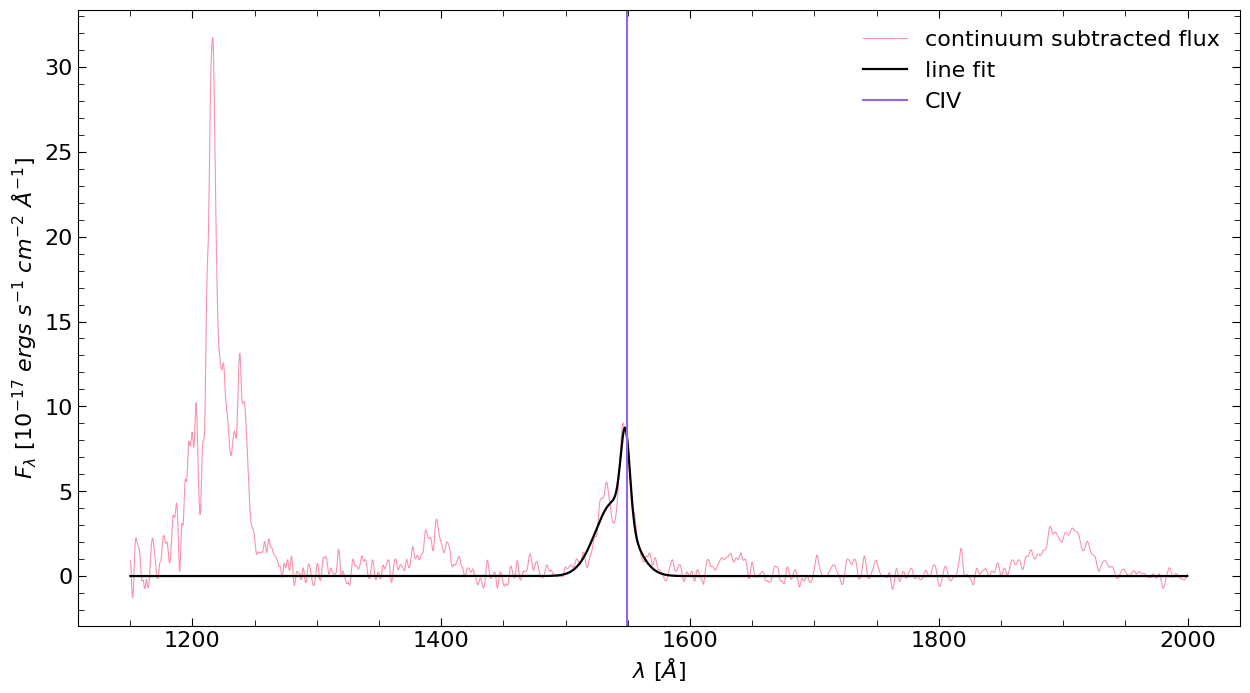


                SDSS: 145623.35+214516.2
                FWHM: 3203.548 vs 4421.831 (Hamann)
                REW: 155.424 vs 102.644 (Hamann)
                kt80: 0.166 vs 0.364 (Hamann)
    
---------------------------------------
---------------------------------------


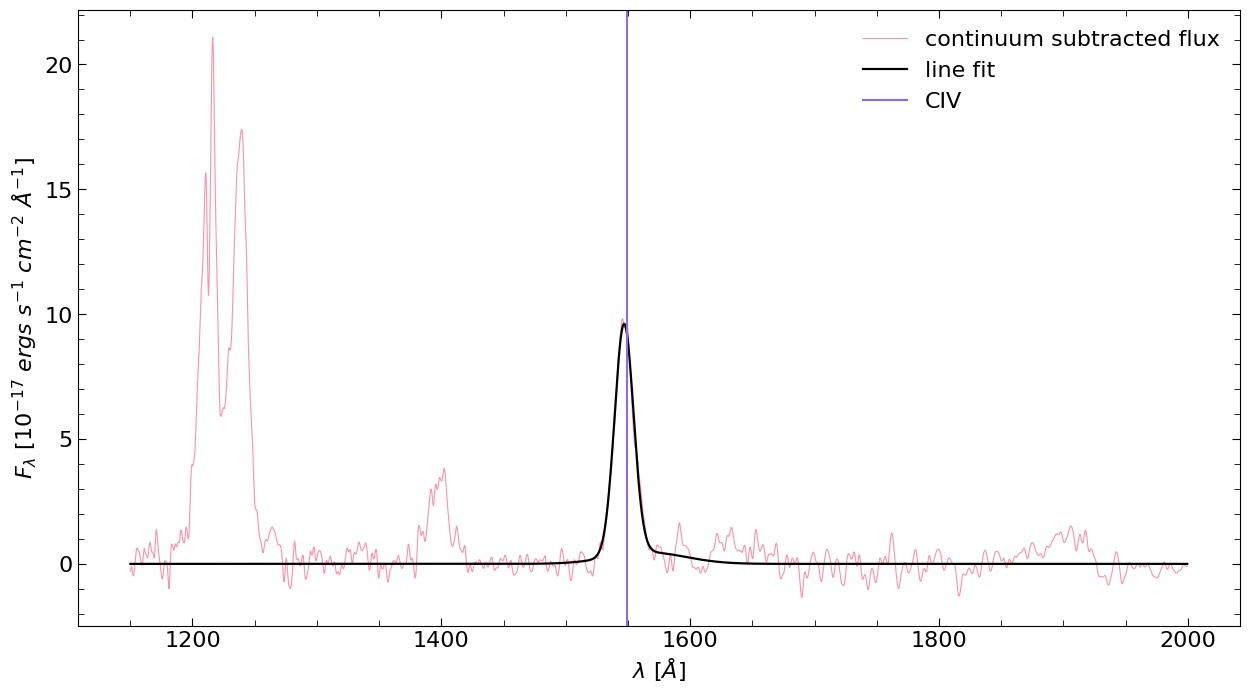


                SDSS: 130936.14+560111.3
                FWHM: 3567.515 vs 3629.606 (Hamann)
                REW: 184.444 vs 160.873 (Hamann)
                kt80: 0.362 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


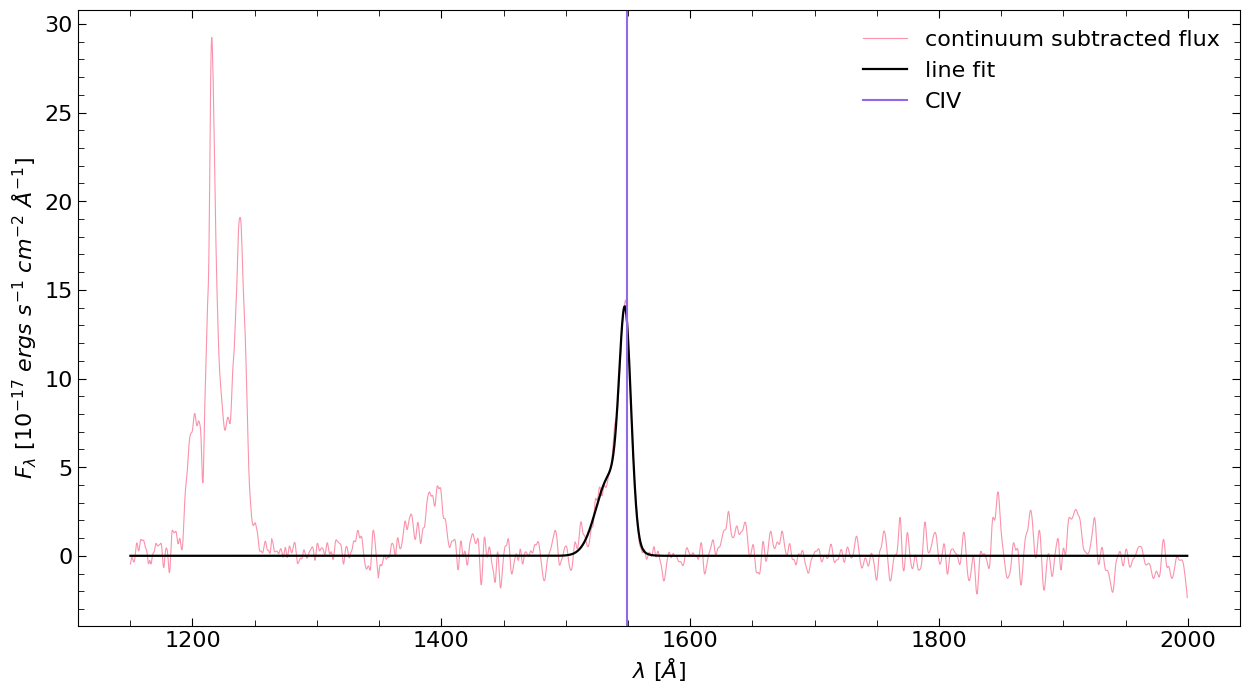


                SDSS: 022052.11+013711.1
                FWHM: 2567.156 vs 2613.405 (Hamann)
                REW: 363.097 vs 328.394 (Hamann)
                kt80: 0.224 vs 0.219 (Hamann)
    
---------------------------------------
---------------------------------------


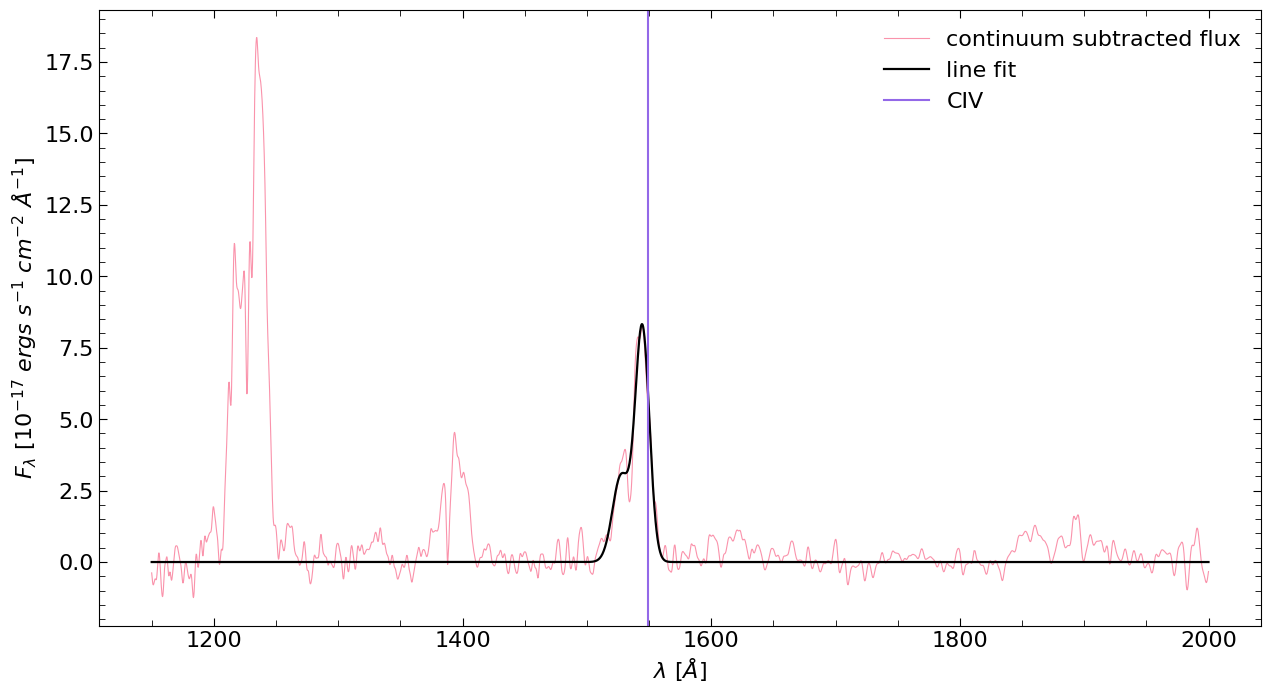


                SDSS: 150117.07+231730.9
                FWHM: 2900.76 vs 4034.664 (Hamann)
                REW: 242.467 vs 231.046 (Hamann)
                kt80: 0.232 vs 0.235 (Hamann)
    
---------------------------------------
---------------------------------------


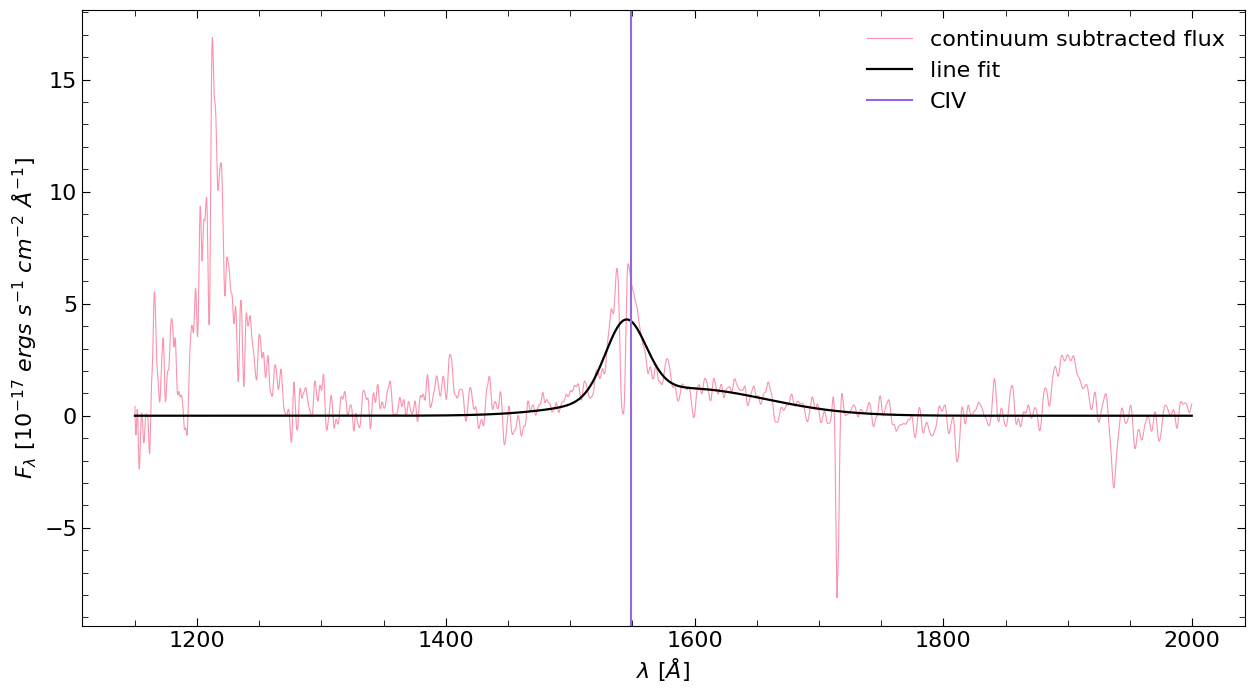


                SDSS: 005044.95-021217.6
                FWHM: 8947.447 vs 4343.058 (Hamann)
                REW: 126.239 vs 147.225 (Hamann)
                kt80: 0.181 vs 0.193 (Hamann)
    
---------------------------------------
---------------------------------------


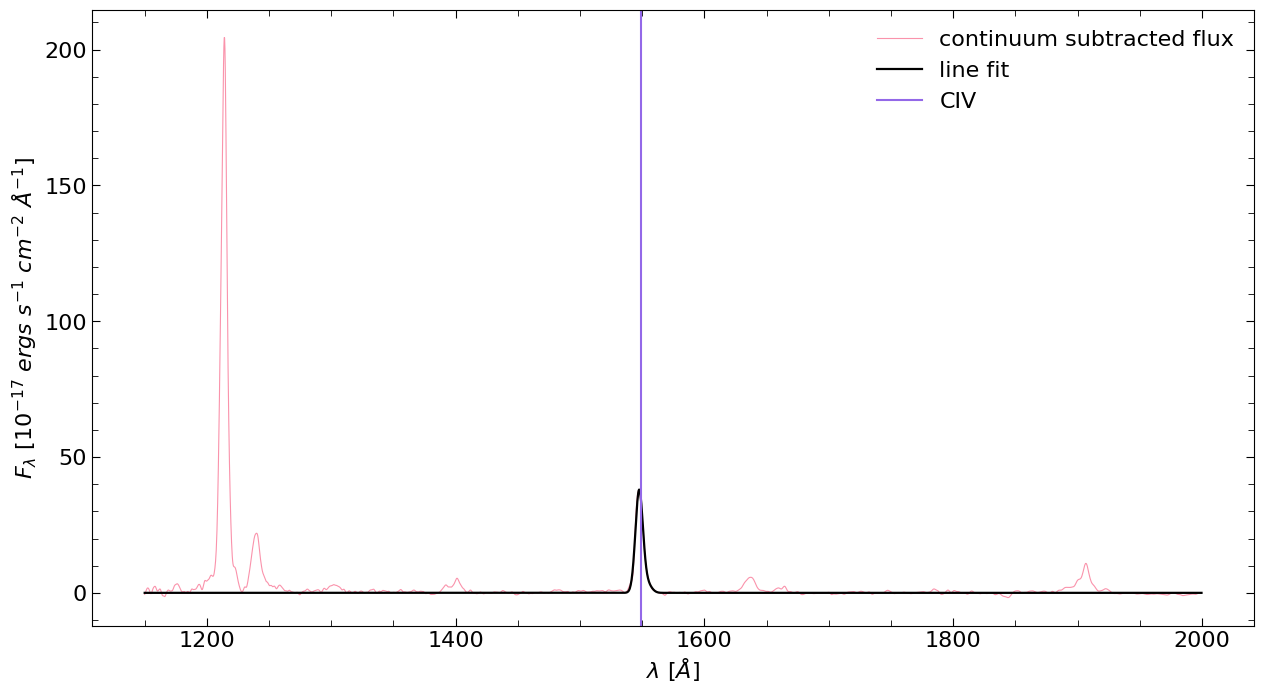


                SDSS: 131833.76+261746.9
                FWHM: 1419.996 vs 1280.057 (Hamann)
                REW: 205.223 vs 149.805 (Hamann)
                kt80: 0.356 vs 0.356 (Hamann)
    
---------------------------------------
---------------------------------------


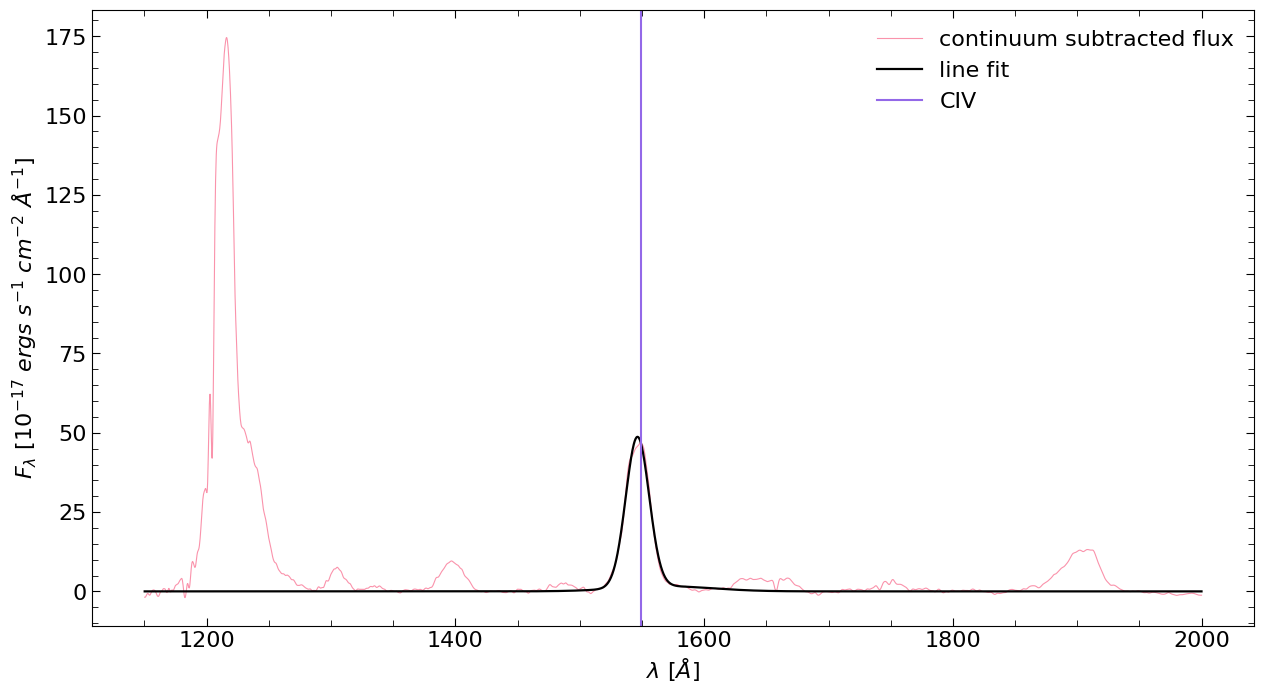


                SDSS: 095823.14+500018.1
                FWHM: 4353.203 vs 4344.558 (Hamann)
                REW: 319.937 vs 262.82 (Hamann)
                kt80: 0.366 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


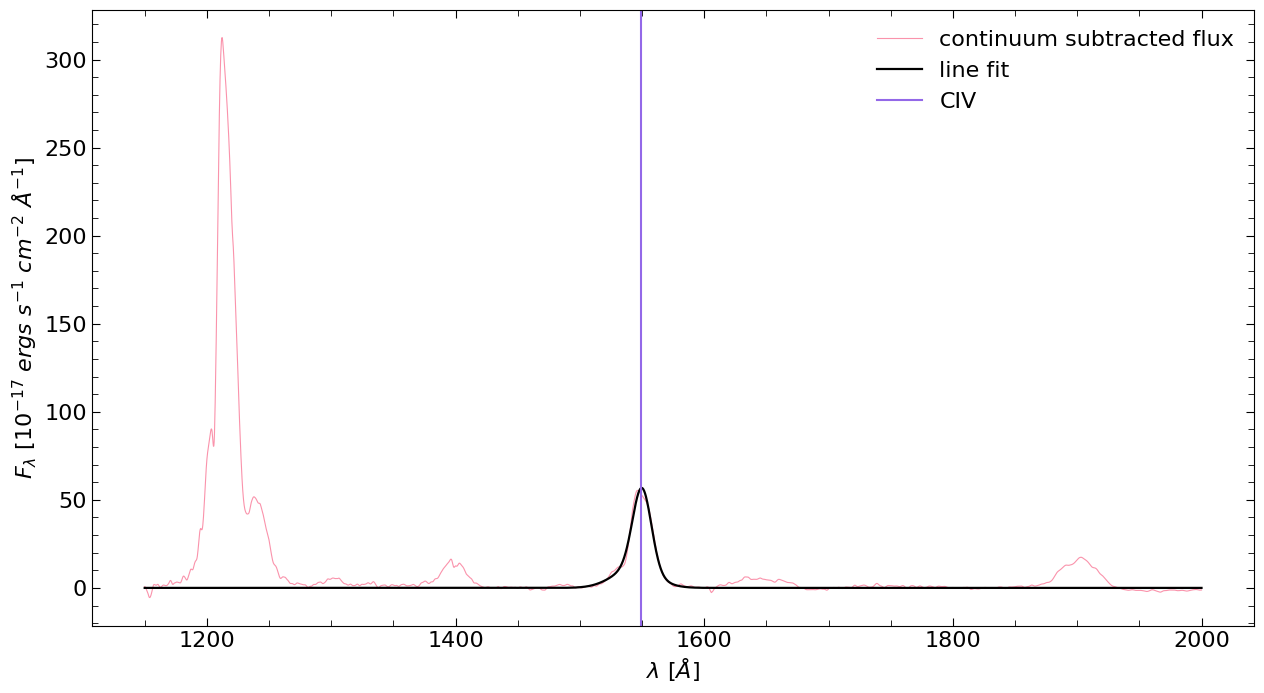


                SDSS: 101324.53+342702.6
                FWHM: 3822.601 vs 4157.047 (Hamann)
                REW: 230.956 vs 204.531 (Hamann)
                kt80: 0.333 vs 0.344 (Hamann)
    
---------------------------------------
---------------------------------------


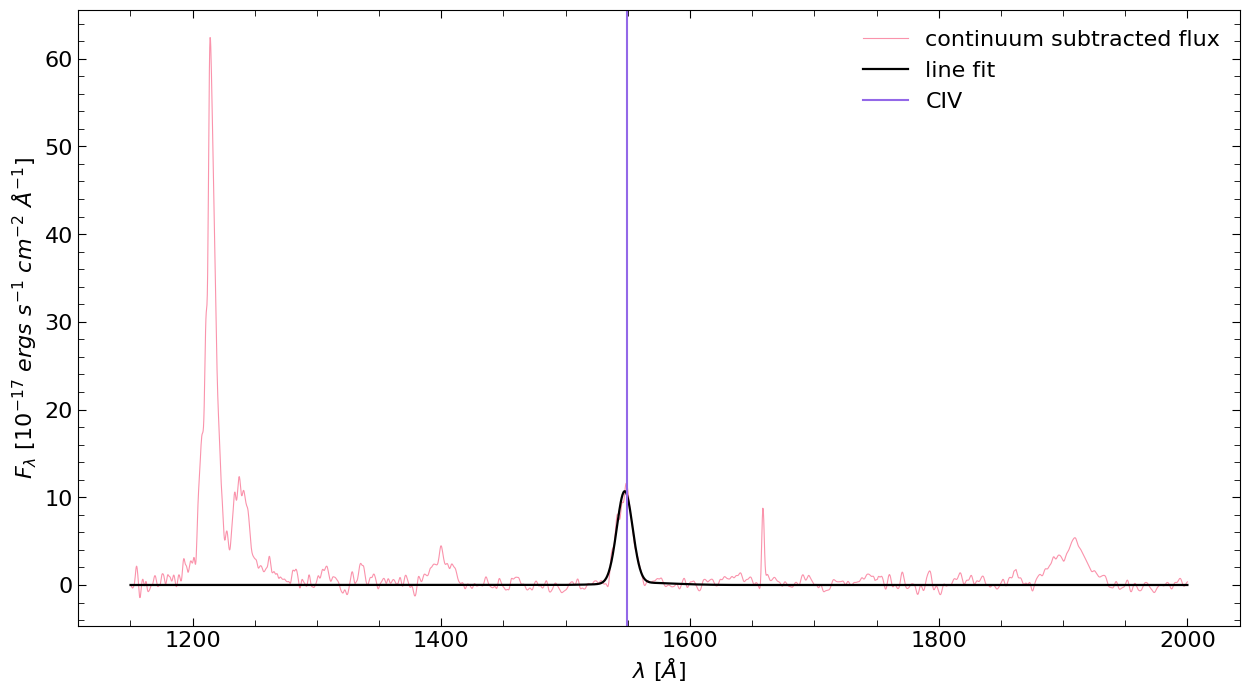


                SDSS: 020932.15+312202.7
                FWHM: 2922.526 vs 2180.064 (Hamann)
                REW: 136.281 vs 107.677 (Hamann)
                kt80: 0.368 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


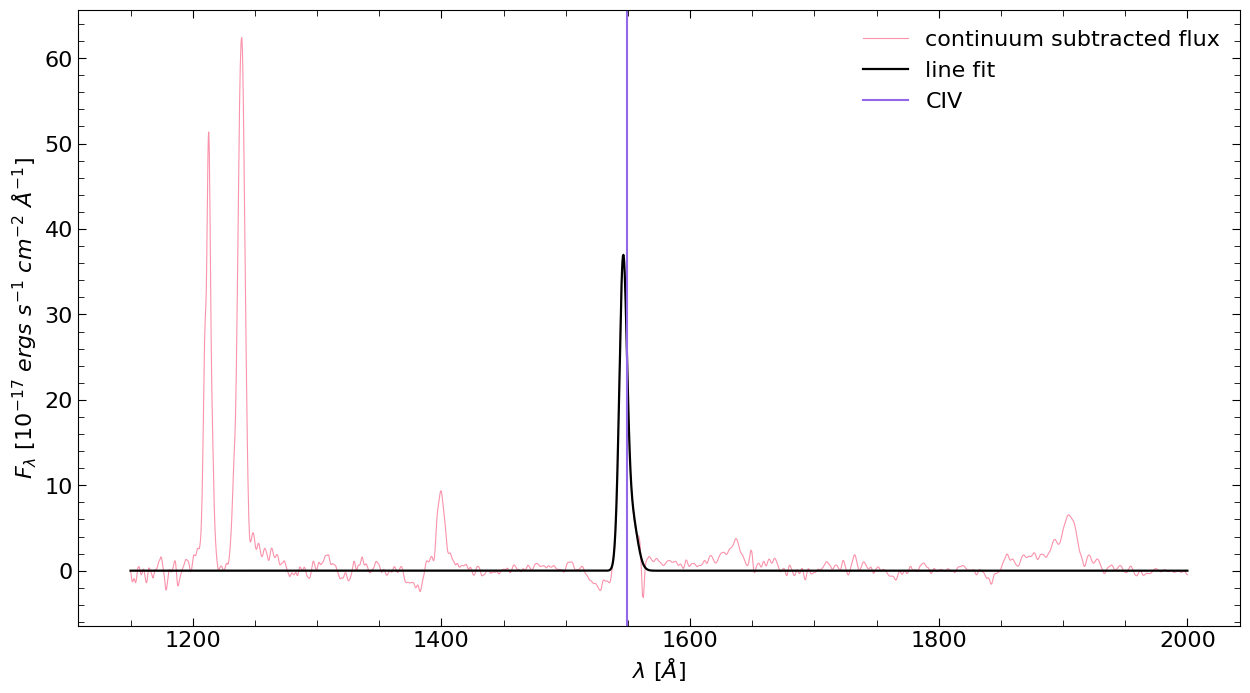


                SDSS: 121253.47+595801.2
                FWHM: 1514.815 vs 1402.242 (Hamann)
                REW: 134.955 vs 106.836 (Hamann)
                kt80: 0.322 vs 0.341 (Hamann)
    
---------------------------------------
---------------------------------------


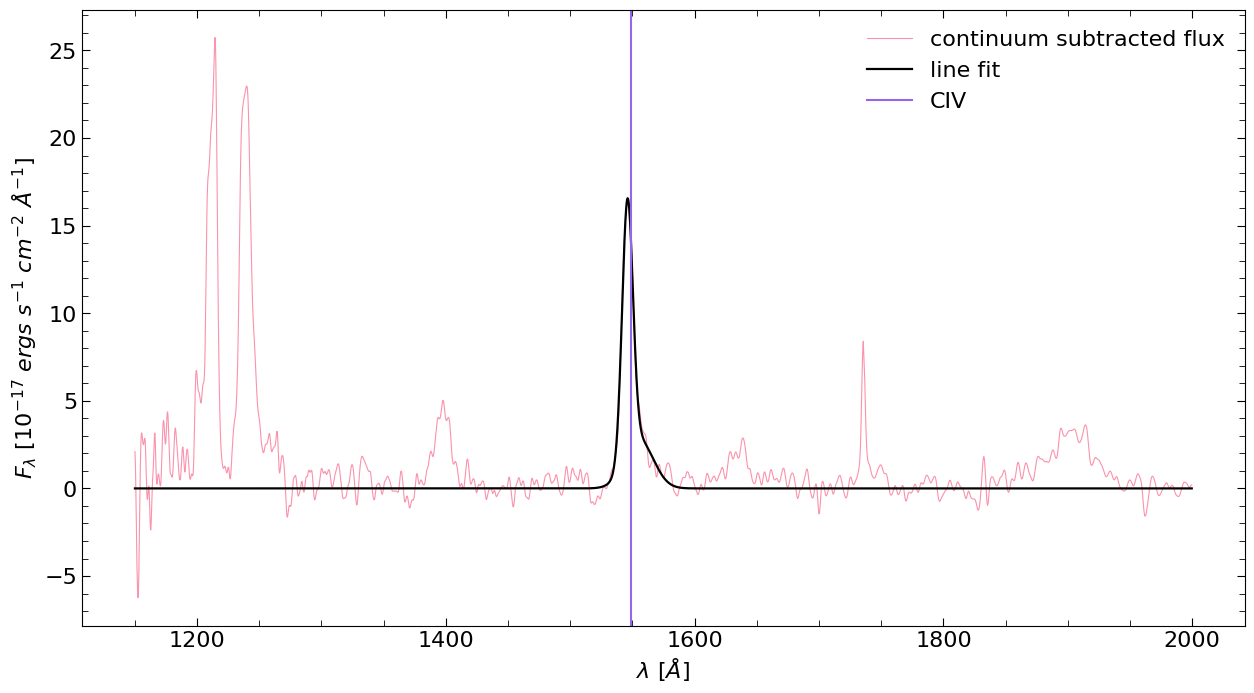


                SDSS: 113349.71+634740.0
                FWHM: 2168.06 vs 2081.074 (Hamann)
                REW: 170.407 vs 120.702 (Hamann)
                kt80: 0.323 vs 0.337 (Hamann)
    
---------------------------------------
---------------------------------------


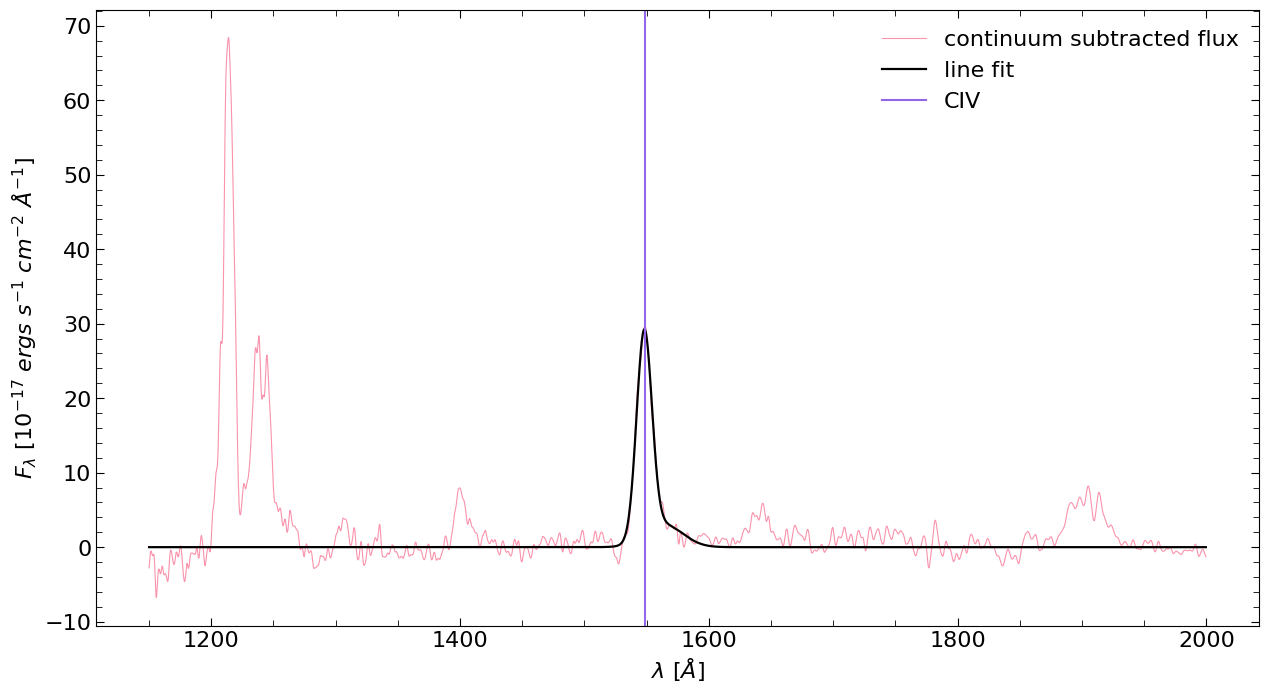


                SDSS: 014111.13-031852.5
                FWHM: 2933.33 vs 2985.648 (Hamann)
                REW: 116.521 vs 101.008 (Hamann)
                kt80: 0.351 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


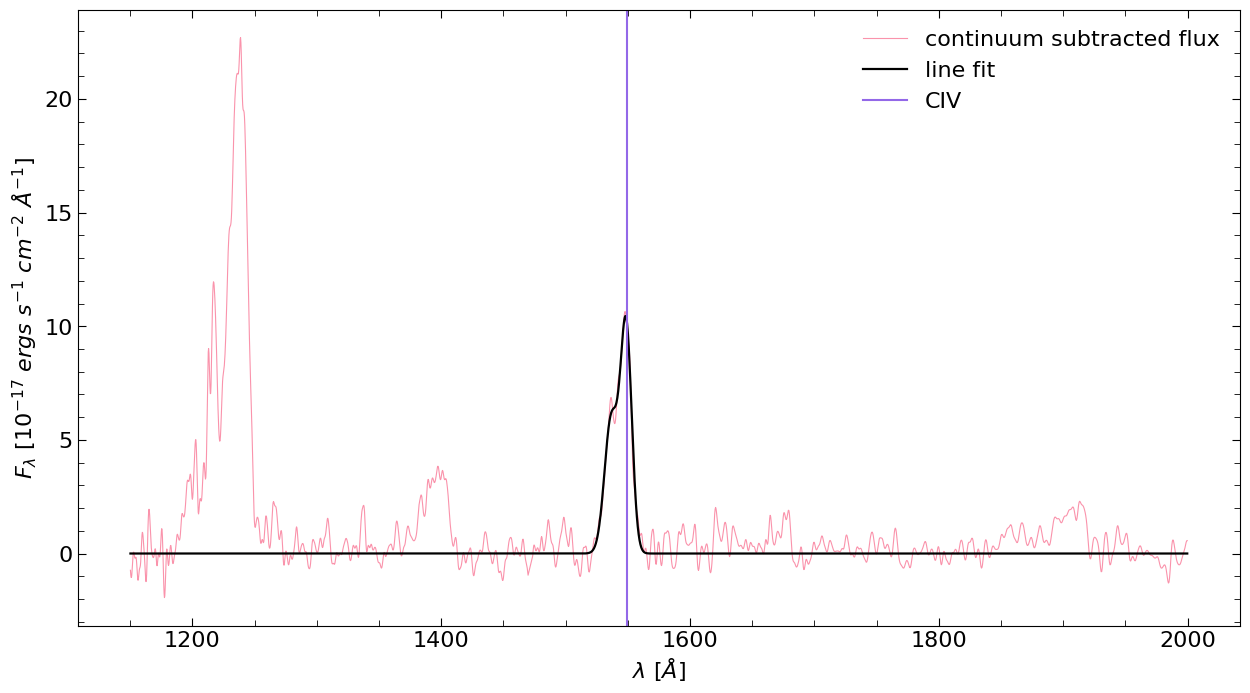


                SDSS: 002400.25+245031.9
                FWHM: 3854.336 vs 3523.282 (Hamann)
                REW: 221.83 vs 143.69 (Hamann)
                kt80: 0.259 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


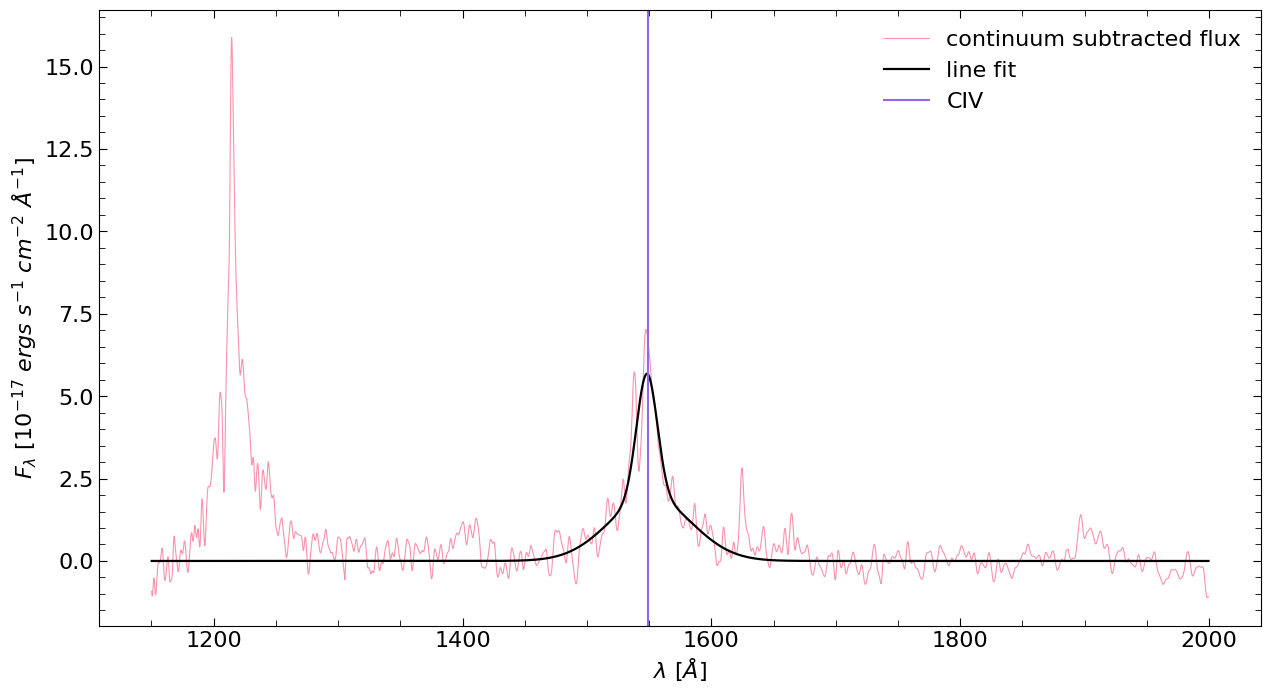


                SDSS: 110202.68-000752.7
                FWHM: 5078.765 vs 3766.854 (Hamann)
                REW: 144.589 vs 120.732 (Hamann)
                kt80: 0.202 vs 0.179 (Hamann)
    
---------------------------------------
---------------------------------------


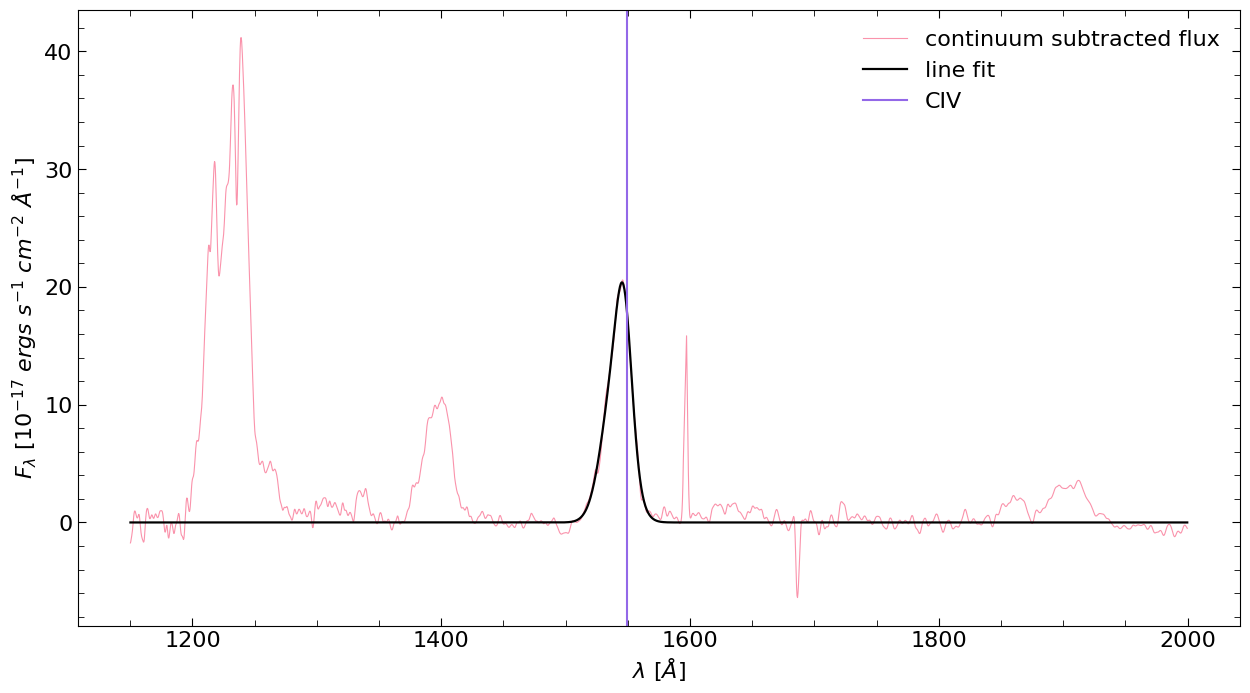


                SDSS: 160431.55+563354.2
                FWHM: 4197.048 vs 4221.468 (Hamann)
                REW: 260.575 vs 204.844 (Hamann)
                kt80: 0.325 vs 0.343 (Hamann)
    
---------------------------------------
---------------------------------------
SDSS: 083448.48+015921.1
Rejected because: Continuum too steep (alpha=4.17)


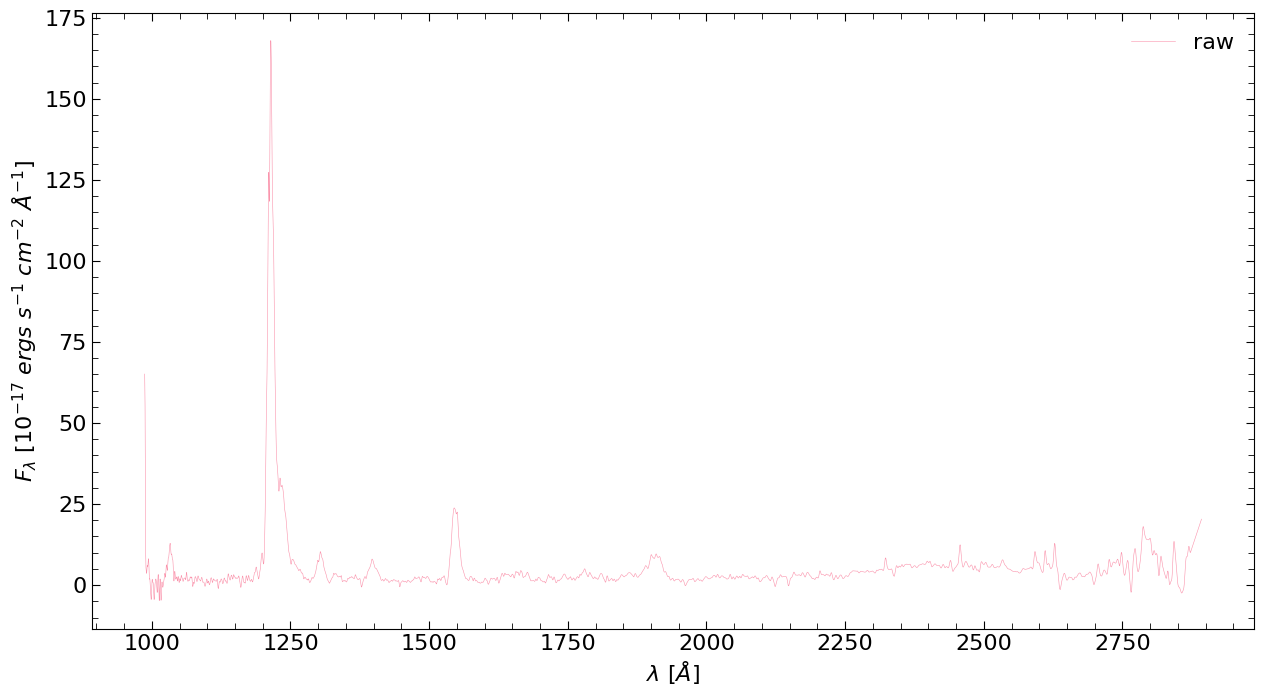

---------------------------------------
---------------------------------------


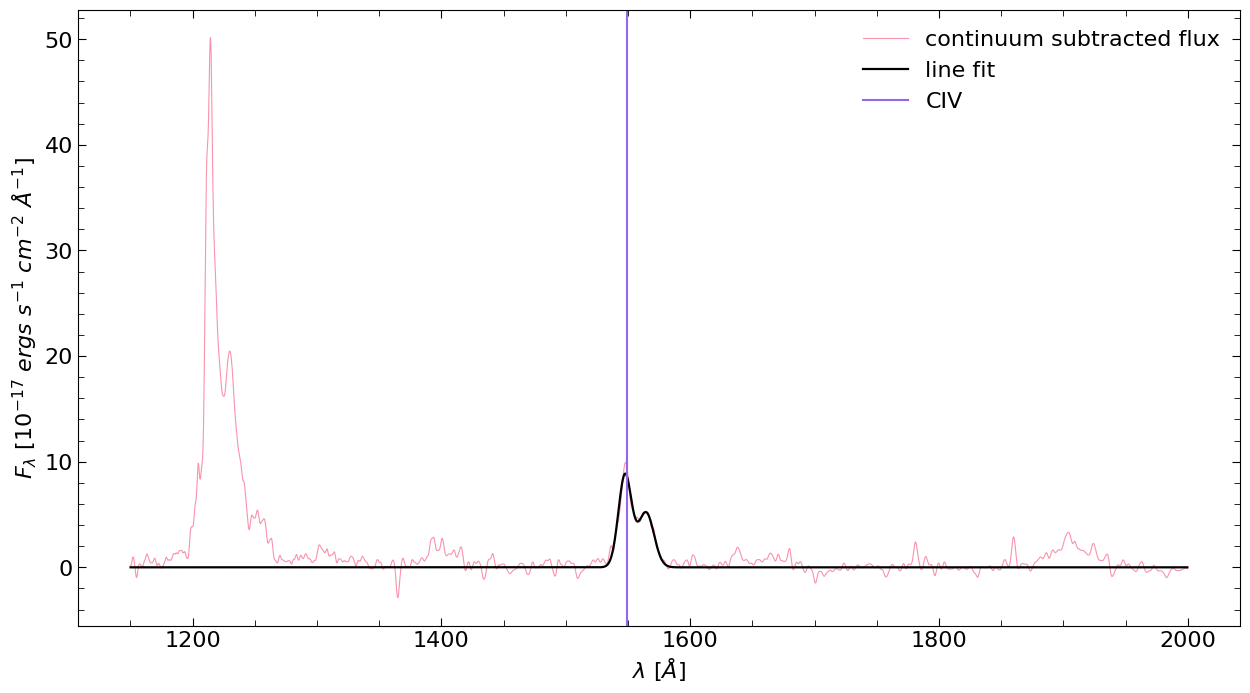


                SDSS: 225438.30+232714.5
                FWHM: 5151.613 vs 4411.578 (Hamann)
                REW: 406.221 vs 415.245 (Hamann)
                kt80: 0.213 vs 0.358 (Hamann)
    
---------------------------------------
---------------------------------------


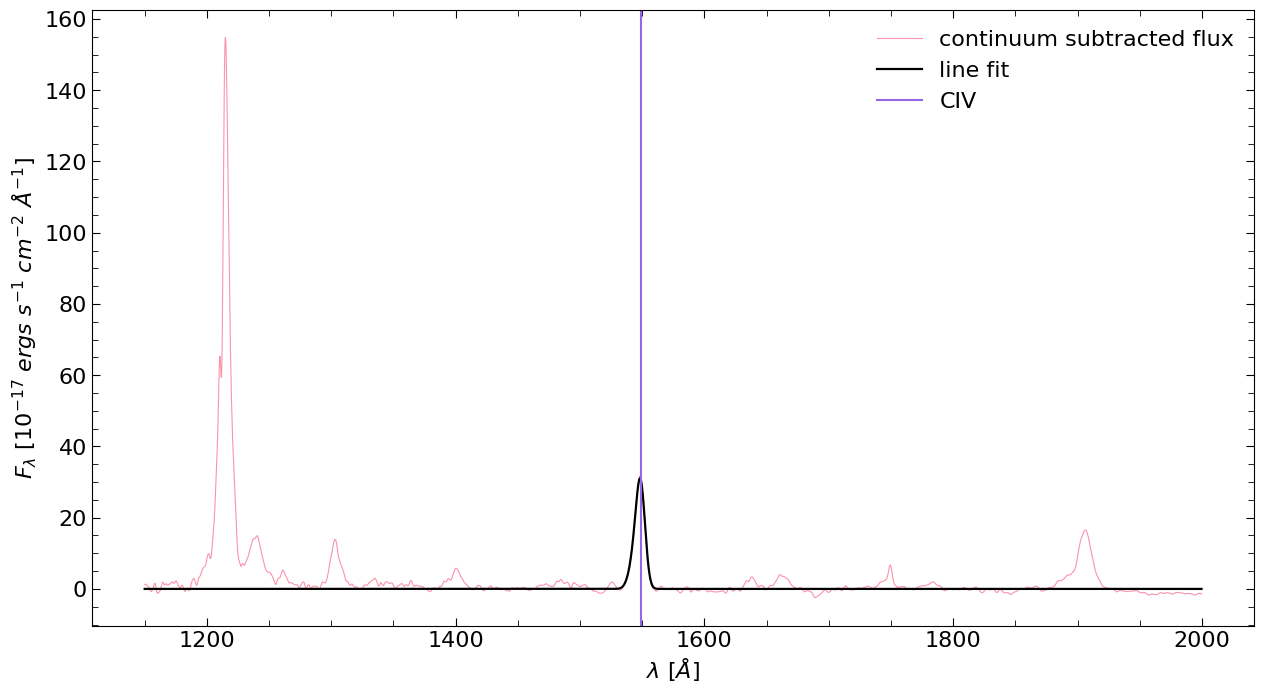


                SDSS: 102353.44+580004.9
                FWHM: 1883.116 vs 2107.266 (Hamann)
                REW: 154.995 vs 116.39 (Hamann)
                kt80: 0.351 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


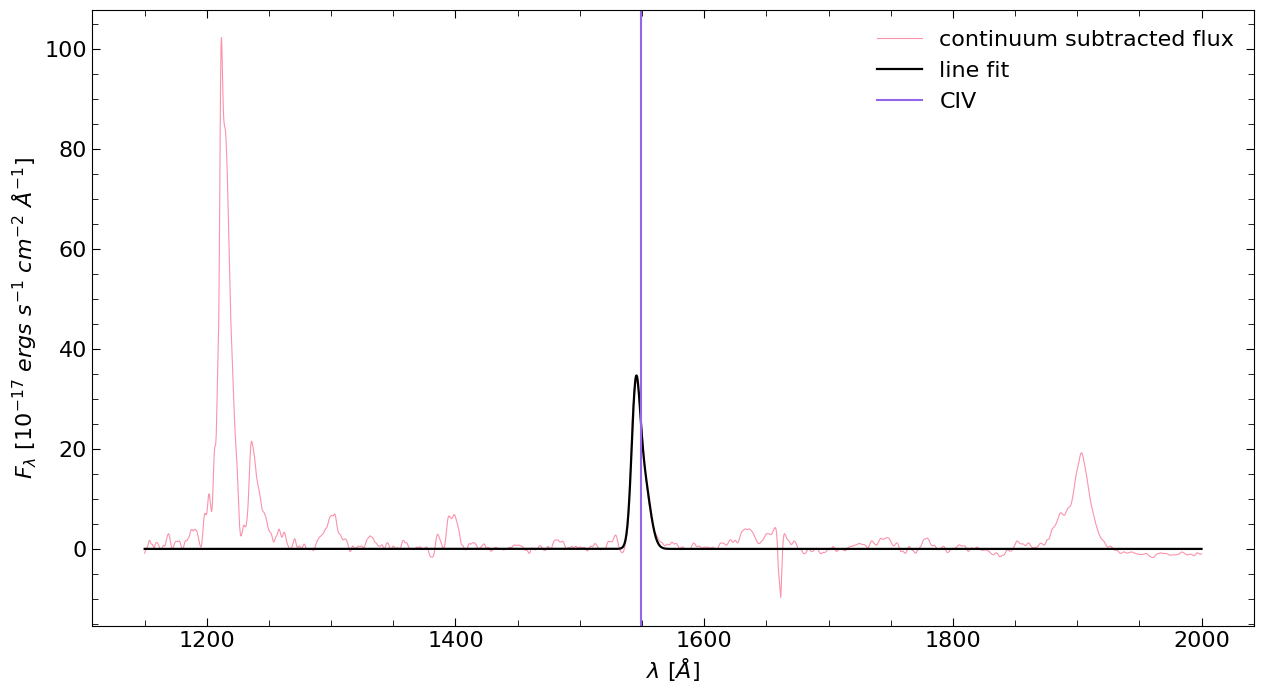


                SDSS: 145354.70+190343.9
                FWHM: 2051.954 vs 2046.257 (Hamann)
                REW: 211.087 vs 141.71 (Hamann)
                kt80: 0.296 vs 0.35 (Hamann)
    
---------------------------------------
---------------------------------------


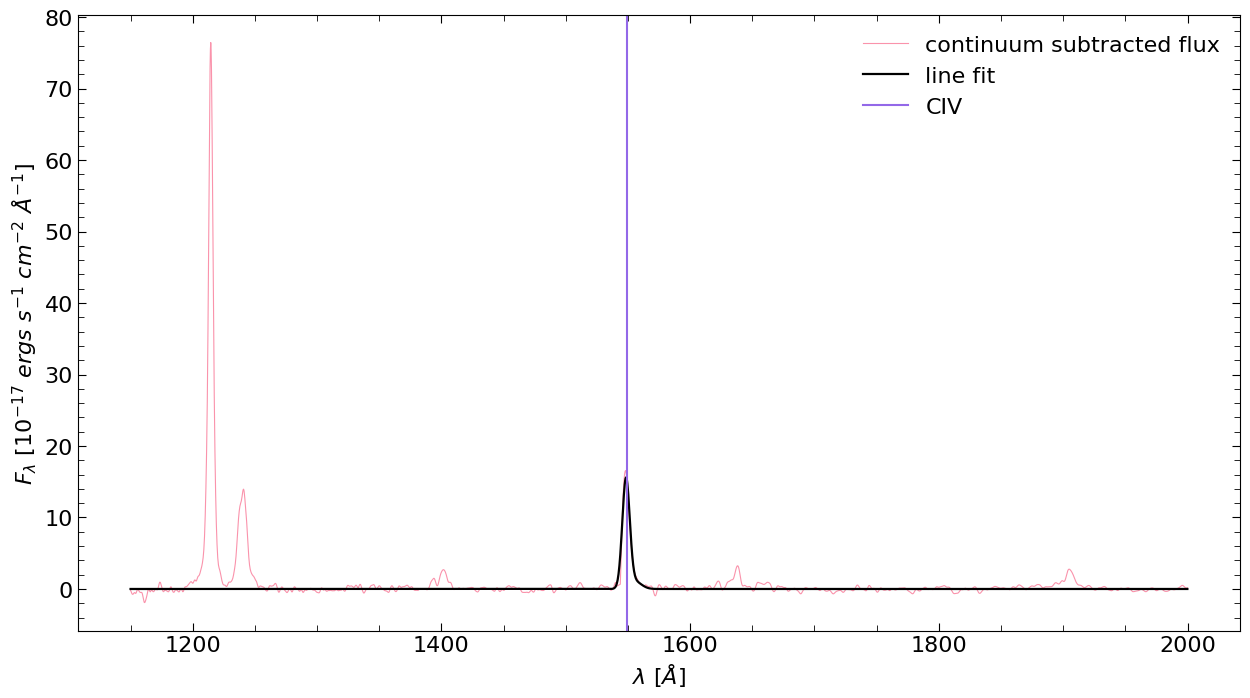


                SDSS: 223754.52+065026.6
                FWHM: 1404.725 vs 1390.575 (Hamann)
                REW: 146.88 vs 140.677 (Hamann)
                kt80: 0.36 vs 0.356 (Hamann)
    
---------------------------------------
---------------------------------------


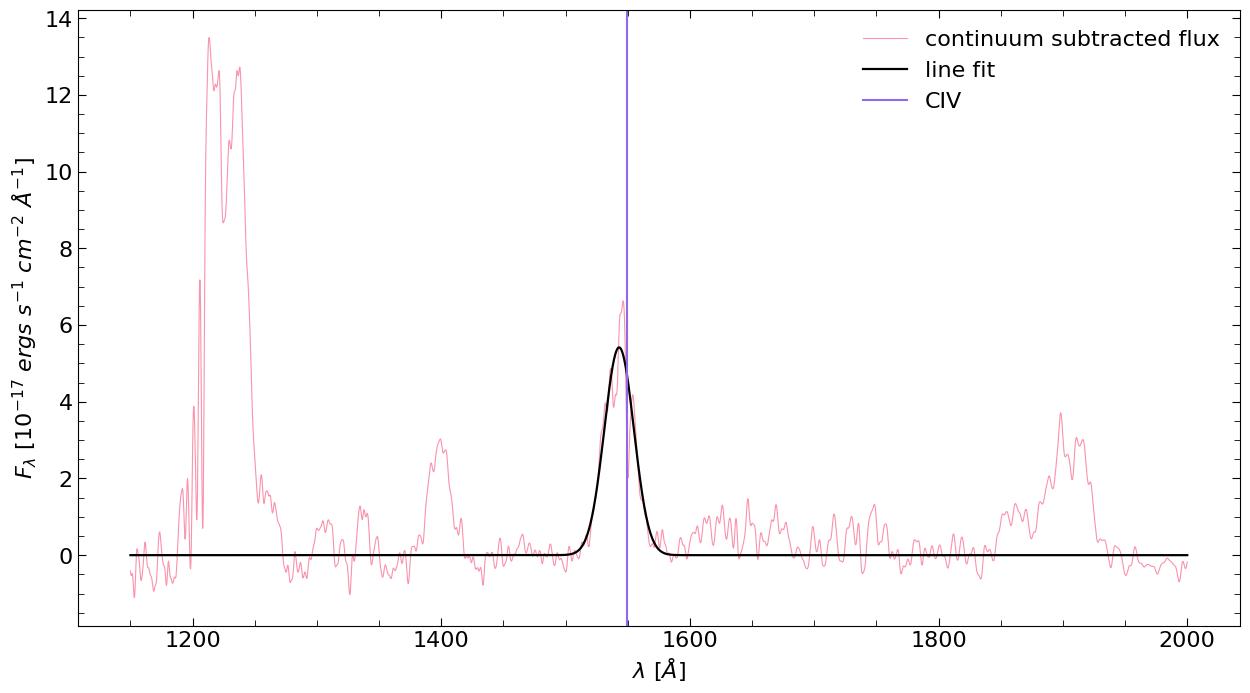


                SDSS: 085451.11+173009.1
                FWHM: 5415.198 vs 4199.357 (Hamann)
                REW: 100.381 vs 120.014 (Hamann)
                kt80: 0.372 vs 0.37 (Hamann)
    
---------------------------------------
---------------------------------------


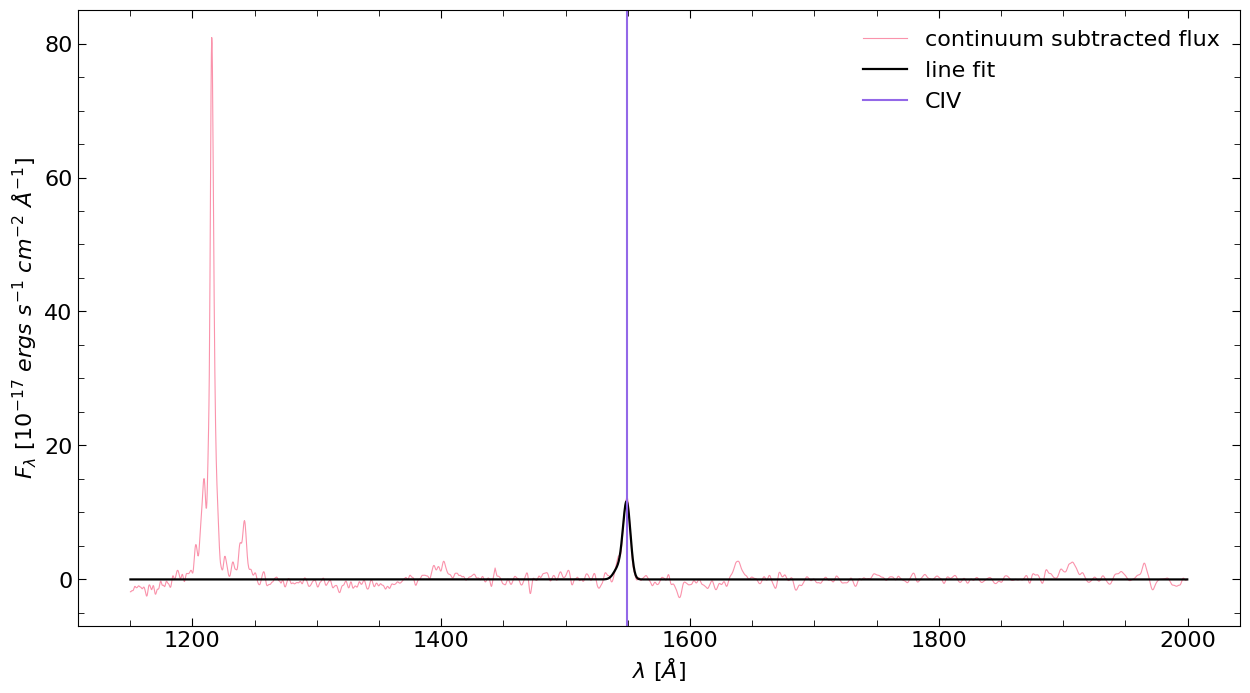


                SDSS: 154743.78+615431.1
                FWHM: 1449.733 vs 1176.837 (Hamann)
                REW: 70.469 vs 128.087 (Hamann)
                kt80: 0.336 vs 0.262 (Hamann)
    
---------------------------------------
---------------------------------------


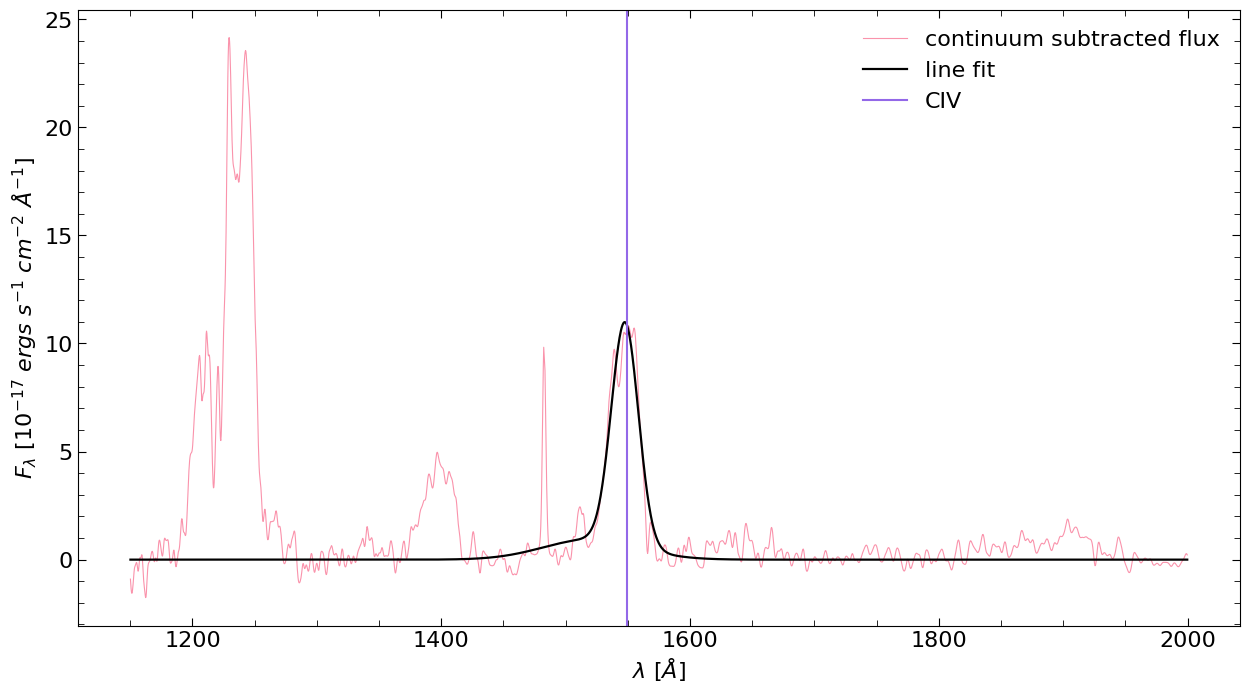


                SDSS: 104611.50+024351.6
                FWHM: 5184.023 vs 4854.269 (Hamann)
                REW: 258.959 vs 217.582 (Hamann)
                kt80: 0.354 vs 0.354 (Hamann)
    
---------------------------------------
---------------------------------------


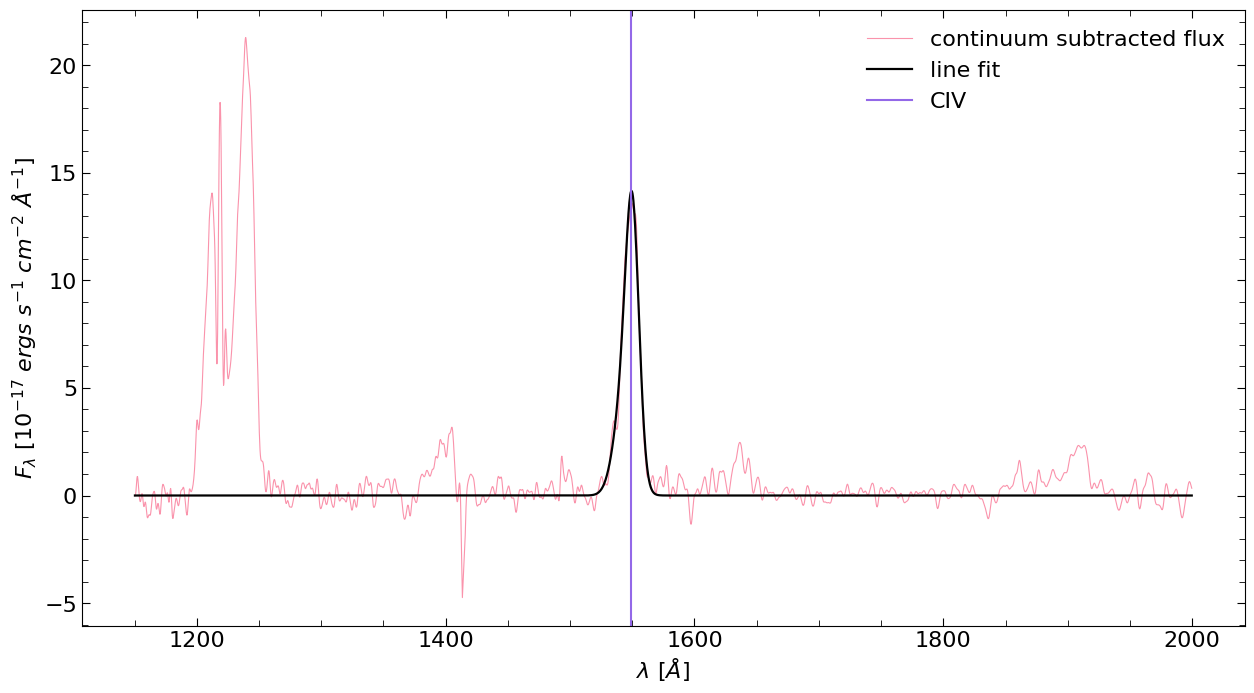


                SDSS: 130421.12+083752.2
                FWHM: 2883.43 vs 3013.626 (Hamann)
                REW: 206.383 vs 131.622 (Hamann)
                kt80: 0.335 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


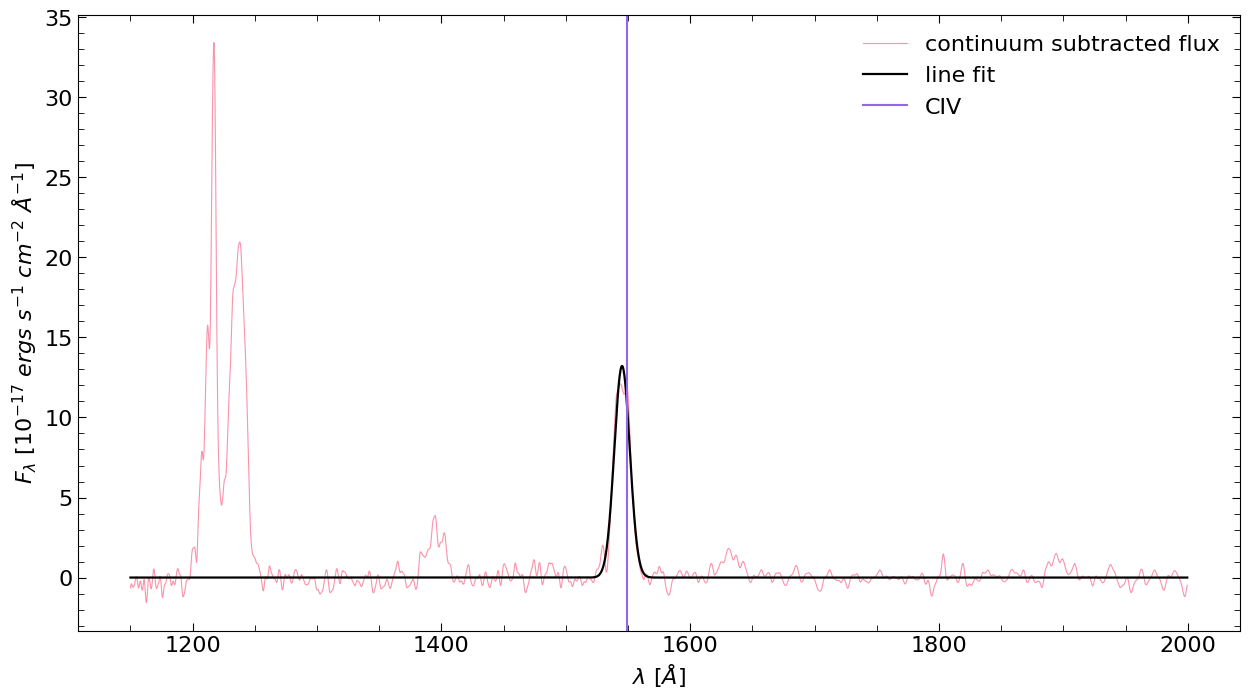


                SDSS: 134417.34+445459.4
                FWHM: 2834.883 vs 2870.515 (Hamann)
                REW: 244.023 vs 309.962 (Hamann)
                kt80: 0.372 vs 0.36 (Hamann)
    
---------------------------------------
---------------------------------------


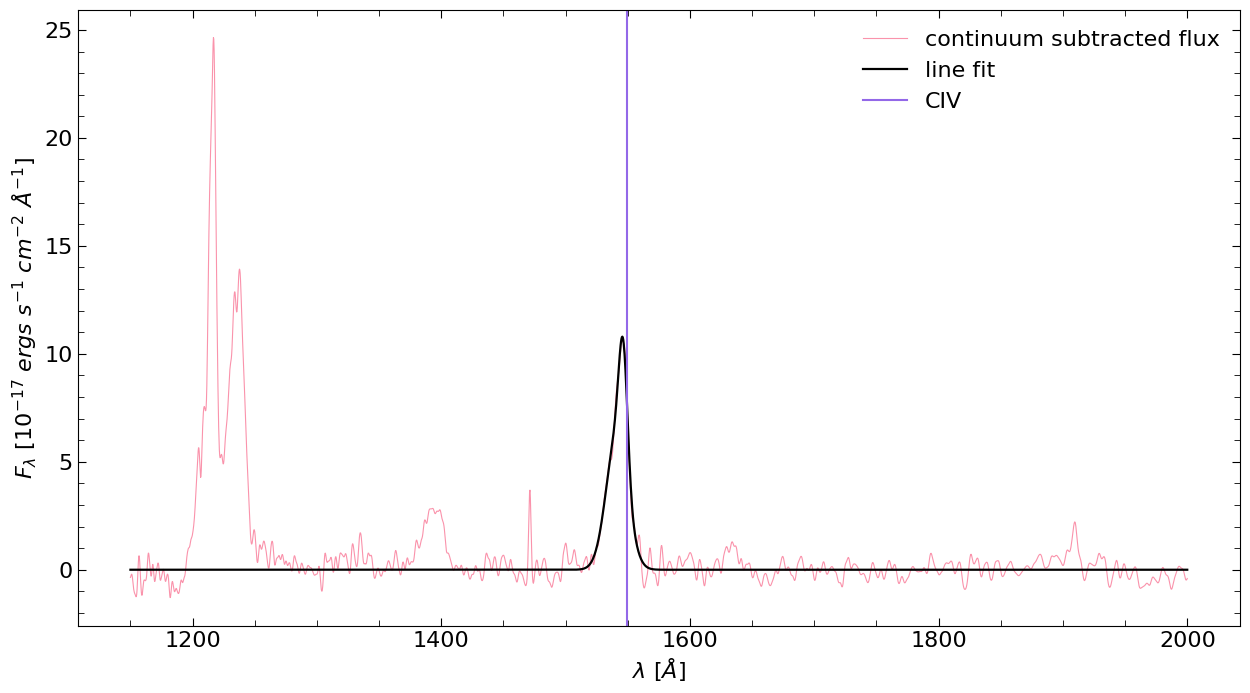


                SDSS: 124106.97+295220.8
                FWHM: 2820.646 vs 2599.948 (Hamann)
                REW: 132.165 vs 137.98 (Hamann)
                kt80: 0.259 vs 0.199 (Hamann)
    
---------------------------------------
---------------------------------------


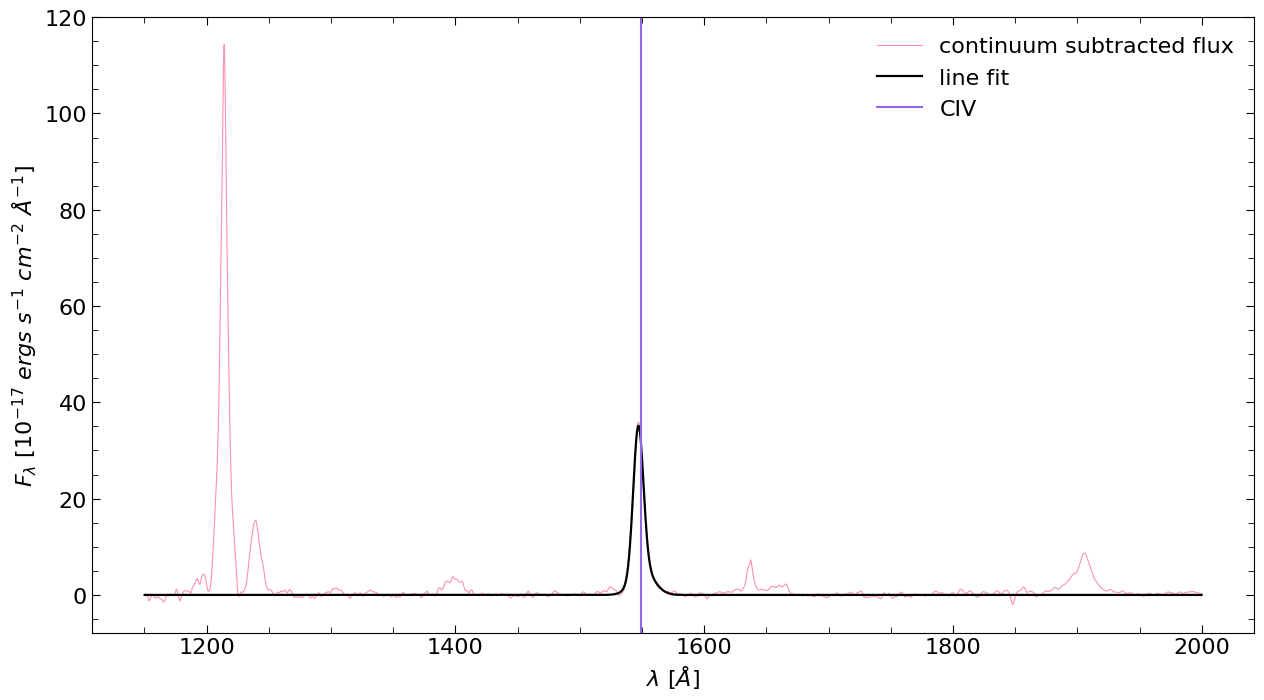


                SDSS: 125019.46+630638.6
                FWHM: 2010.654 vs 1881.225 (Hamann)
                REW: 315.435 vs 242.256 (Hamann)
                kt80: 0.348 vs 0.341 (Hamann)
    
---------------------------------------
---------------------------------------


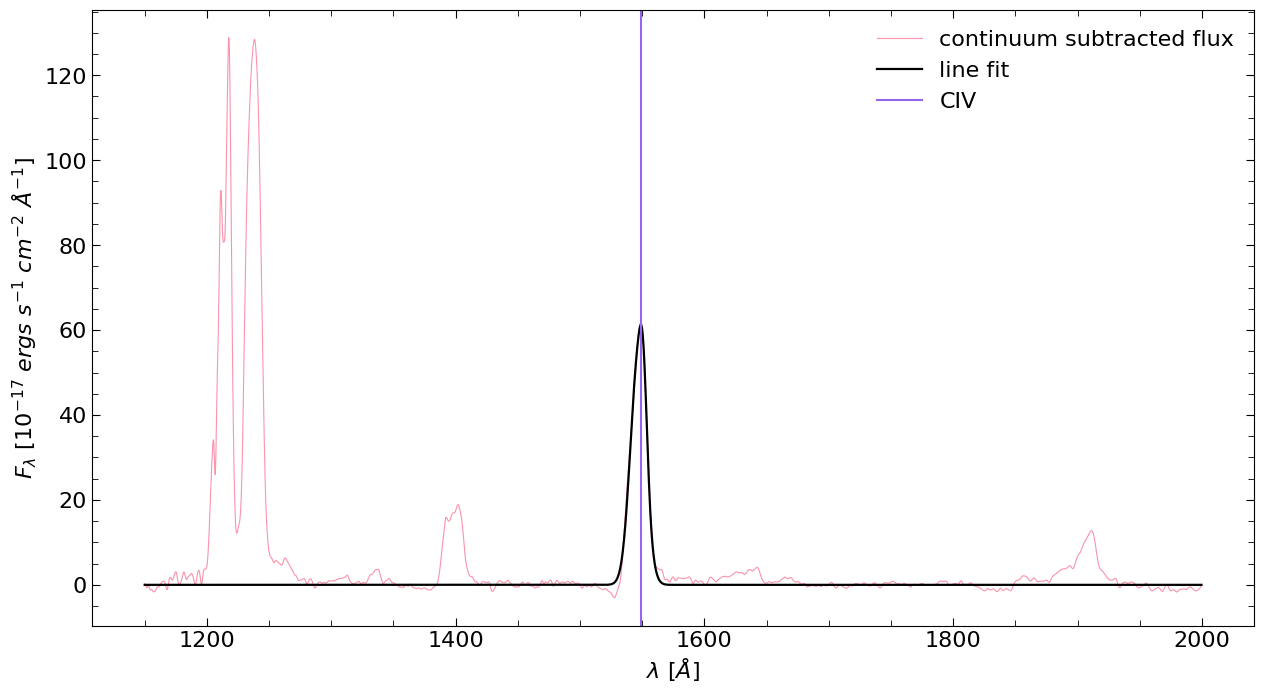


                SDSS: 131047.78+322518.3
                FWHM: 2796.677 vs 2793.839 (Hamann)
                REW: 248.523 vs 226.394 (Hamann)
                kt80: 0.38 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


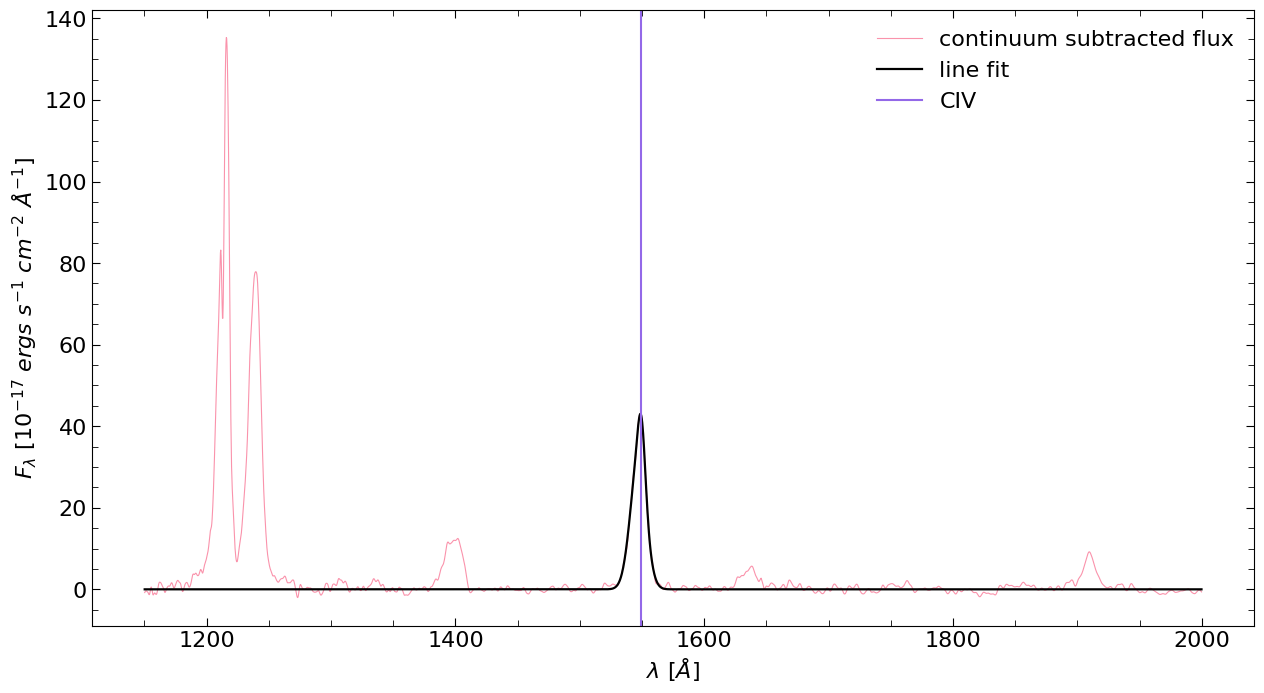


                SDSS: 082653.42+054247.3
                FWHM: 2428.505 vs 2433.822 (Hamann)
                REW: 184.418 vs 204.619 (Hamann)
                kt80: 0.312 vs 0.358 (Hamann)
    
---------------------------------------
---------------------------------------


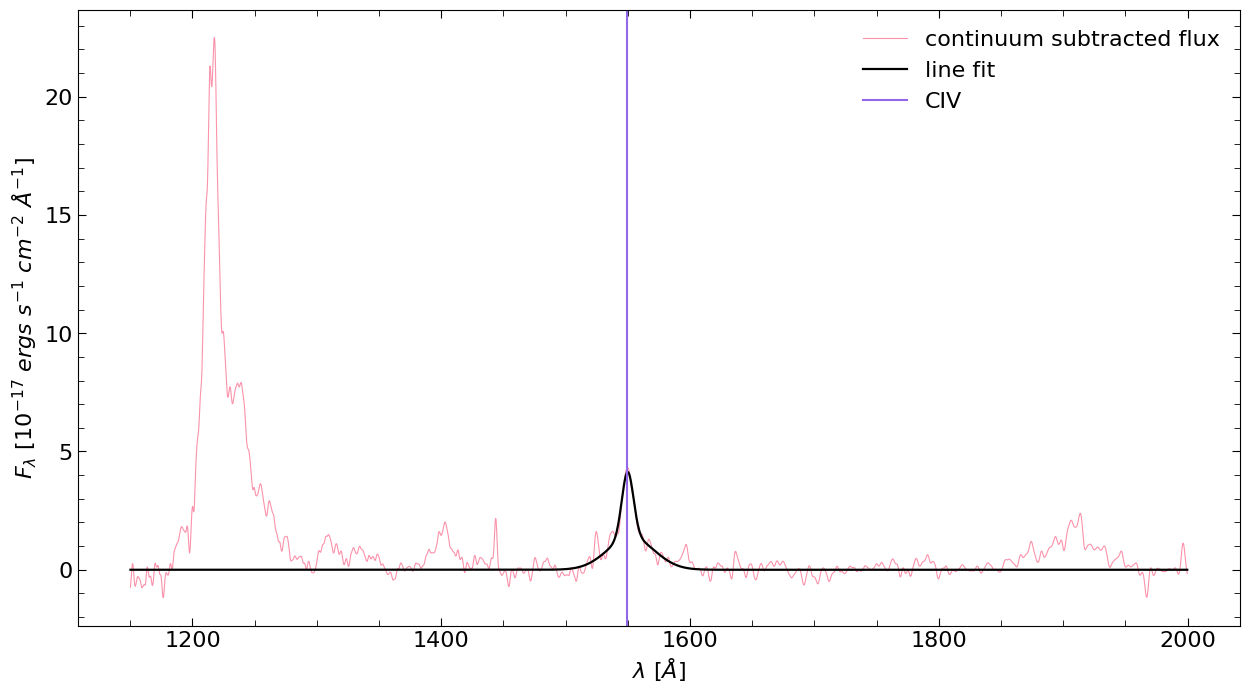


                SDSS: 102447.32-013633.8
                FWHM: 2844.364 vs 2843.202 (Hamann)
                REW: 118.78 vs 192.349 (Hamann)
                kt80: 0.204 vs 0.148 (Hamann)
    
---------------------------------------
---------------------------------------


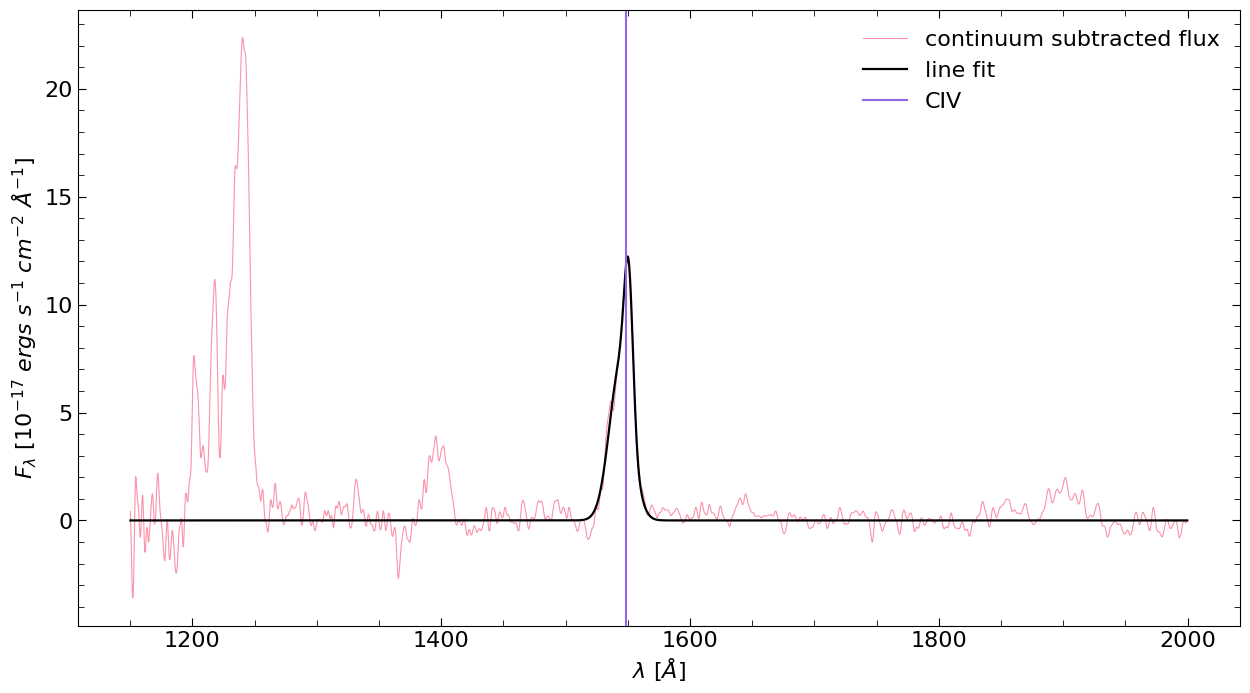


                SDSS: 102130.74+214438.4
                FWHM: 3133.507 vs 3566.695 (Hamann)
                REW: 217.113 vs 155.466 (Hamann)
                kt80: 0.247 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


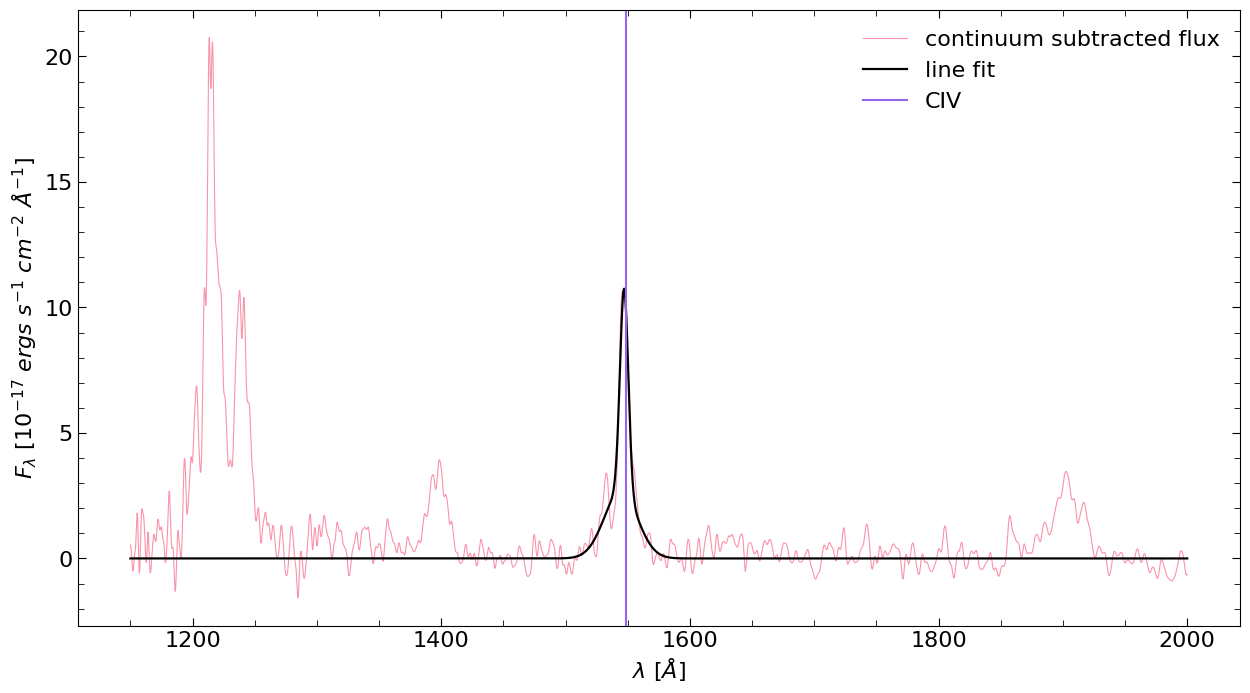


                SDSS: 134001.90+322155.9
                FWHM: 1853.339 vs 1822.703 (Hamann)
                REW: 156.478 vs 130.709 (Hamann)
                kt80: 0.255 vs 0.207 (Hamann)
    
---------------------------------------
---------------------------------------


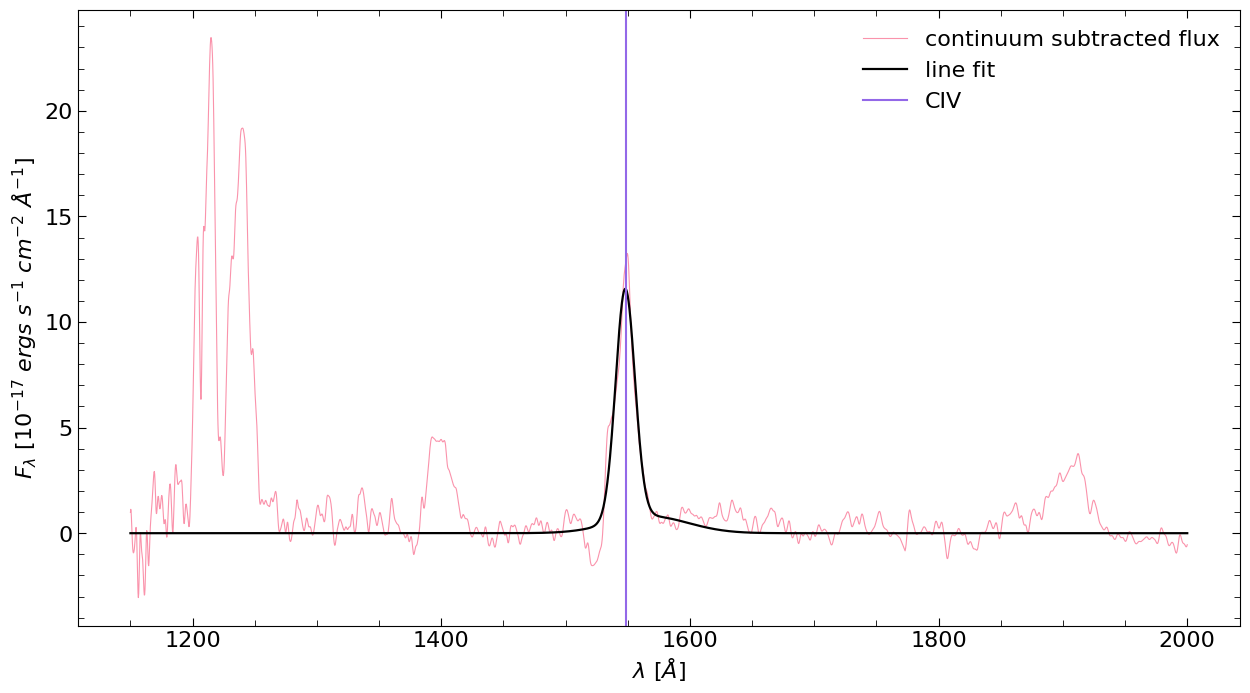


                SDSS: 222421.63+174041.2
                FWHM: 3683.843 vs 2748.994 (Hamann)
                REW: 139.949 vs 110.457 (Hamann)
                kt80: 0.357 vs 0.191 (Hamann)
    
---------------------------------------
---------------------------------------


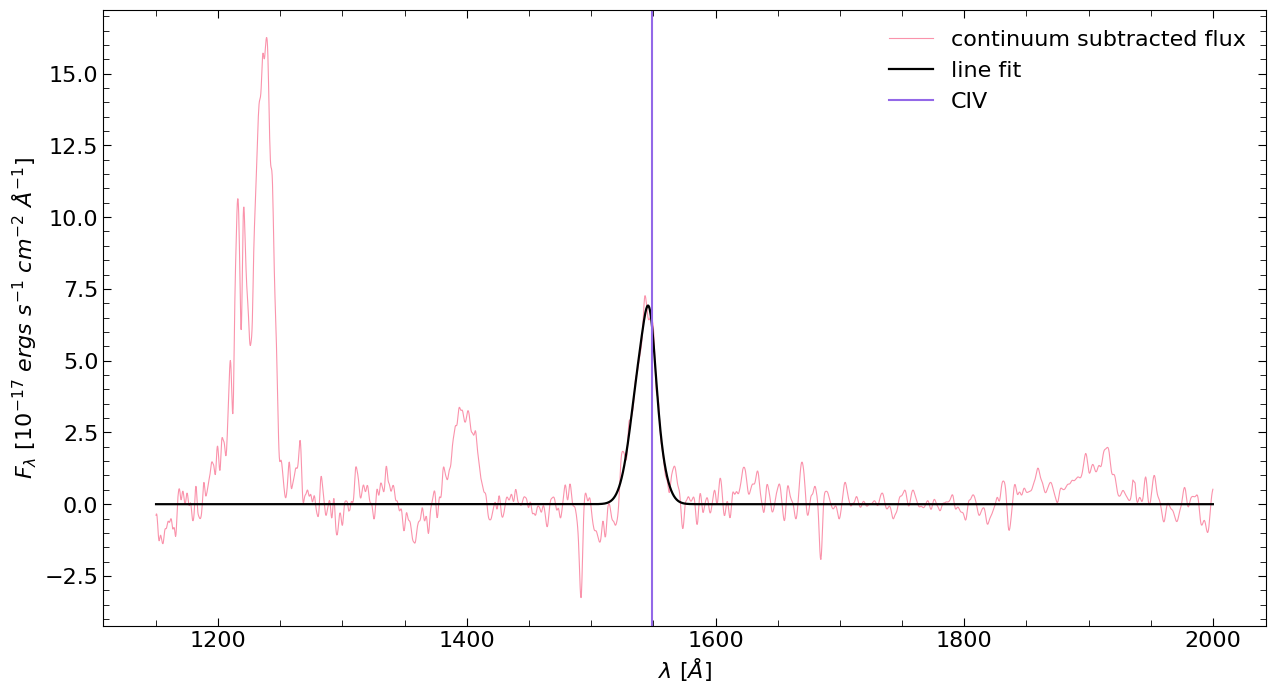


                SDSS: 134450.51+140139.2
                FWHM: 3940.225 vs 4487.034 (Hamann)
                REW: 121.246 vs 132.41 (Hamann)
                kt80: 0.327 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


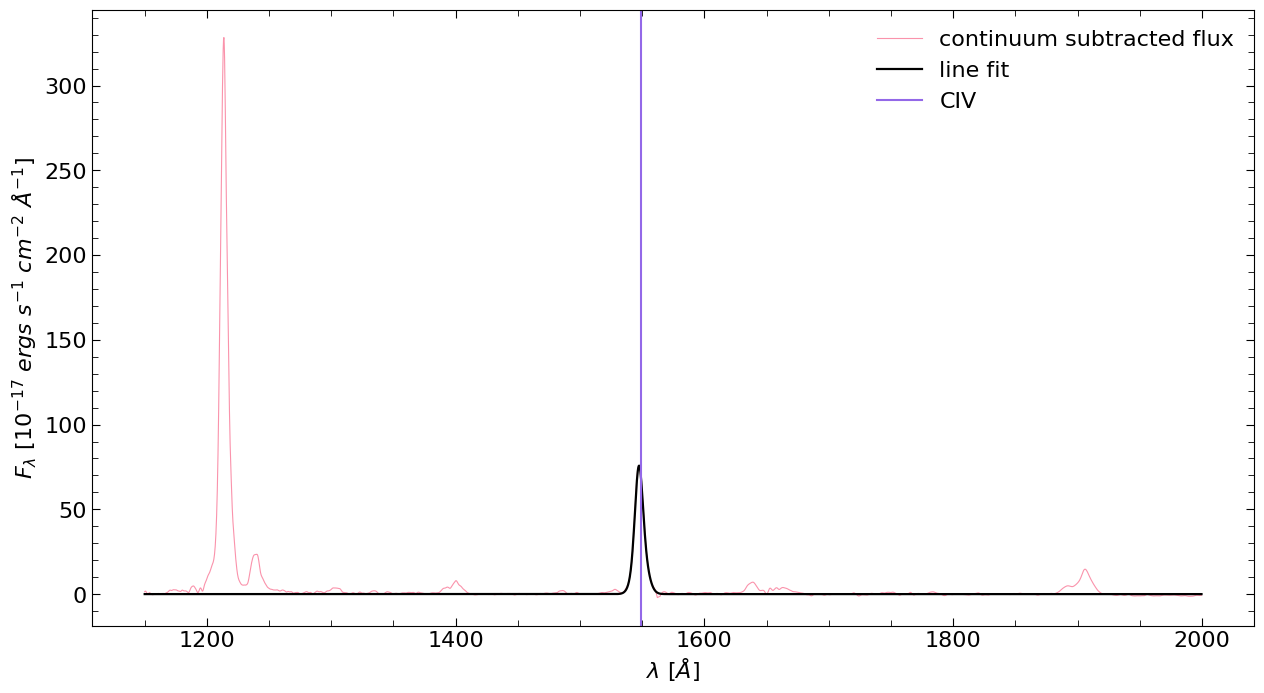


                SDSS: 232828.47+044346.8
                FWHM: 1655.541 vs 1583.693 (Hamann)
                REW: 424.803 vs 358.596 (Hamann)
                kt80: 0.336 vs 0.352 (Hamann)
    
---------------------------------------
---------------------------------------


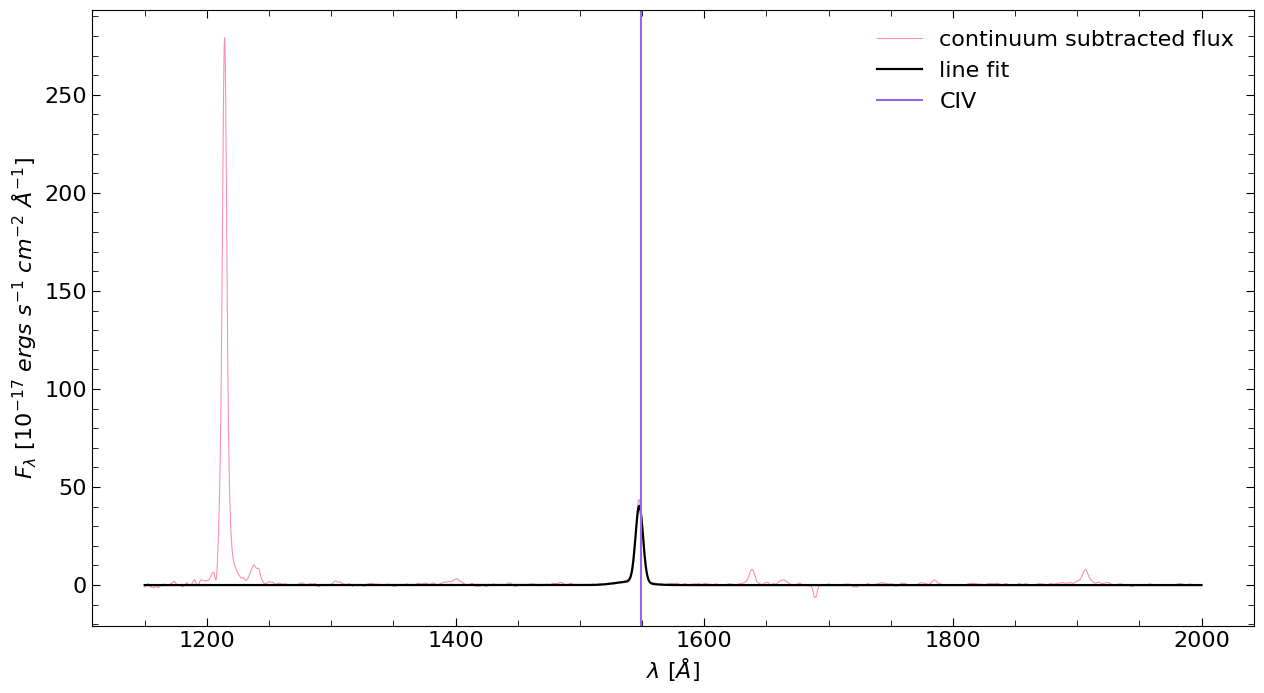


                SDSS: 130630.66+584734.7
                FWHM: 1402.286 vs 1132.847 (Hamann)
                REW: 432.914 vs 331.454 (Hamann)
                kt80: 0.362 vs 0.356 (Hamann)
    
---------------------------------------
---------------------------------------


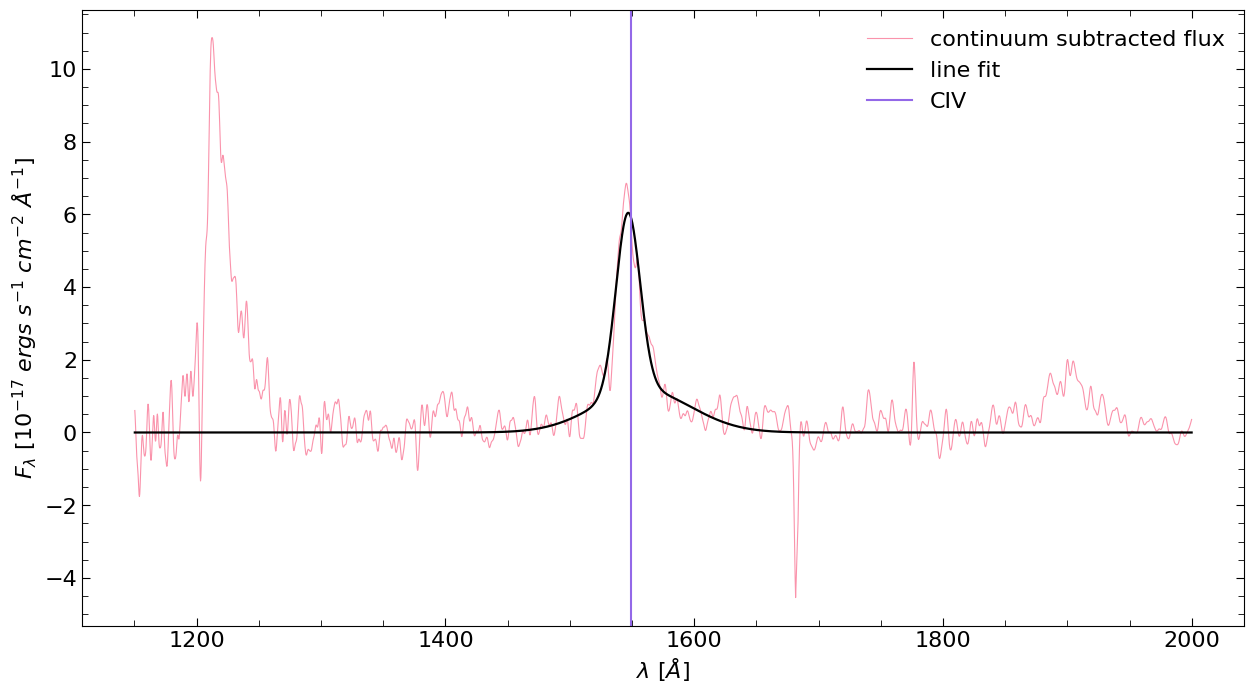


                SDSS: 082649.30+163945.2
                FWHM: 5076.564 vs 5633.199 (Hamann)
                REW: 211.89 vs 204.888 (Hamann)
                kt80: 0.3 vs 0.33 (Hamann)
    
---------------------------------------
---------------------------------------


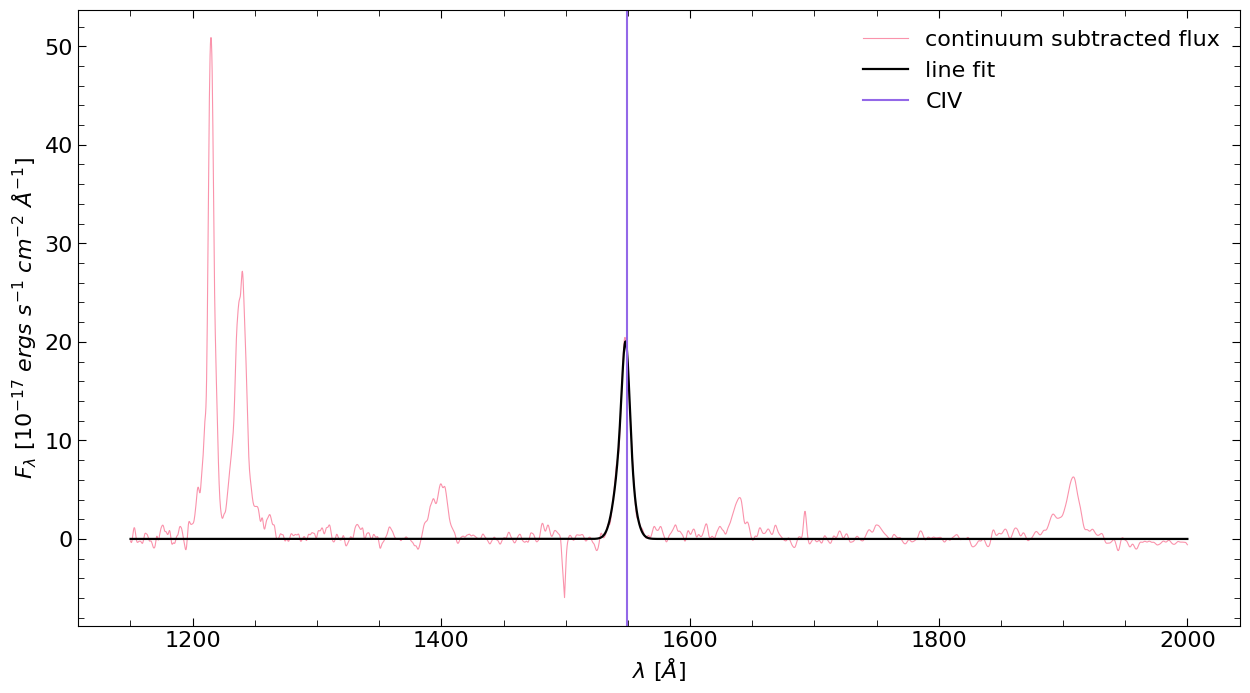


                SDSS: 164725.72+522948.6
                FWHM: 1914.925 vs 1905.323 (Hamann)
                REW: 192.049 vs 123.928 (Hamann)
                kt80: 0.297 vs 0.348 (Hamann)
    
---------------------------------------
---------------------------------------


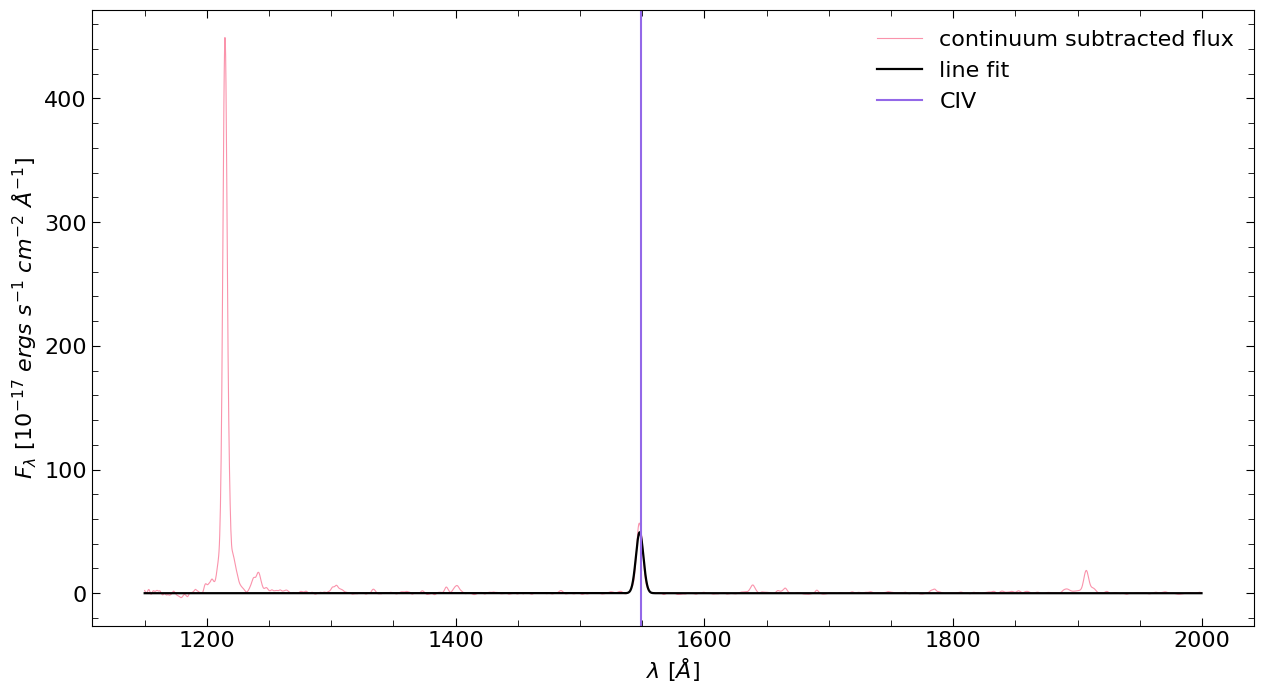


                SDSS: 092049.59+282200.9
                FWHM: 1367.708 vs 1048.141 (Hamann)
                REW: 202.415 vs 197.255 (Hamann)
                kt80: 0.372 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


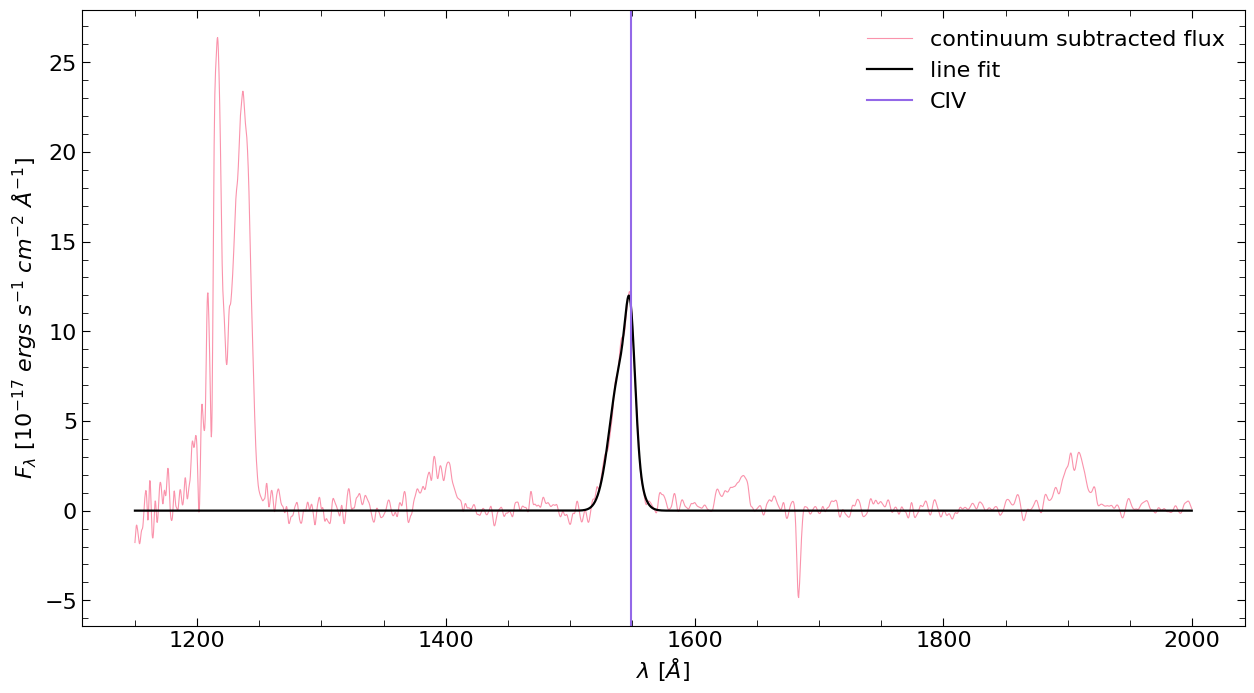


                SDSS: 113834.68+473250.0
                FWHM: 3643.738 vs 3296.45 (Hamann)
                REW: 212.729 vs 176.935 (Hamann)
                kt80: 0.277 vs 0.223 (Hamann)
    
---------------------------------------
---------------------------------------


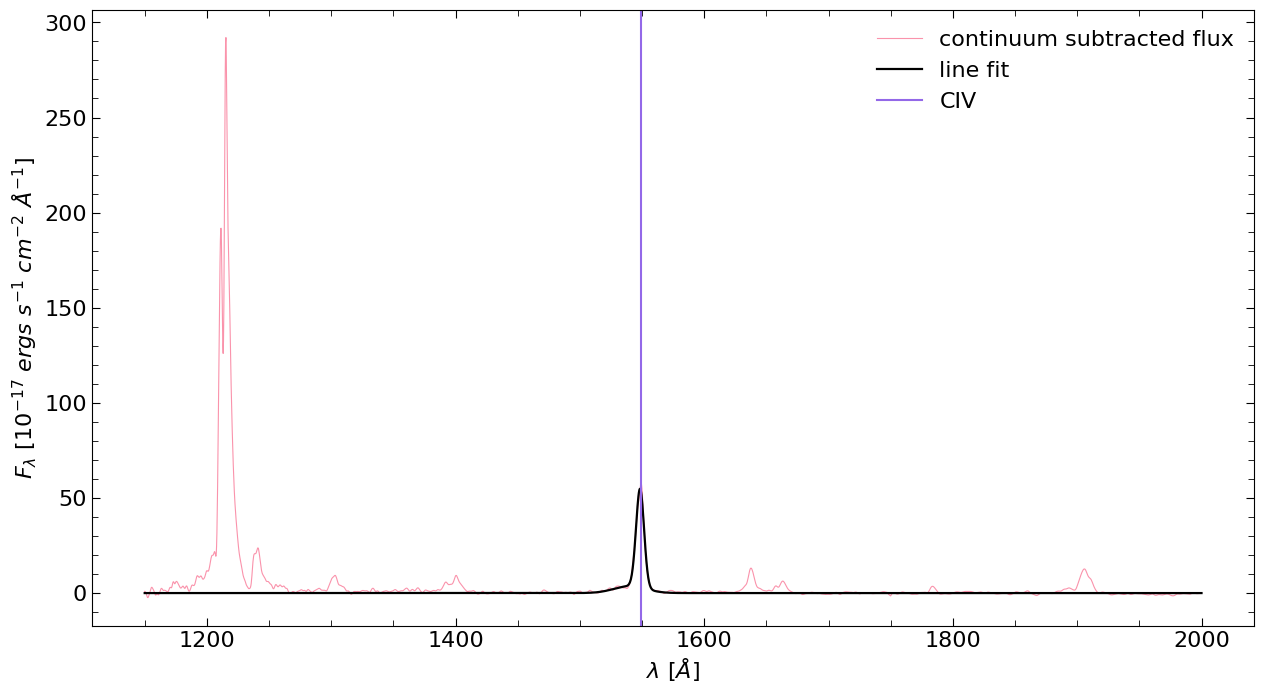


                SDSS: 111355.72+451452.6
                FWHM: 1521.254 vs 1243.226 (Hamann)
                REW: 261.986 vs 190.171 (Hamann)
                kt80: 0.358 vs 0.351 (Hamann)
    
---------------------------------------
---------------------------------------


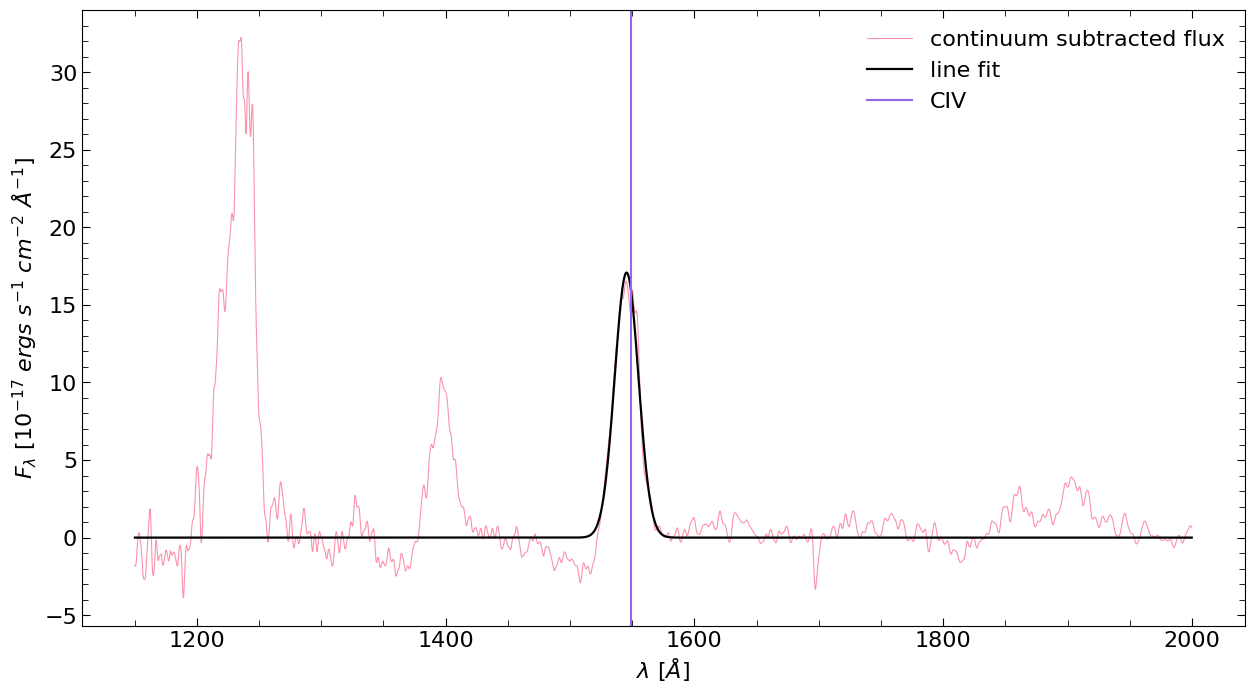


                SDSS: 103146.53+290324.1
                FWHM: 4348.866 vs 4363.774 (Hamann)
                REW: 119.081 vs 120.767 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


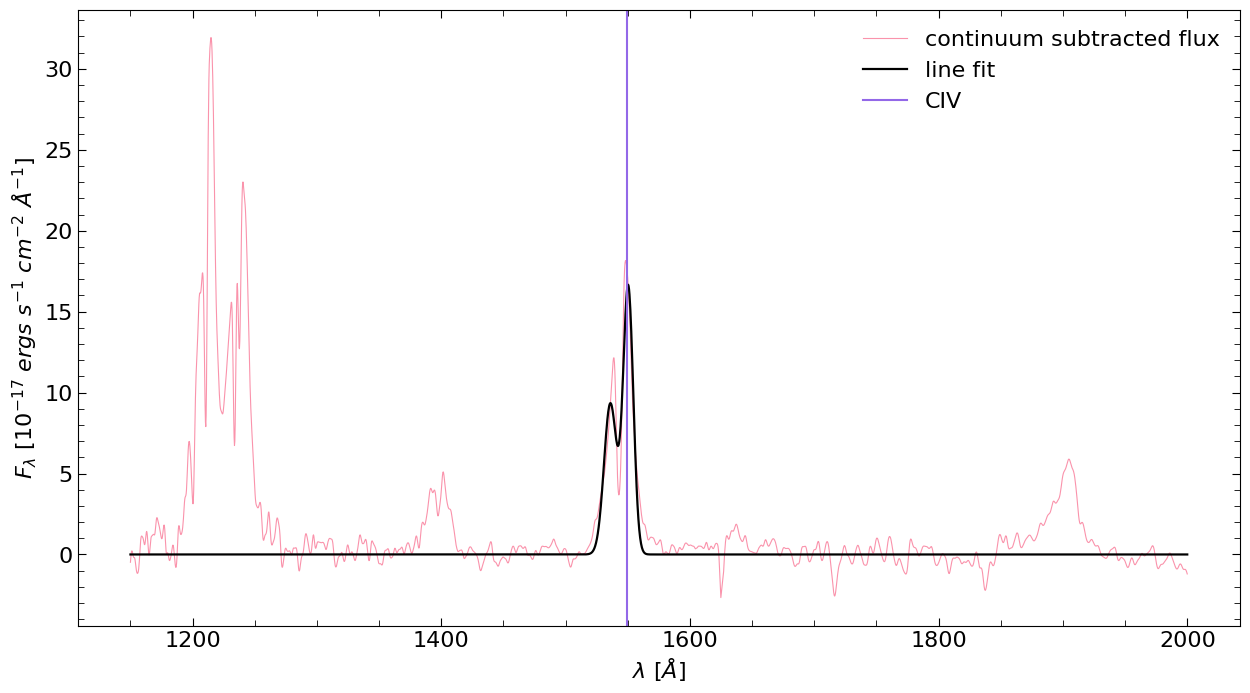


                SDSS: 083200.20+161500.3
                FWHM: 4163.976 vs 3082.076 (Hamann)
                REW: 261.457 vs 300.478 (Hamann)
                kt80: 0.197 vs 0.329 (Hamann)
    
---------------------------------------
---------------------------------------


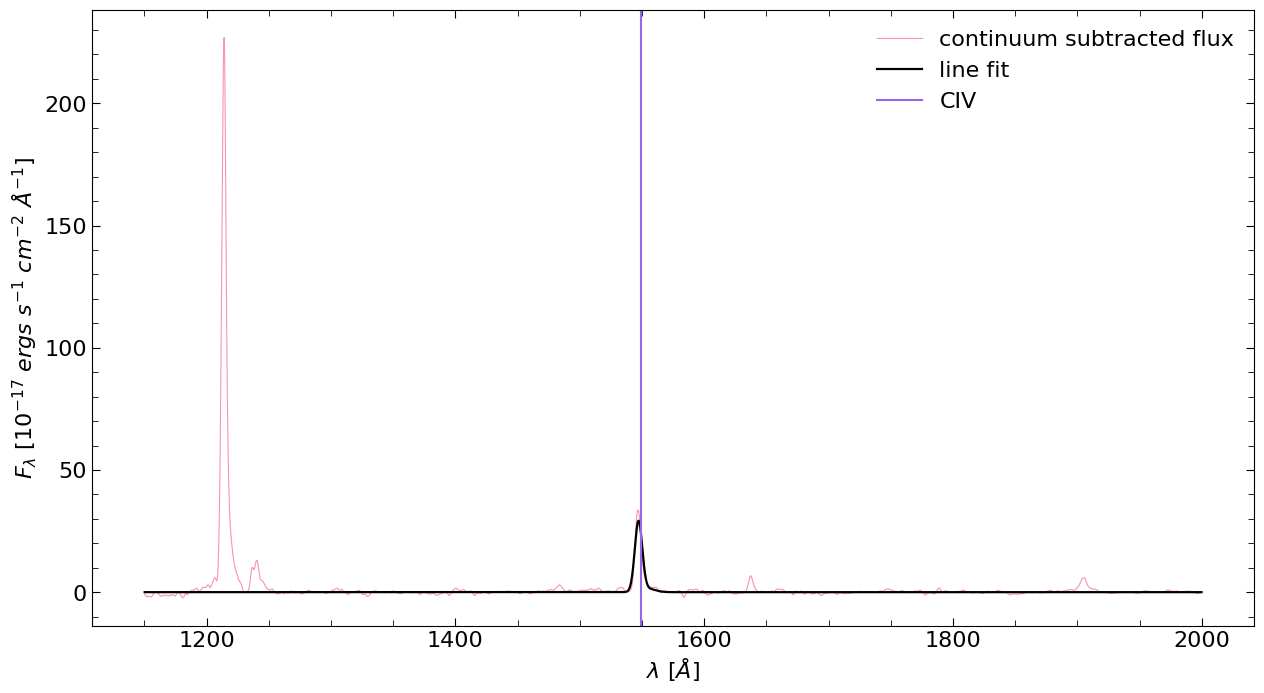


                SDSS: 111346.10+185451.9
                FWHM: 1395.799 vs 985.843 (Hamann)
                REW: 143.575 vs 126.613 (Hamann)
                kt80: 0.364 vs 0.351 (Hamann)
    
---------------------------------------
---------------------------------------


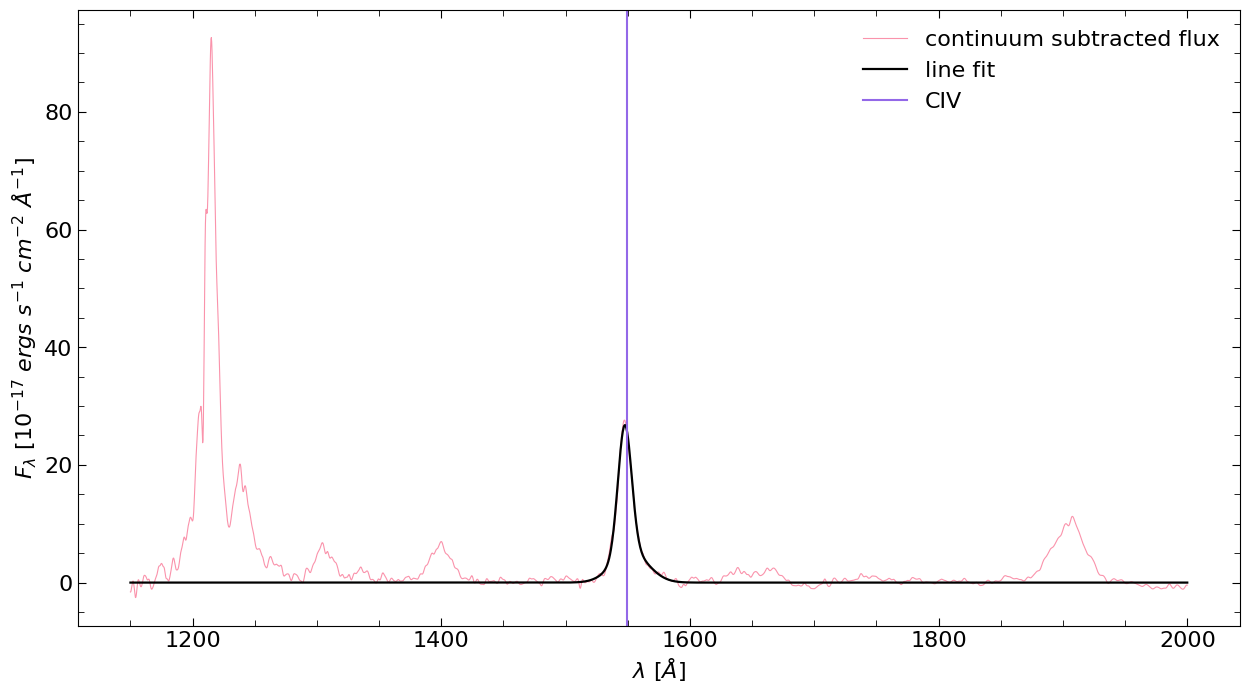


                SDSS: 135557.60+144733.1
                FWHM: 2822.006 vs 2958.323 (Hamann)
                REW: 128.35 vs 117.885 (Hamann)
                kt80: 0.327 vs 0.336 (Hamann)
    
---------------------------------------
---------------------------------------


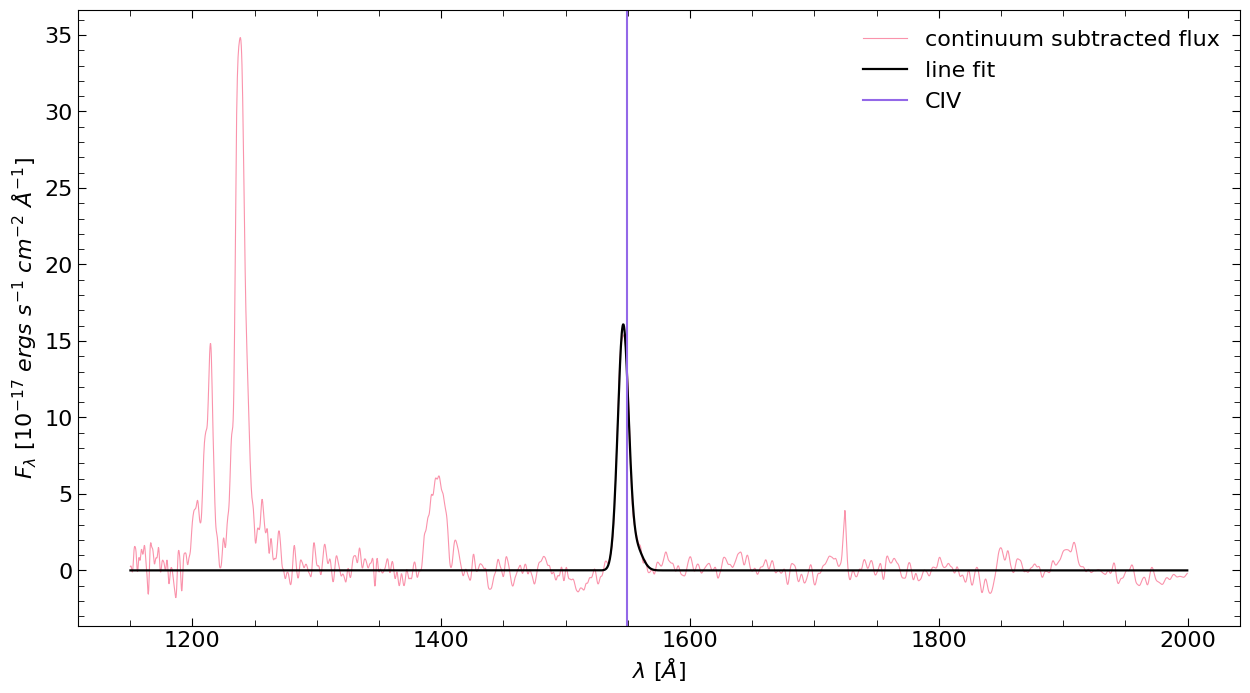


                SDSS: 101533.65+631752.6
                FWHM: 2035.561 vs 2011.595 (Hamann)
                REW: 132.347 vs 129.997 (Hamann)
                kt80: 0.354 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


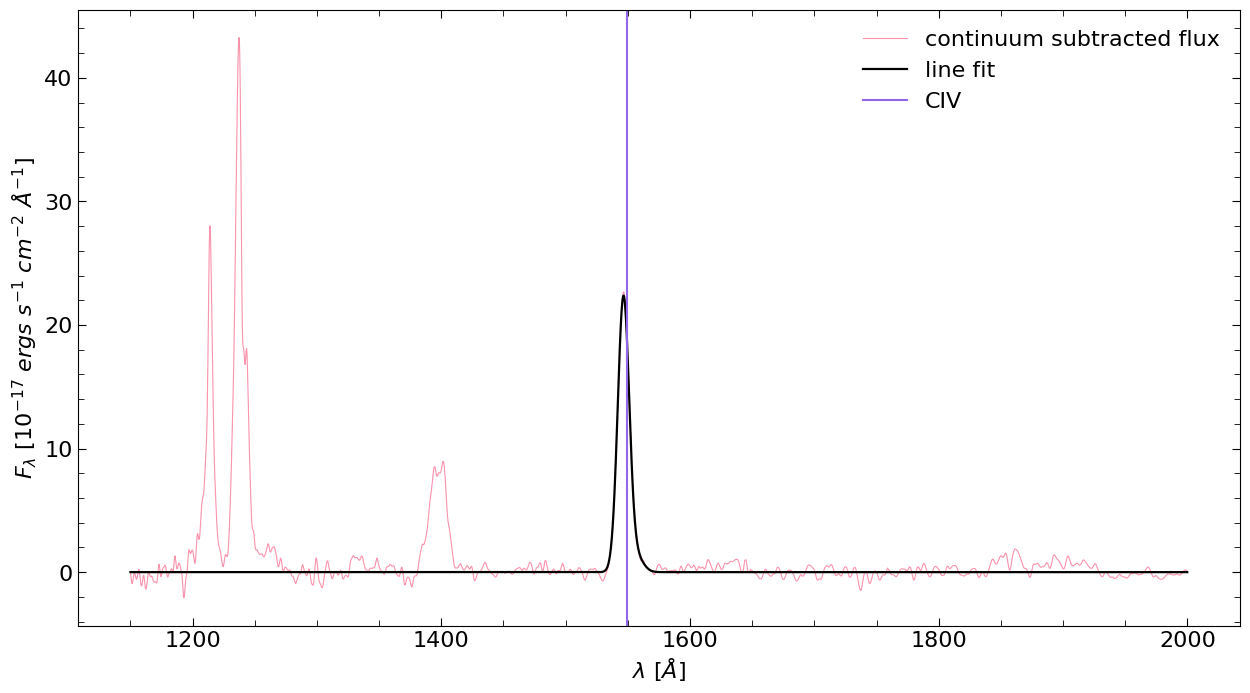


                SDSS: 143159.76+173032.6
                FWHM: 2133.41 vs 2084.241 (Hamann)
                REW: 228.334 vs 176.894 (Hamann)
                kt80: 0.363 vs 0.368 (Hamann)
    
---------------------------------------
---------------------------------------


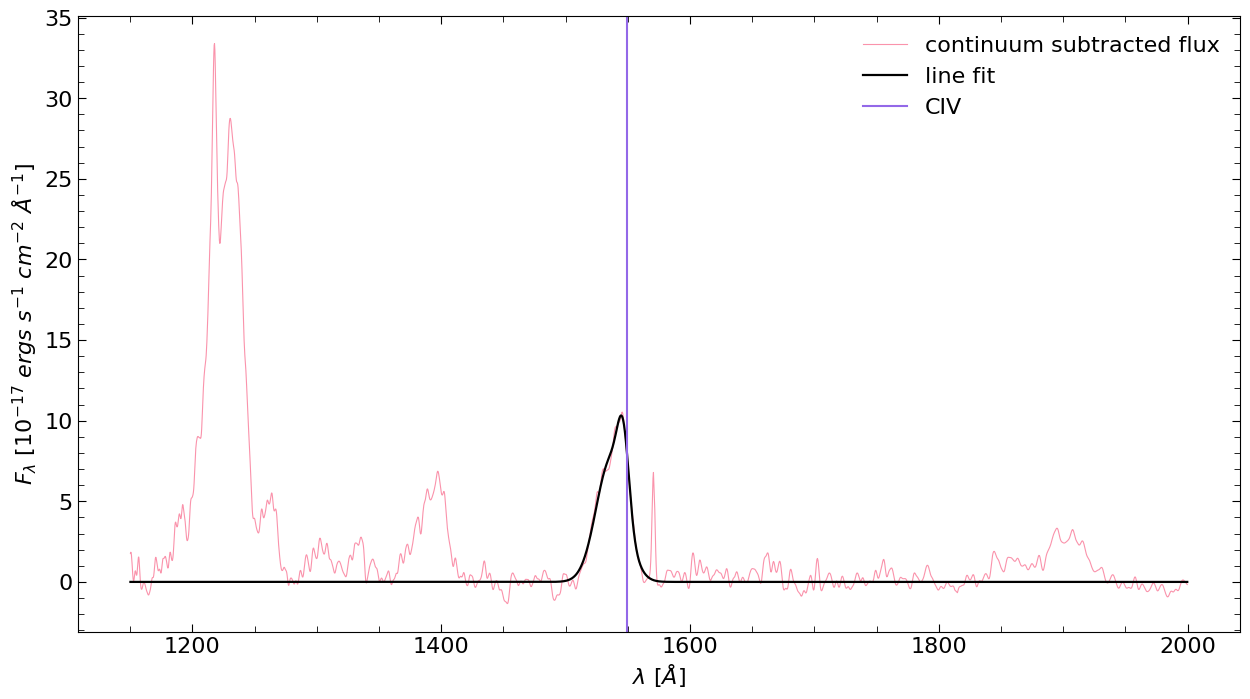


                SDSS: 104754.58+621300.5
                FWHM: 5072.075 vs 5080.835 (Hamann)
                REW: 128.038 vs 104.956 (Hamann)
                kt80: 0.296 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


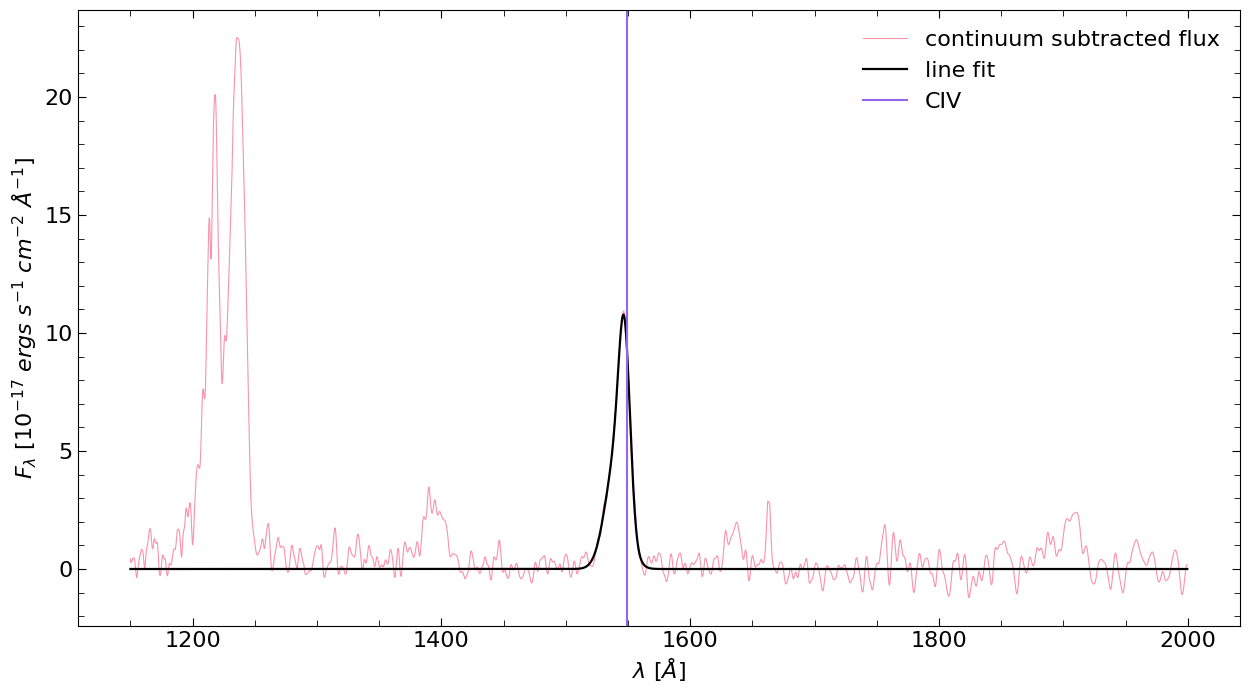


                SDSS: 005233.24-055653.5
                FWHM: 2786.748 vs 2450.95 (Hamann)
                REW: 264.79 vs 188.145 (Hamann)
                kt80: 0.288 vs 0.274 (Hamann)
    
---------------------------------------
---------------------------------------


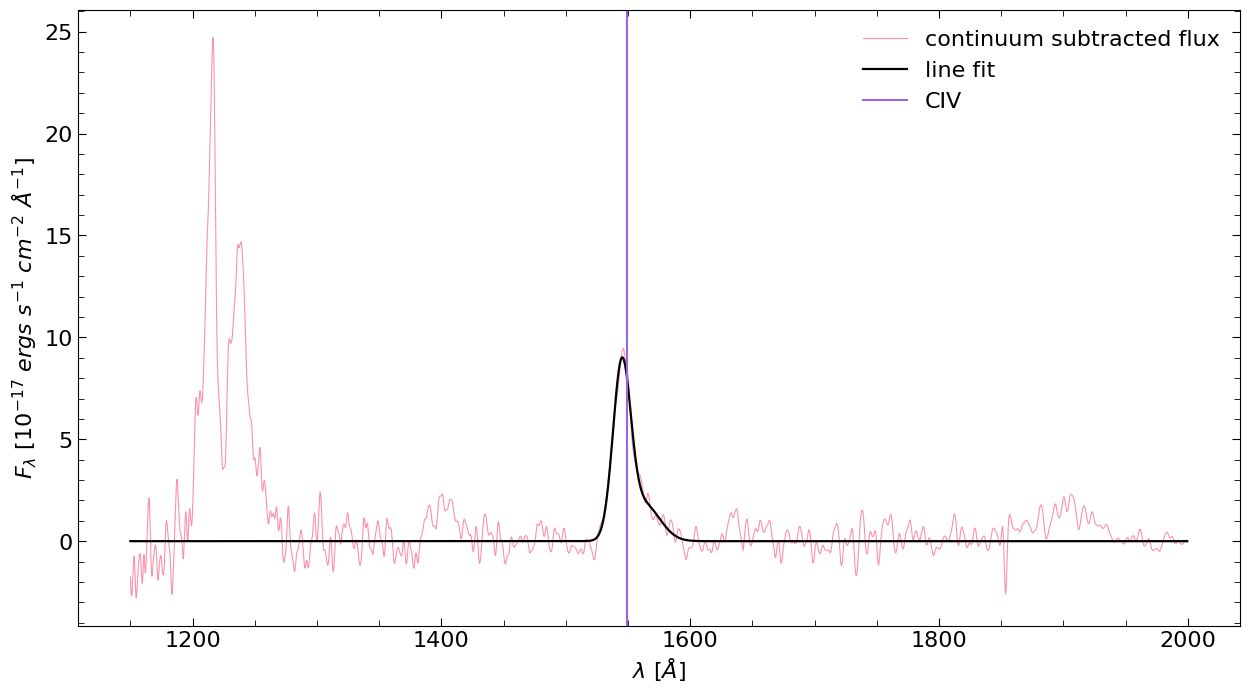


                SDSS: 124738.40+501517.7
                FWHM: 3559.376 vs 3268.048 (Hamann)
                REW: 102.534 vs 134.848 (Hamann)
                kt80: 0.296 vs 0.293 (Hamann)
    
---------------------------------------
---------------------------------------


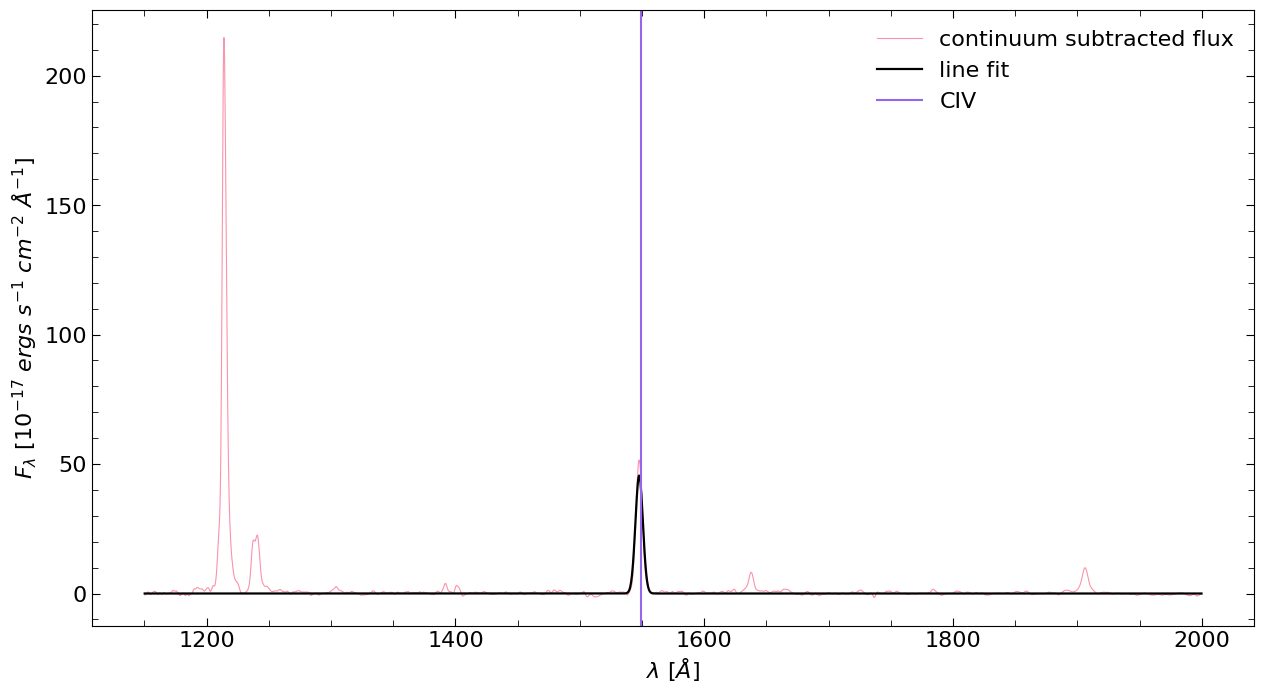


                SDSS: 220337.79+121955.3
                FWHM: 1367.242 vs 1070.213 (Hamann)
                REW: 292.237 vs 266.278 (Hamann)
                kt80: 0.372 vs 0.37 (Hamann)
    
---------------------------------------
---------------------------------------


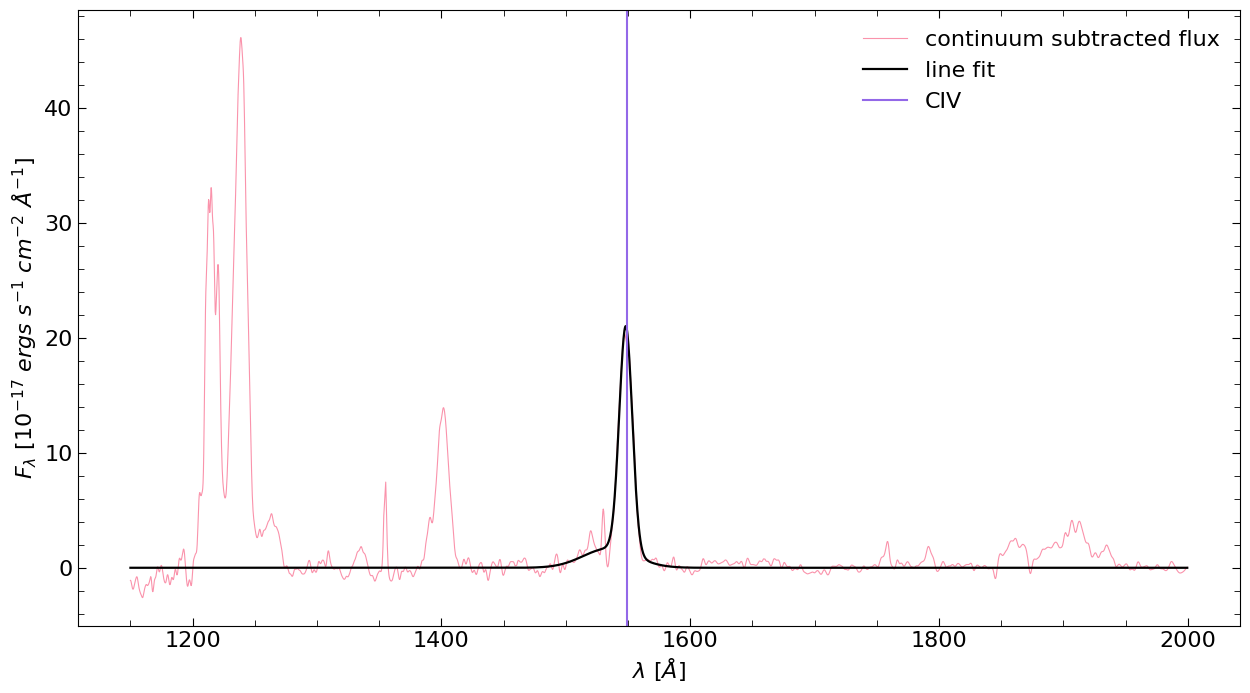


                SDSS: 125449.50+210448.4
                FWHM: 2495.529 vs 2482.204 (Hamann)
                REW: 139.315 vs 140.744 (Hamann)
                kt80: 0.354 vs 0.356 (Hamann)
    
---------------------------------------
---------------------------------------


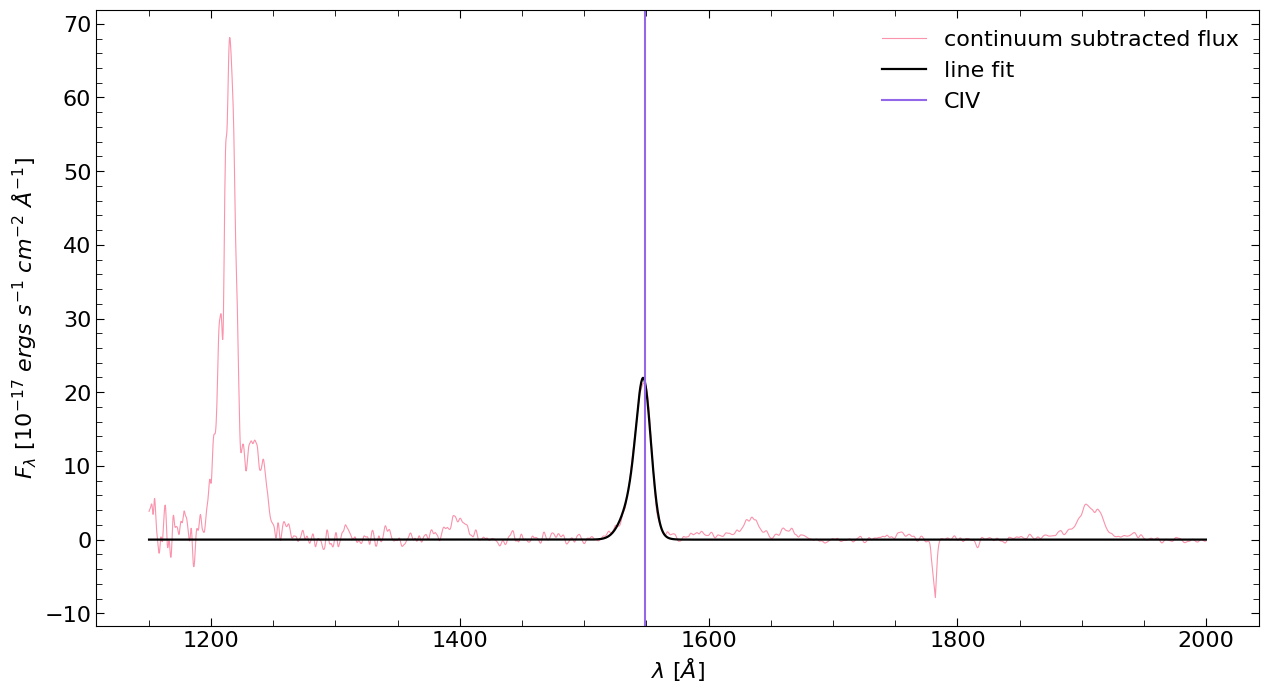


                SDSS: 111729.56+462331.2
                FWHM: 3039.75 vs 3052.827 (Hamann)
                REW: 448.667 vs 395.287 (Hamann)
                kt80: 0.328 vs 0.348 (Hamann)
    
---------------------------------------
---------------------------------------


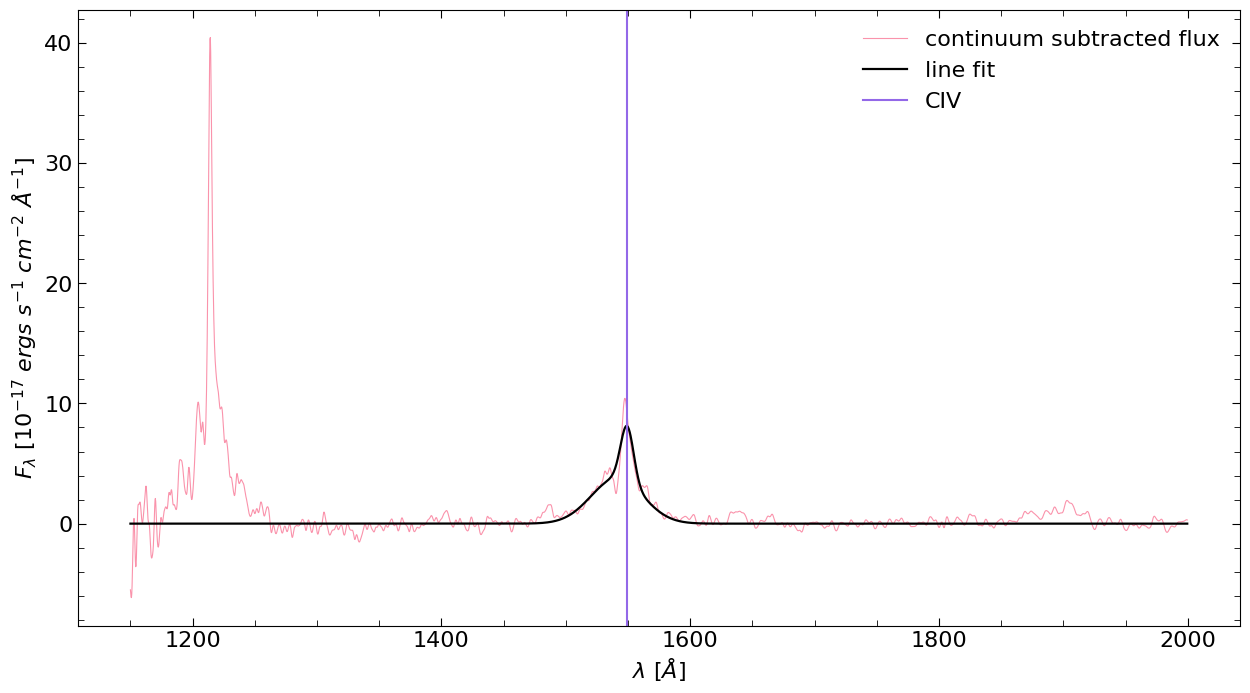


                SDSS: 082536.31+200040.3
                FWHM: 3901.728 vs 3265.175 (Hamann)
                REW: 188.076 vs 210.805 (Hamann)
                kt80: 0.175 vs 0.171 (Hamann)
    
---------------------------------------
---------------------------------------


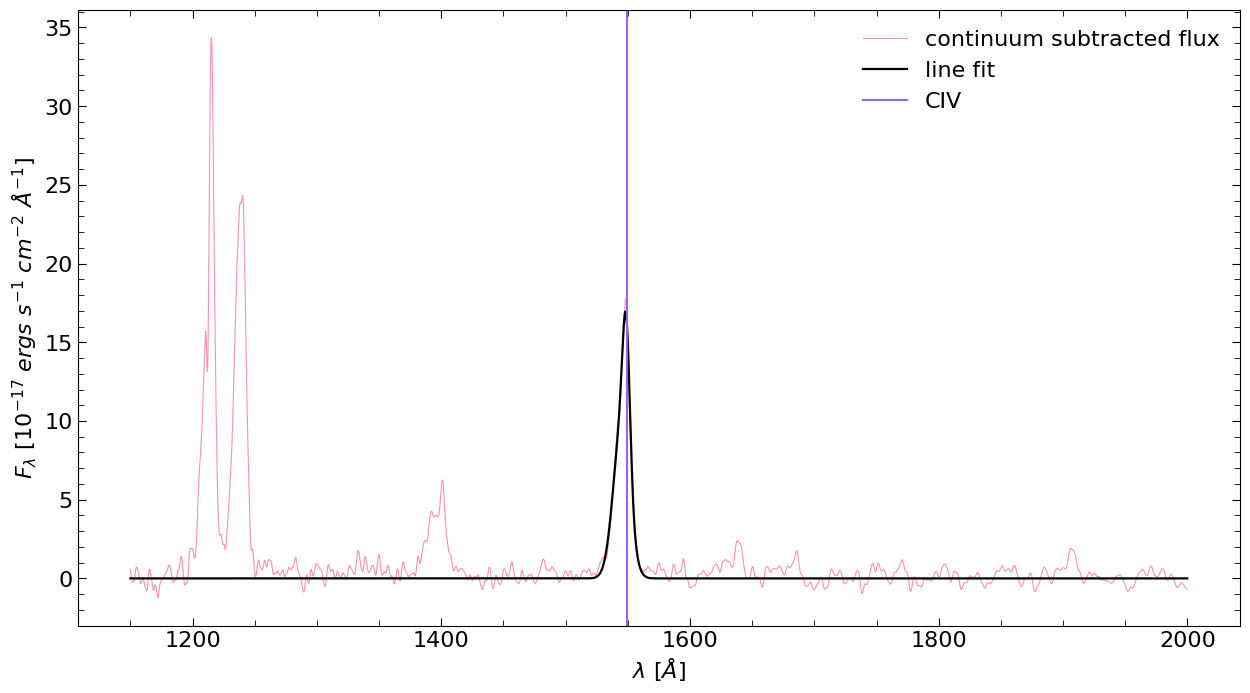


                SDSS: 134026.99+083427.2
                FWHM: 2200.813 vs 2075.846 (Hamann)
                REW: 538.049 vs 357.973 (Hamann)
                kt80: 0.279 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


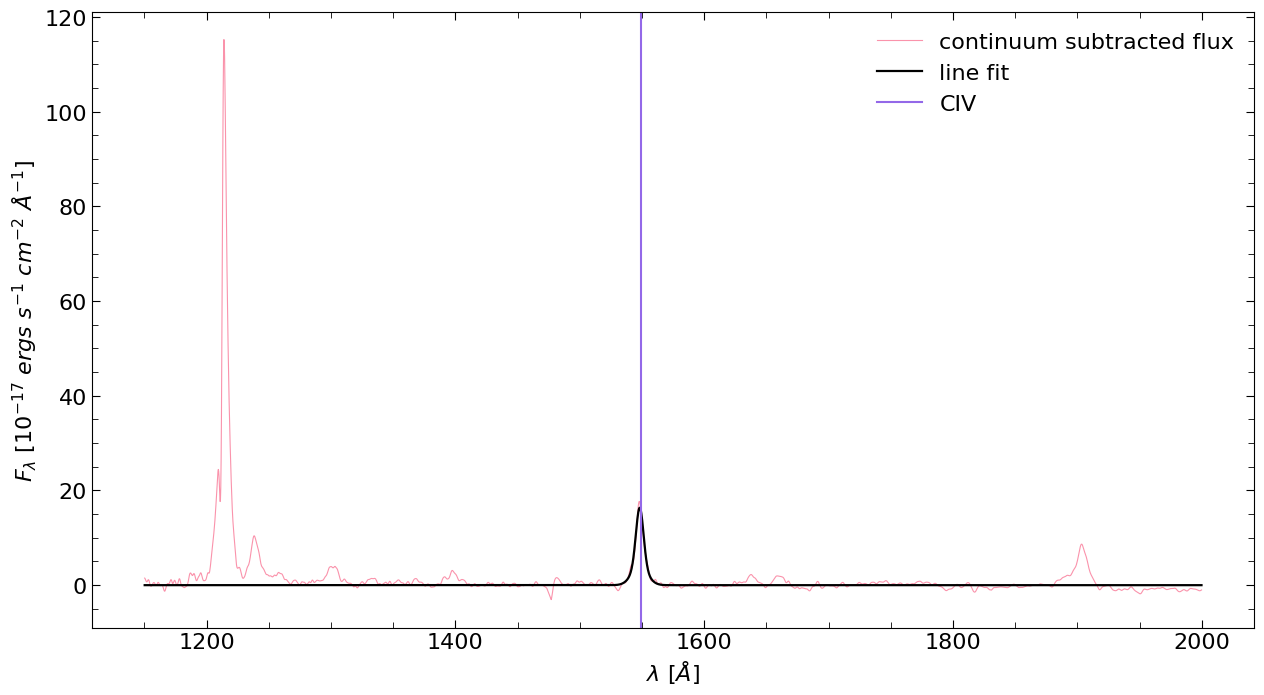


                SDSS: 122000.68+064045.3
                FWHM: 1567.731 vs 1047.131 (Hamann)
                REW: 149.348 vs 112.877 (Hamann)
                kt80: 0.336 vs 0.151 (Hamann)
    
---------------------------------------
---------------------------------------


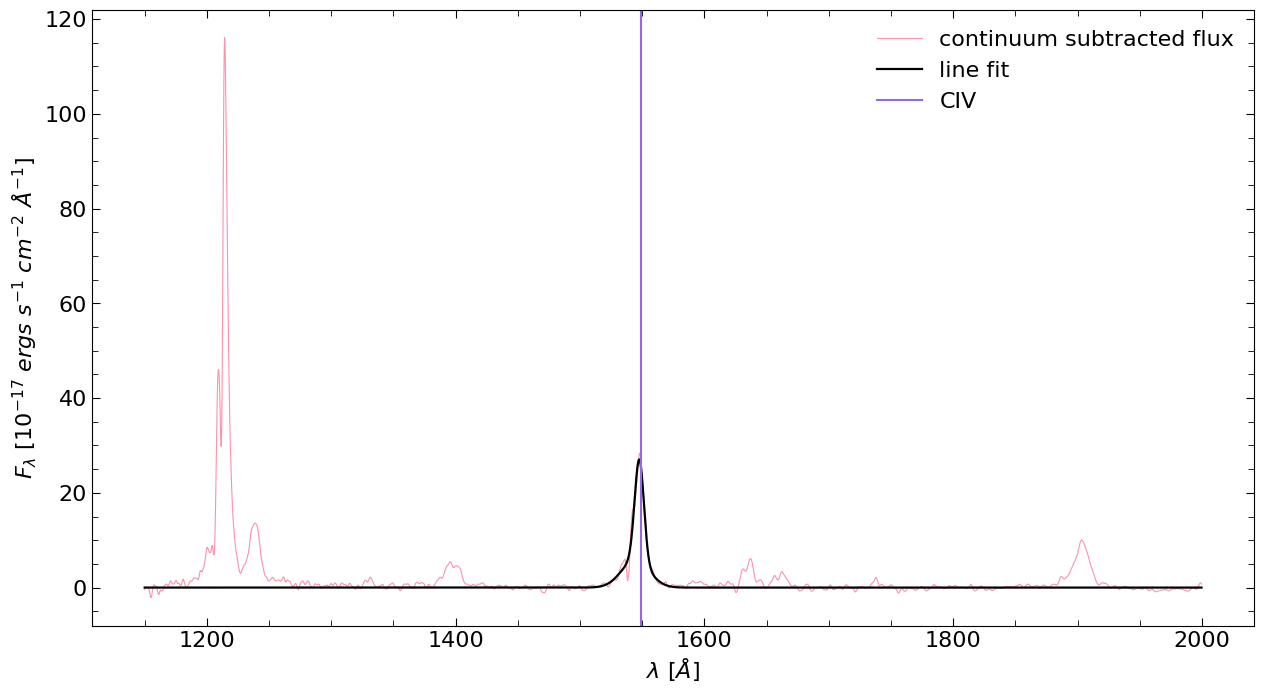


                SDSS: 125811.25+212359.6
                FWHM: 1950.728 vs 1598.848 (Hamann)
                REW: 207.63 vs 158.312 (Hamann)
                kt80: 0.307 vs 0.183 (Hamann)
    
---------------------------------------
---------------------------------------


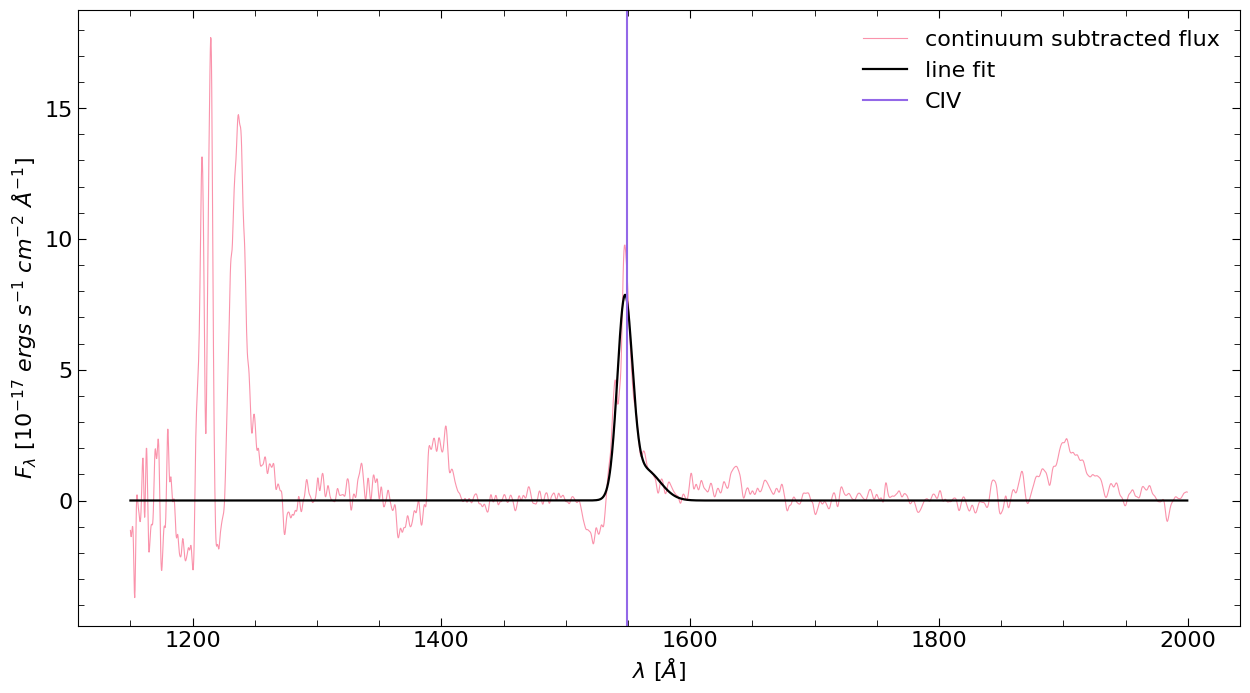


                SDSS: 093506.96-024137.7
                FWHM: 2903.864 vs 2404.04 (Hamann)
                REW: 122.511 vs 119.496 (Hamann)
                kt80: 0.334 vs 0.249 (Hamann)
    
---------------------------------------
---------------------------------------


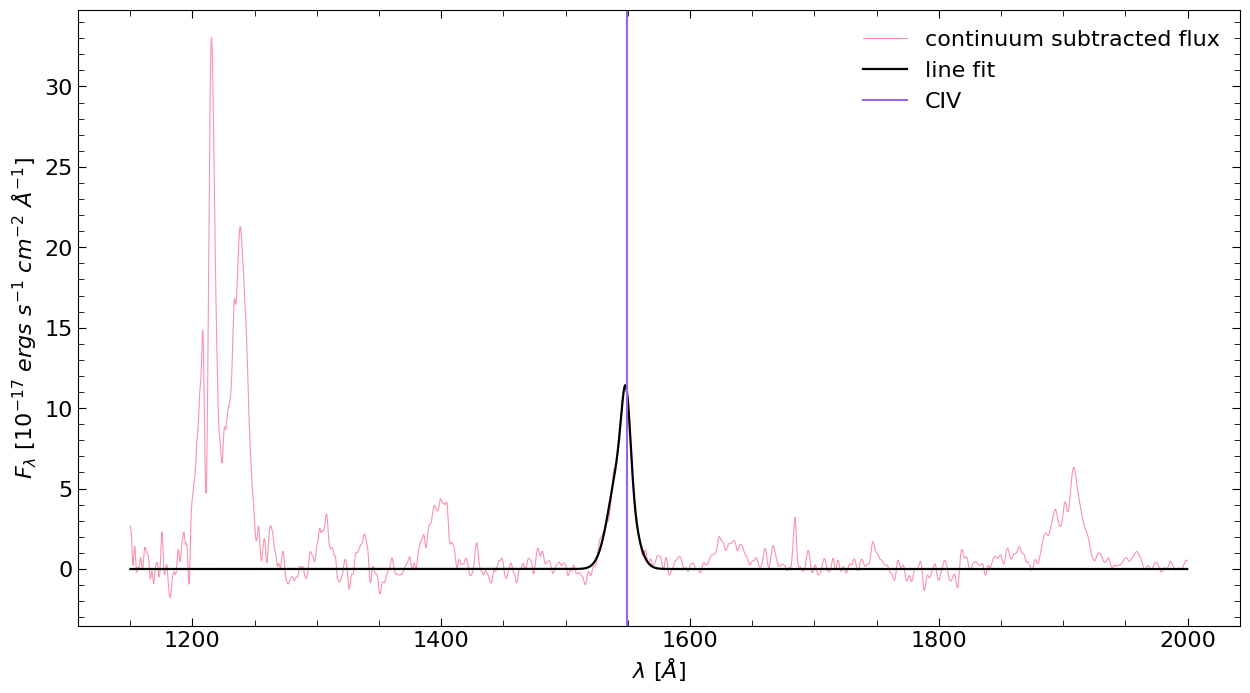


                SDSS: 080547.66+454159.0
                FWHM: 2898.644 vs 2667.071 (Hamann)
                REW: 156.975 vs 108.69 (Hamann)
                kt80: 0.258 vs 0.211 (Hamann)
    
---------------------------------------
---------------------------------------


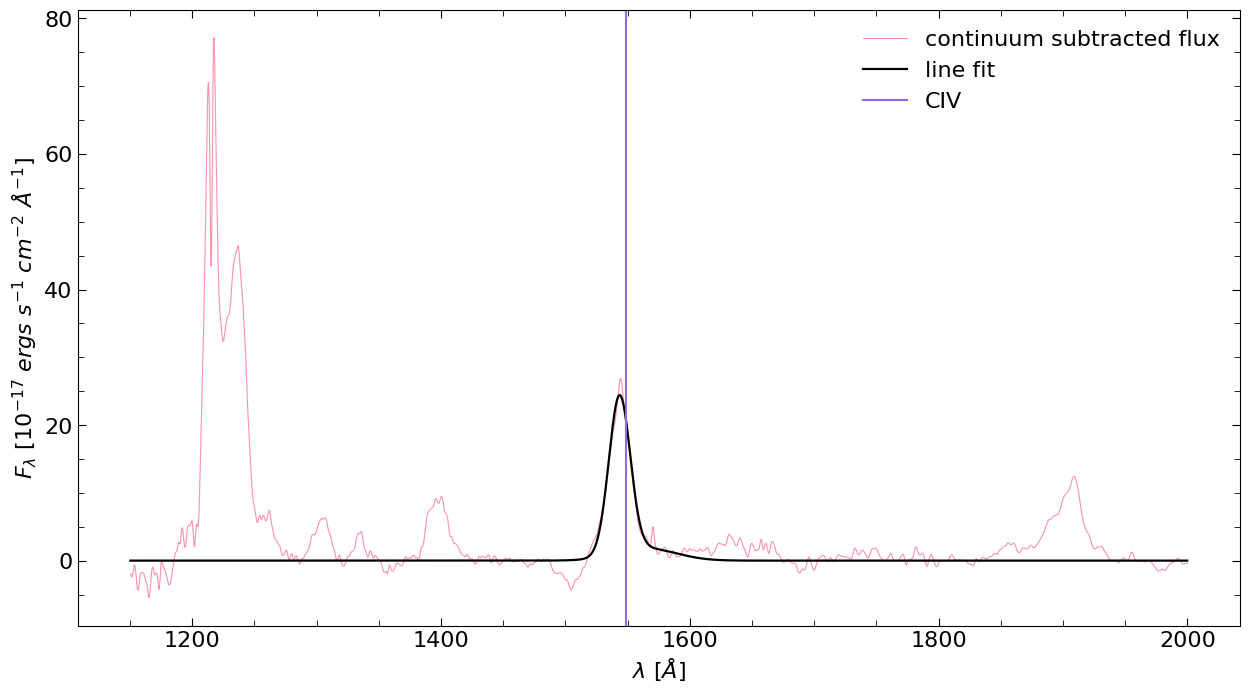


                SDSS: 004713.21+264024.7
                FWHM: 4044.062 vs 3685.428 (Hamann)
                REW: 121.098 vs 100.506 (Hamann)
                kt80: 0.358 vs 0.325 (Hamann)
    
---------------------------------------
---------------------------------------


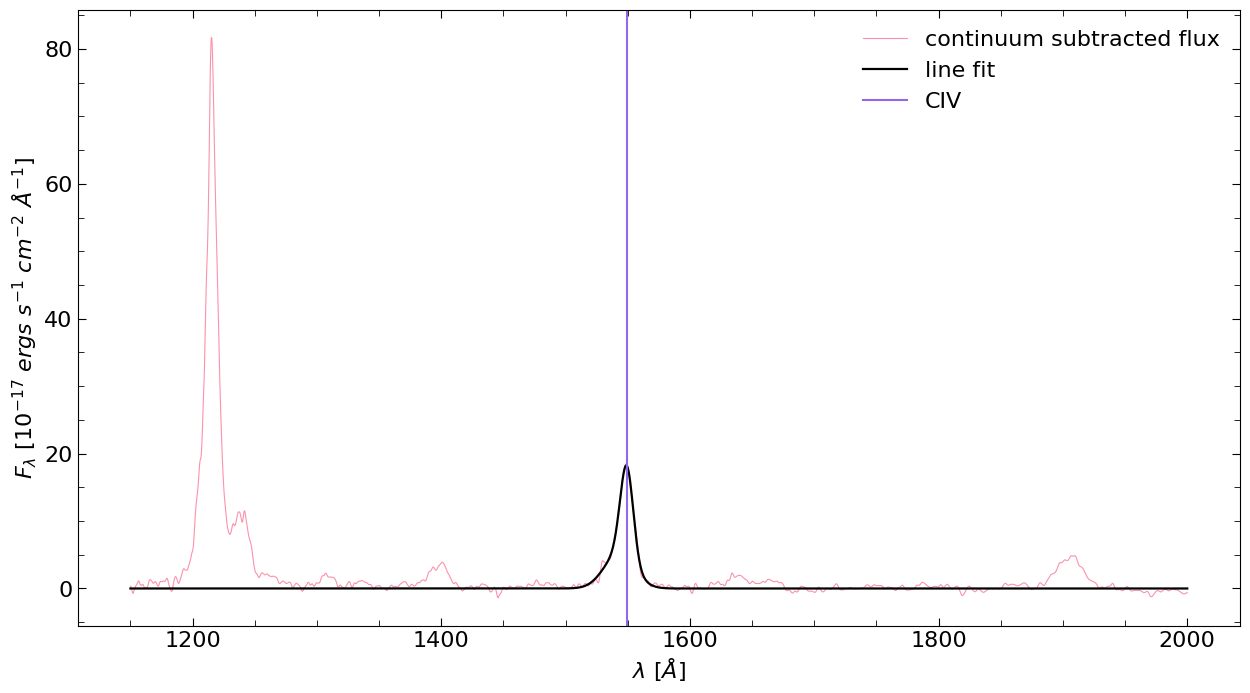


                SDSS: 091508.45+561316.0
                FWHM: 2847.369 vs 2867.477 (Hamann)
                REW: 360.077 vs 225.875 (Hamann)
                kt80: 0.295 vs 0.355 (Hamann)
    
---------------------------------------
---------------------------------------


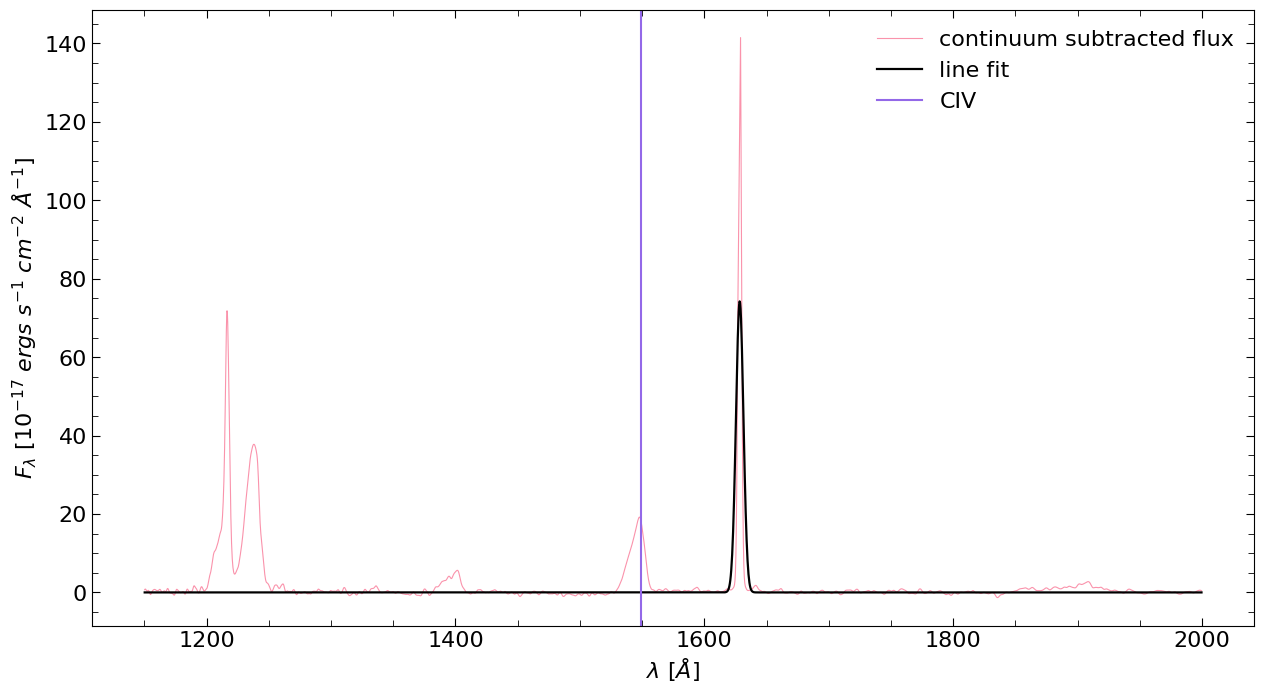


                SDSS: 121704.70+023417.1
                FWHM: 1367.747 vs 2603.968 (Hamann)
                REW: 485.0 vs 180.897 (Hamann)
                kt80: 0.371 vs 0.369 (Hamann)
    
---------------------------------------
---------------------------------------


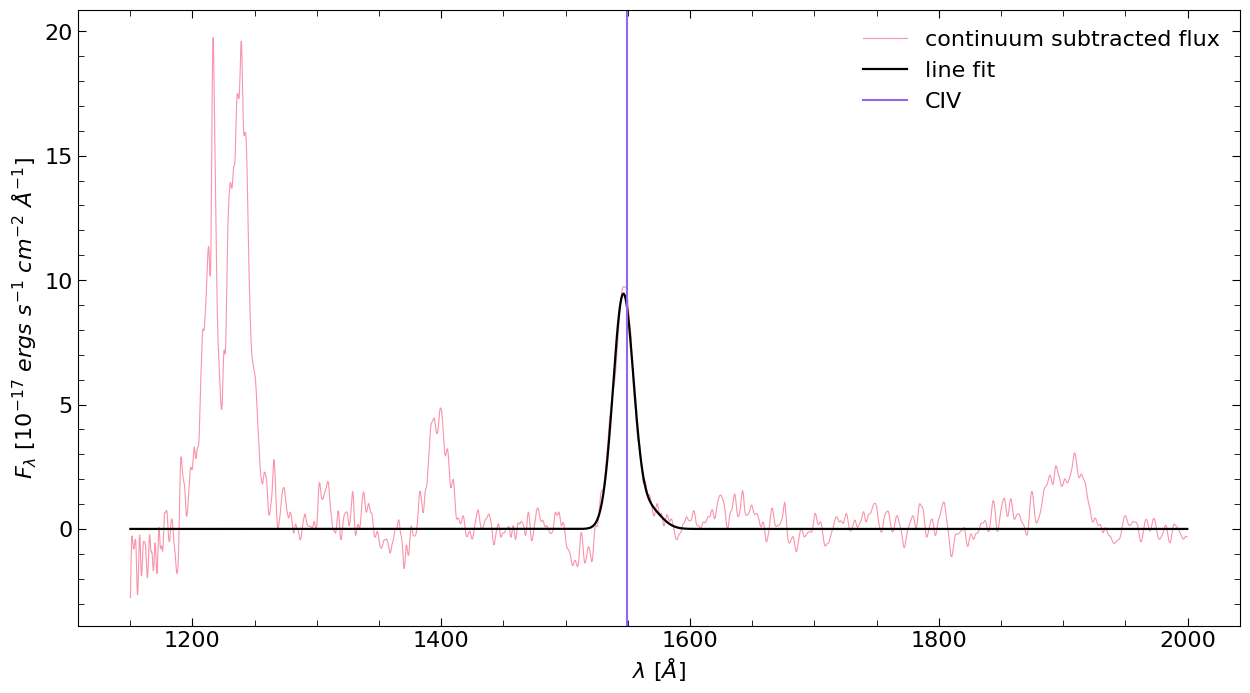


                SDSS: 171420.38+414815.7
                FWHM: 3860.172 vs 3815.54 (Hamann)
                REW: 156.126 vs 129.999 (Hamann)
                kt80: 0.355 vs 0.359 (Hamann)
    
---------------------------------------
---------------------------------------


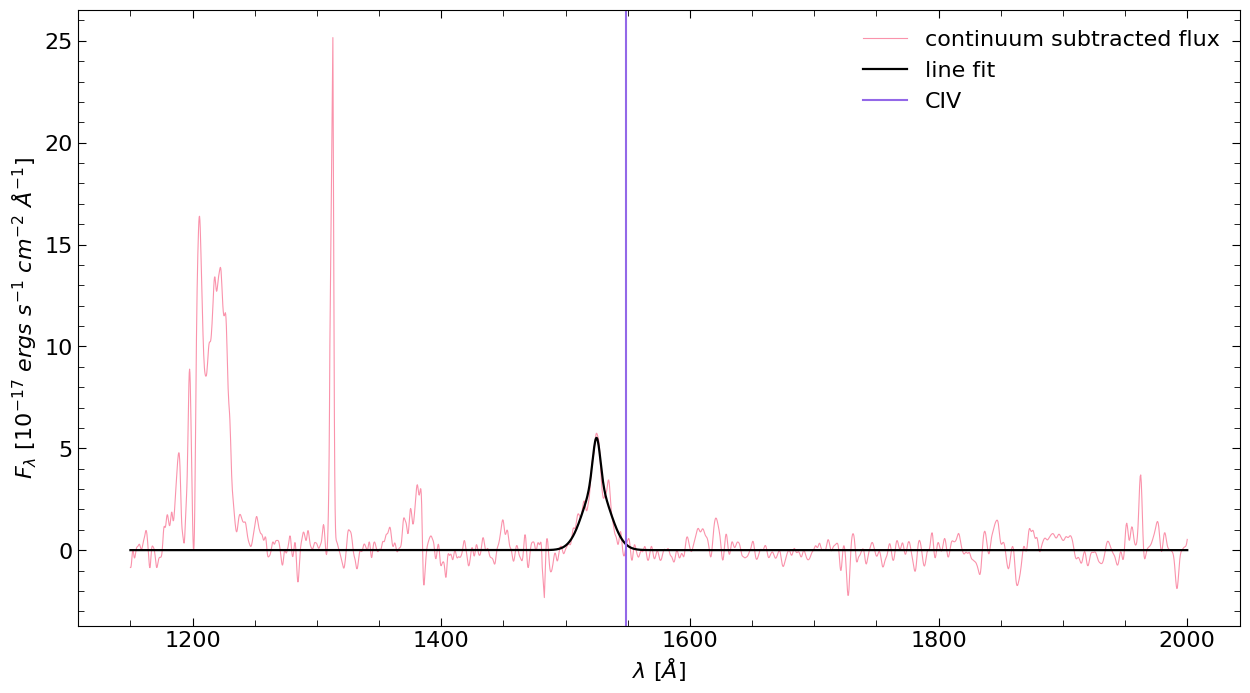


                SDSS: 154243.87+102001.5
                FWHM: 2699.971 vs 3901.128 (Hamann)
                REW: 117.021 vs 114.106 (Hamann)
                kt80: 0.199 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


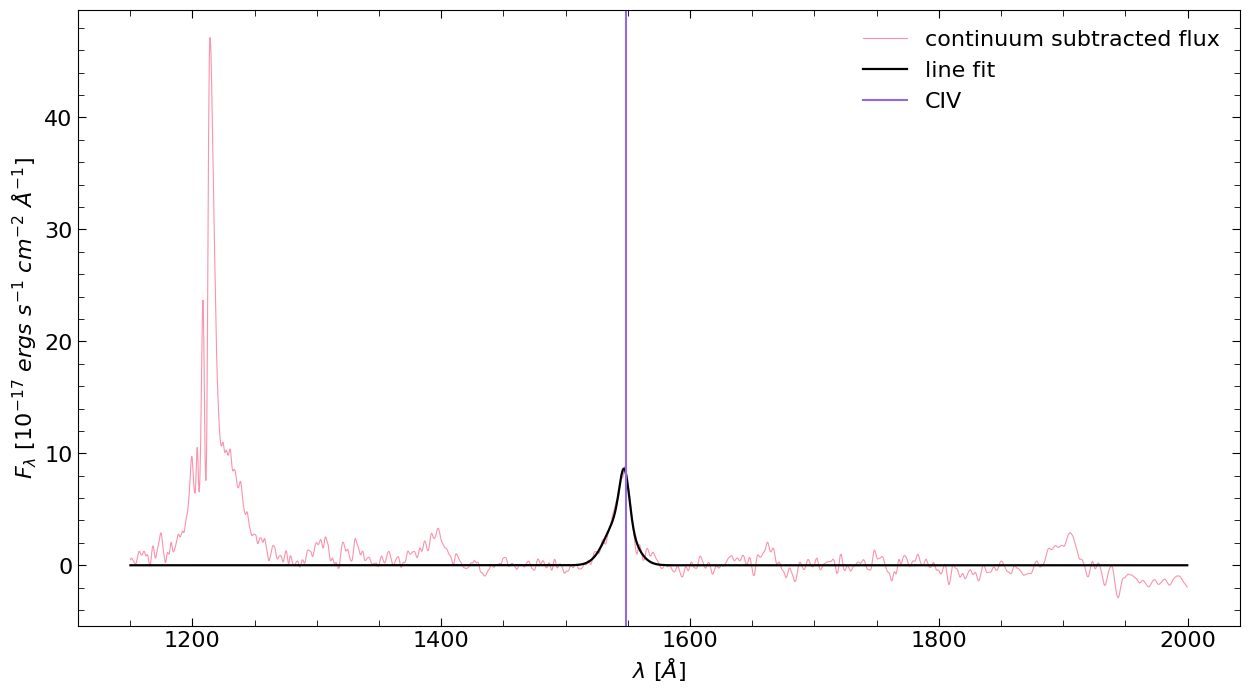


                SDSS: 153108.10+213725.1
                FWHM: 2777.695 vs 2766.583 (Hamann)
                REW: 157.202 vs 212.521 (Hamann)
                kt80: 0.241 vs 0.26 (Hamann)
    
---------------------------------------
---------------------------------------


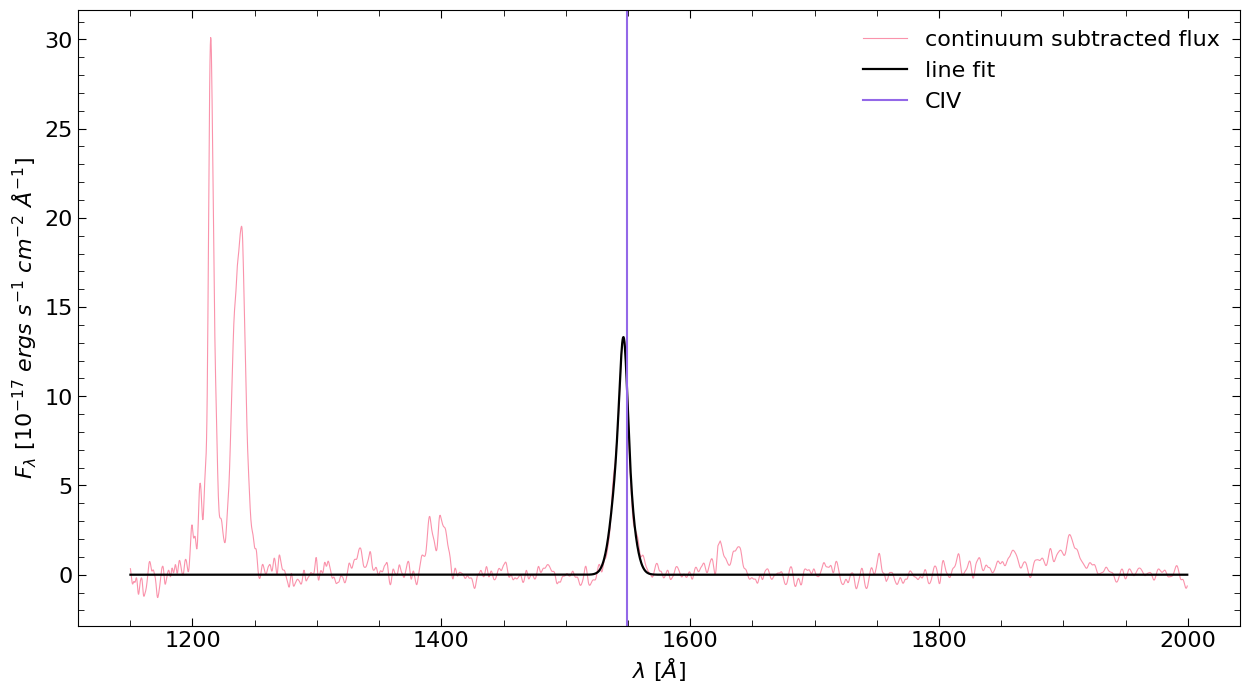


                SDSS: 091303.90+234435.2
                FWHM: 2144.881 vs 2190.262 (Hamann)
                REW: 178.658 vs 144.743 (Hamann)
                kt80: 0.28 vs 0.34 (Hamann)
    
---------------------------------------
---------------------------------------


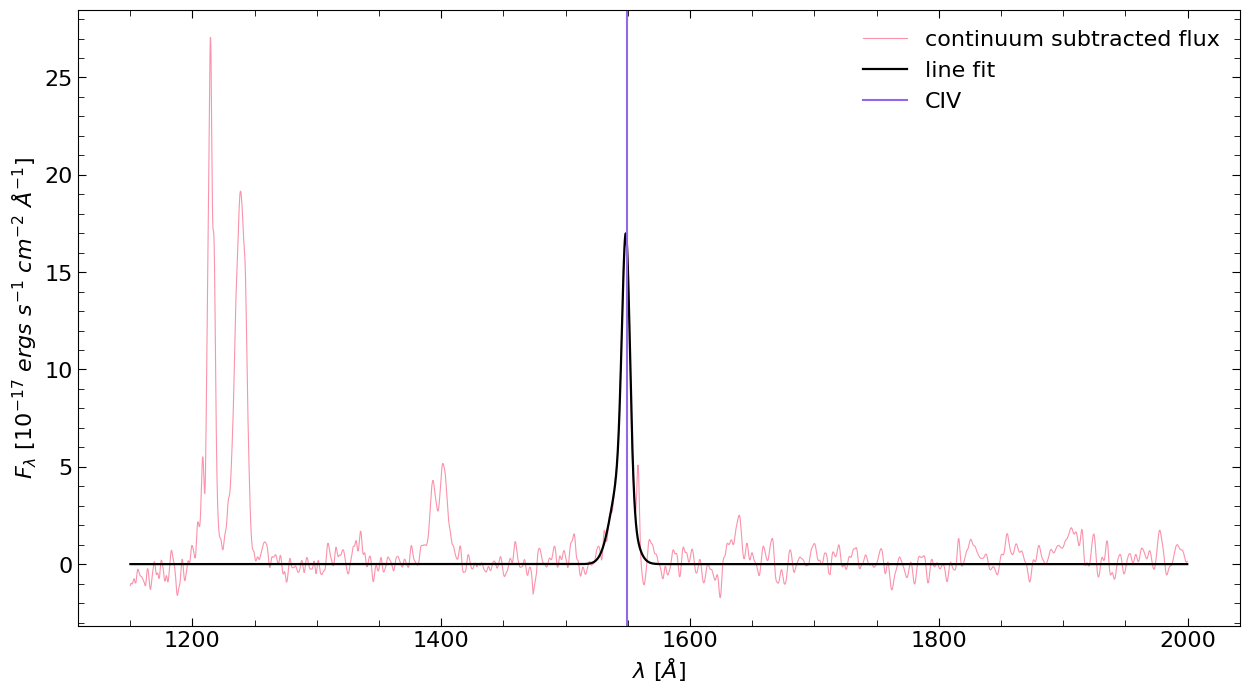


                SDSS: 233636.99+065231.0
                FWHM: 1735.463 vs 1483.559 (Hamann)
                REW: 202.69 vs 128.271 (Hamann)
                kt80: 0.287 vs 0.258 (Hamann)
    
---------------------------------------
---------------------------------------


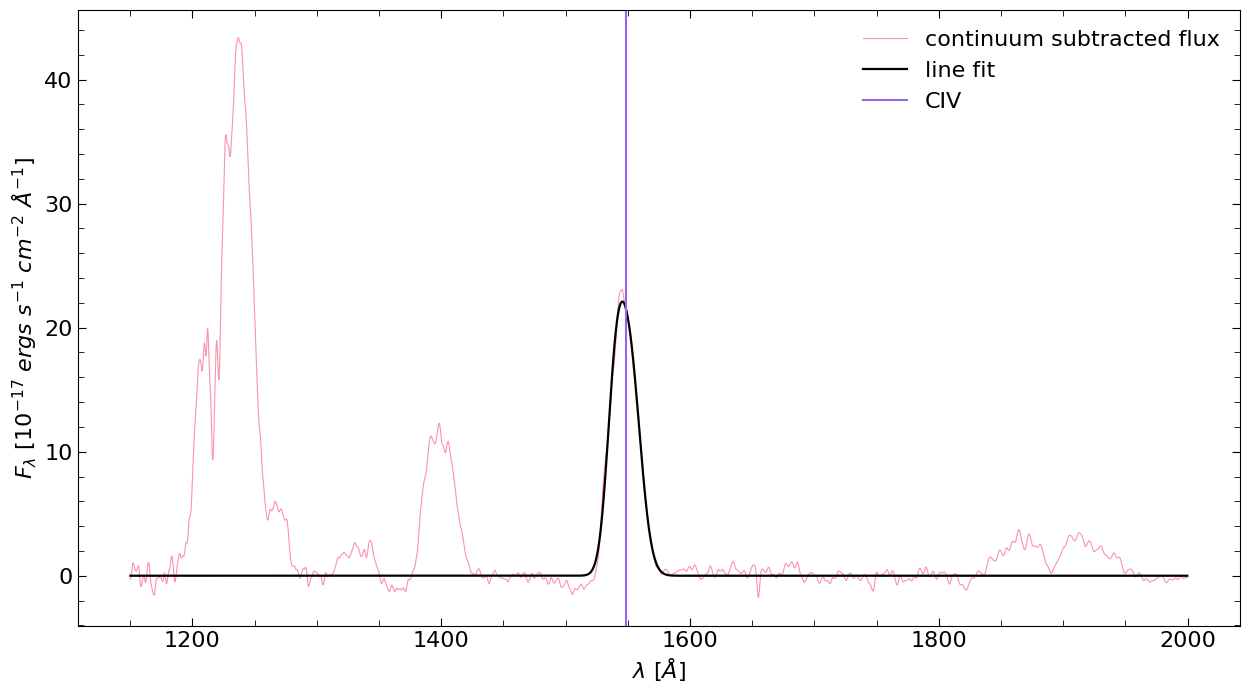


                SDSS: 123241.73+091209.3
                FWHM: 5006.435 vs 4786.658 (Hamann)
                REW: 221.235 vs 224.515 (Hamann)
                kt80: 0.418 vs 0.369 (Hamann)
    
---------------------------------------
---------------------------------------


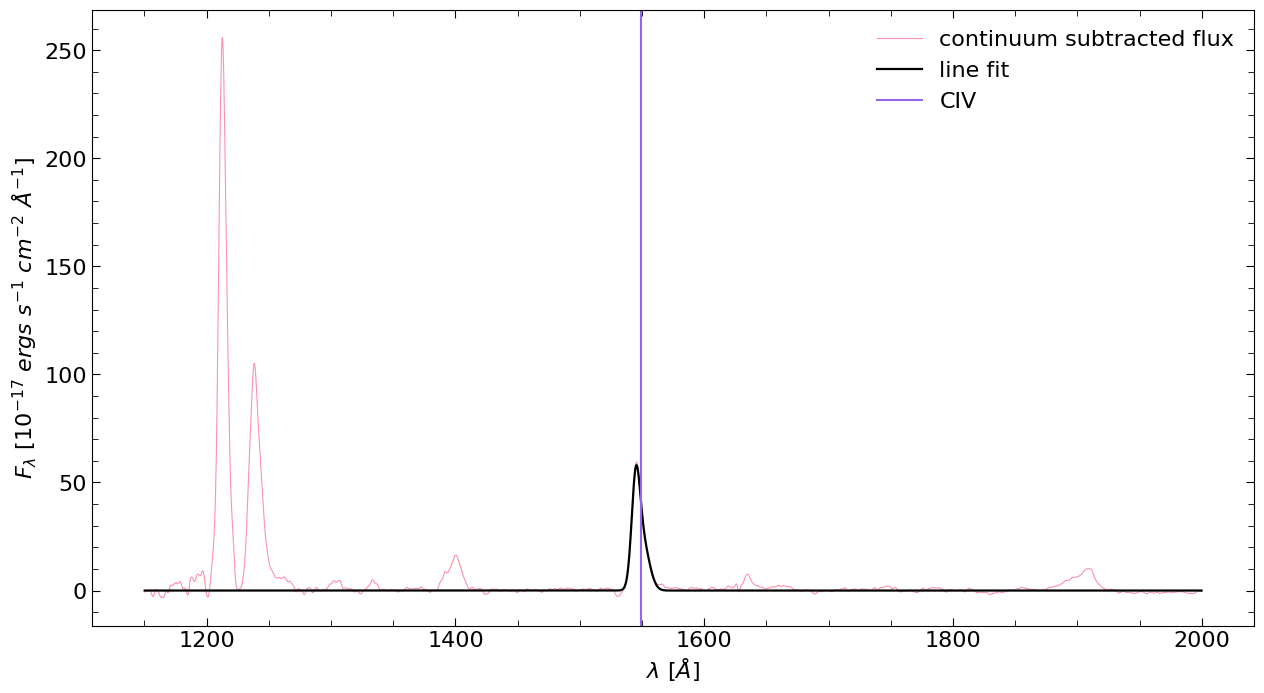


                SDSS: 152941.01+464517.6
                FWHM: 1937.966 vs 1896.472 (Hamann)
                REW: 186.058 vs 158.864 (Hamann)
                kt80: 0.303 vs 0.348 (Hamann)
    
---------------------------------------
---------------------------------------


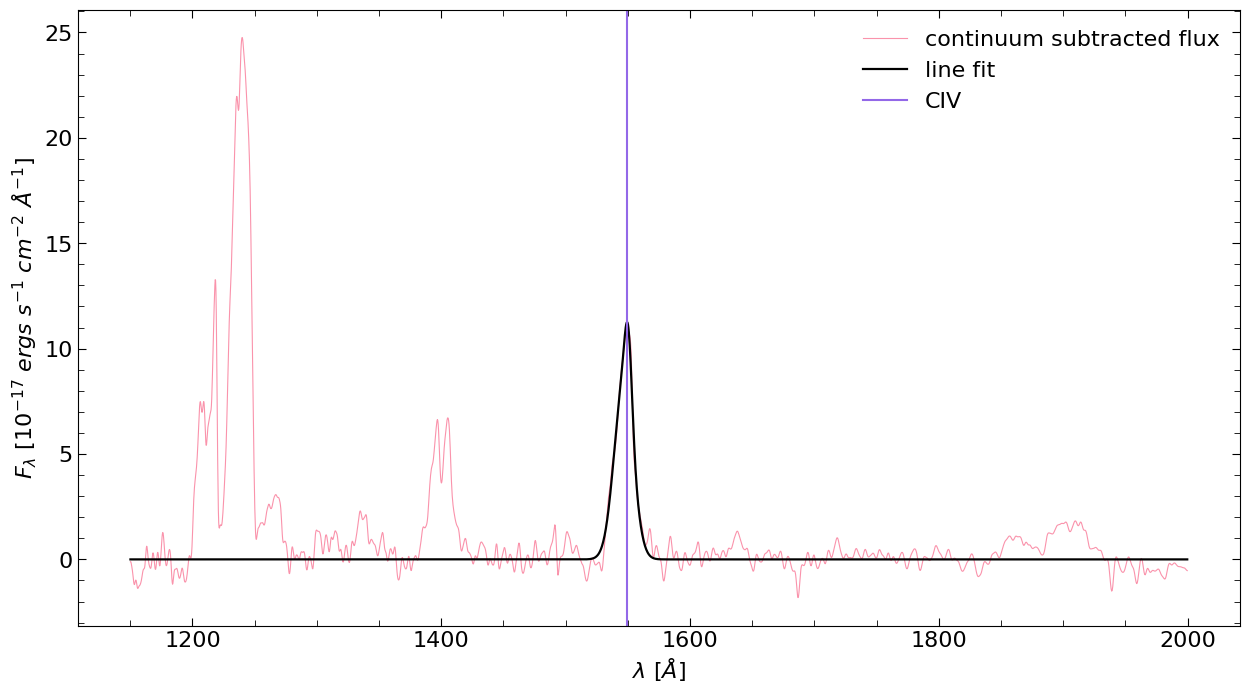


                SDSS: 154831.92+311951.4
                FWHM: 2927.09 vs 3050.048 (Hamann)
                REW: 158.25 vs 127.184 (Hamann)
                kt80: 0.293 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


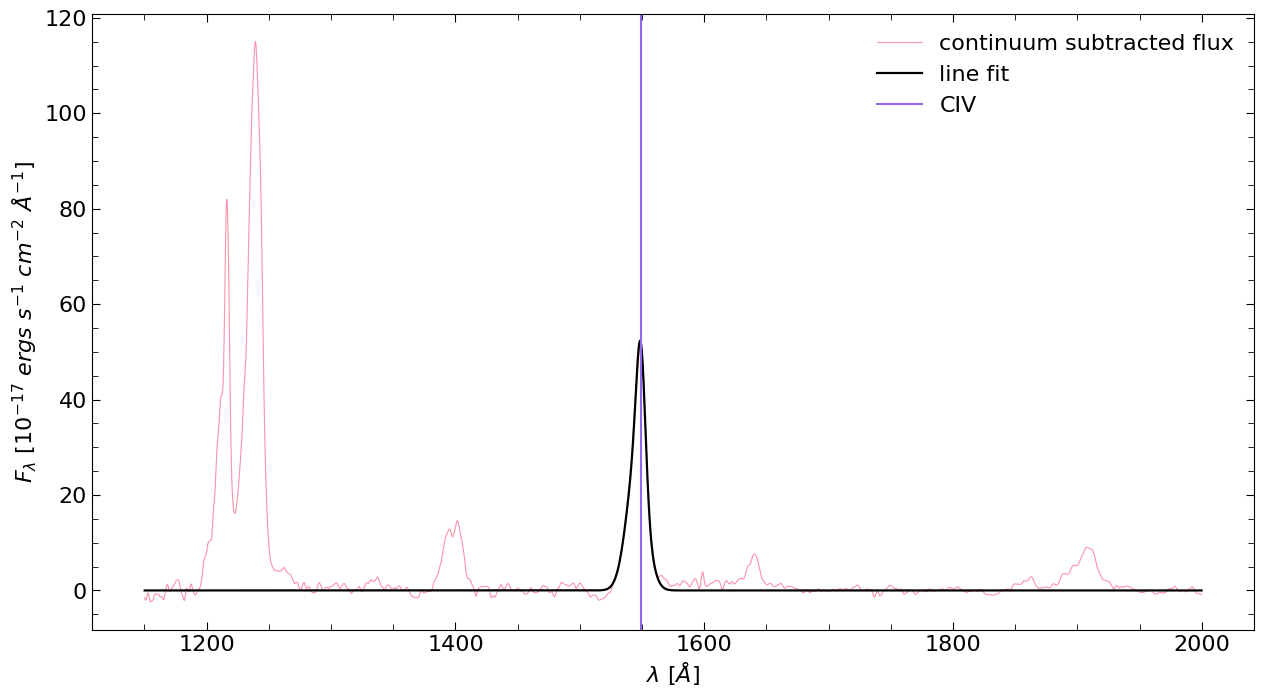


                SDSS: 165202.64+172852.3
                FWHM: 2424.636 vs 2403.322 (Hamann)
                REW: 158.648 vs 124.521 (Hamann)
                kt80: 0.284 vs 0.329 (Hamann)
    
---------------------------------------
---------------------------------------


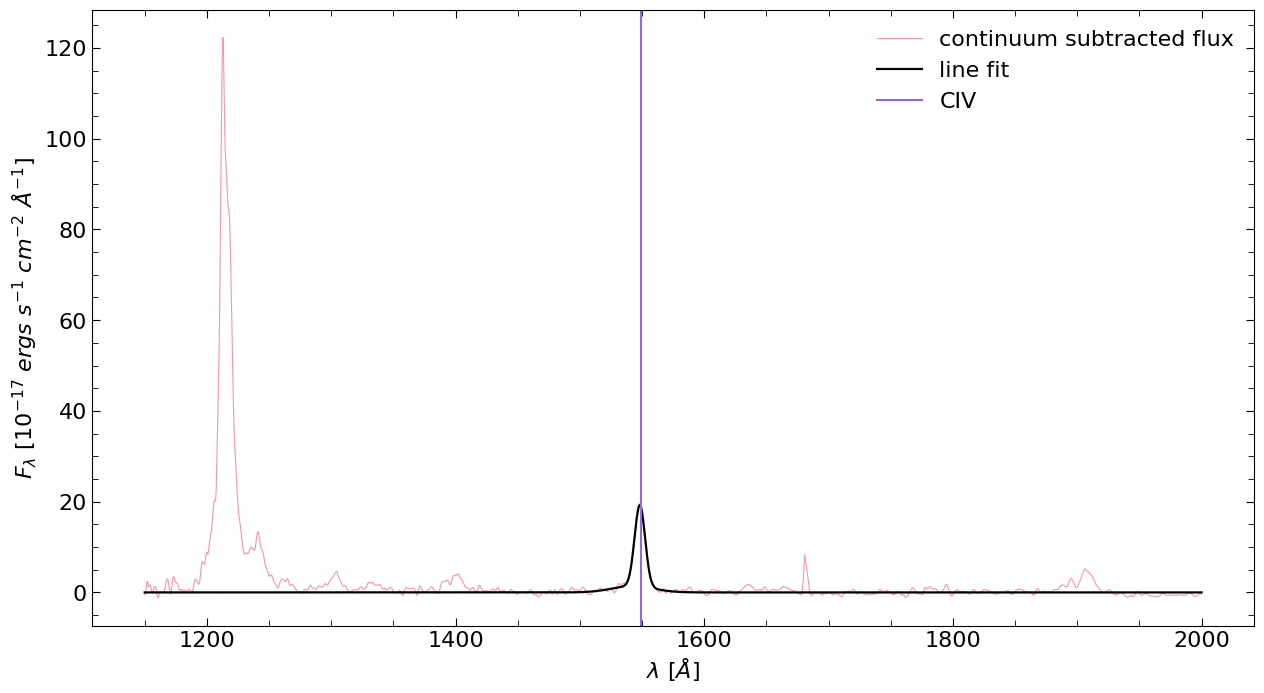


                SDSS: 093226.93+461442.8
                FWHM: 2012.582 vs 1960.054 (Hamann)
                REW: 351.092 vs 443.04 (Hamann)
                kt80: 0.355 vs 0.347 (Hamann)
    
---------------------------------------
---------------------------------------


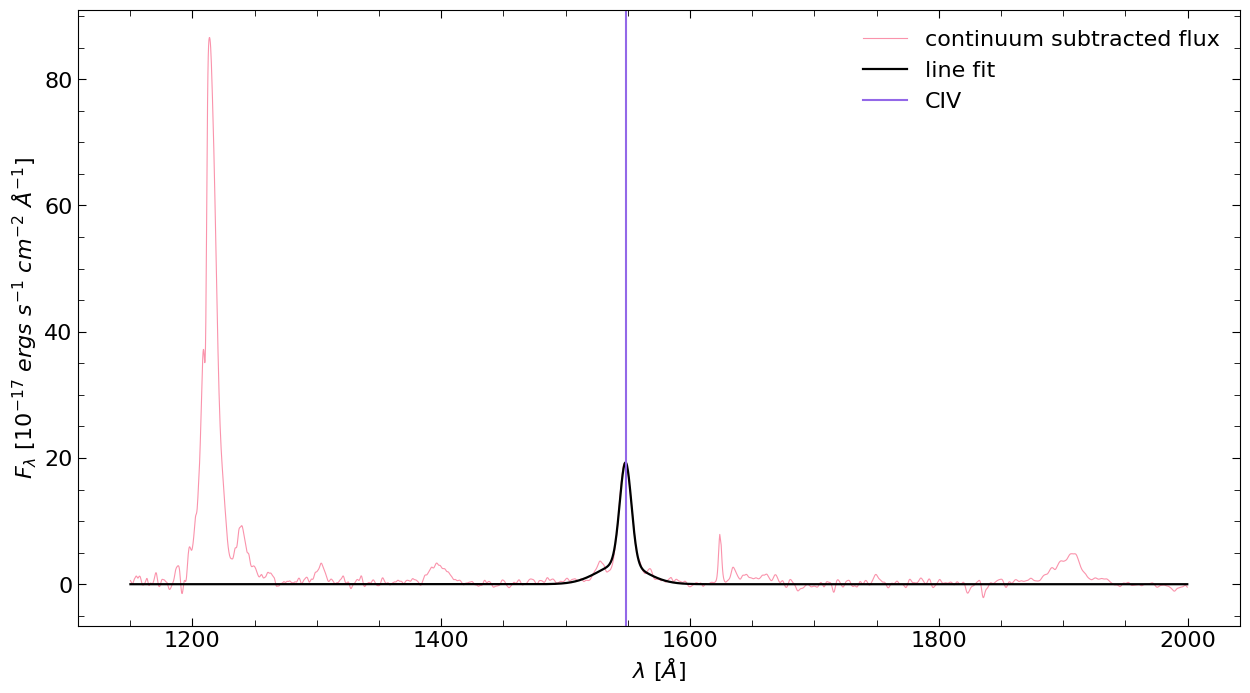


                SDSS: 000746.19+122223.9
                FWHM: 2413.319 vs 2432.83 (Hamann)
                REW: 314.905 vs 219.634 (Hamann)
                kt80: 0.319 vs 0.284 (Hamann)
    
---------------------------------------
---------------------------------------


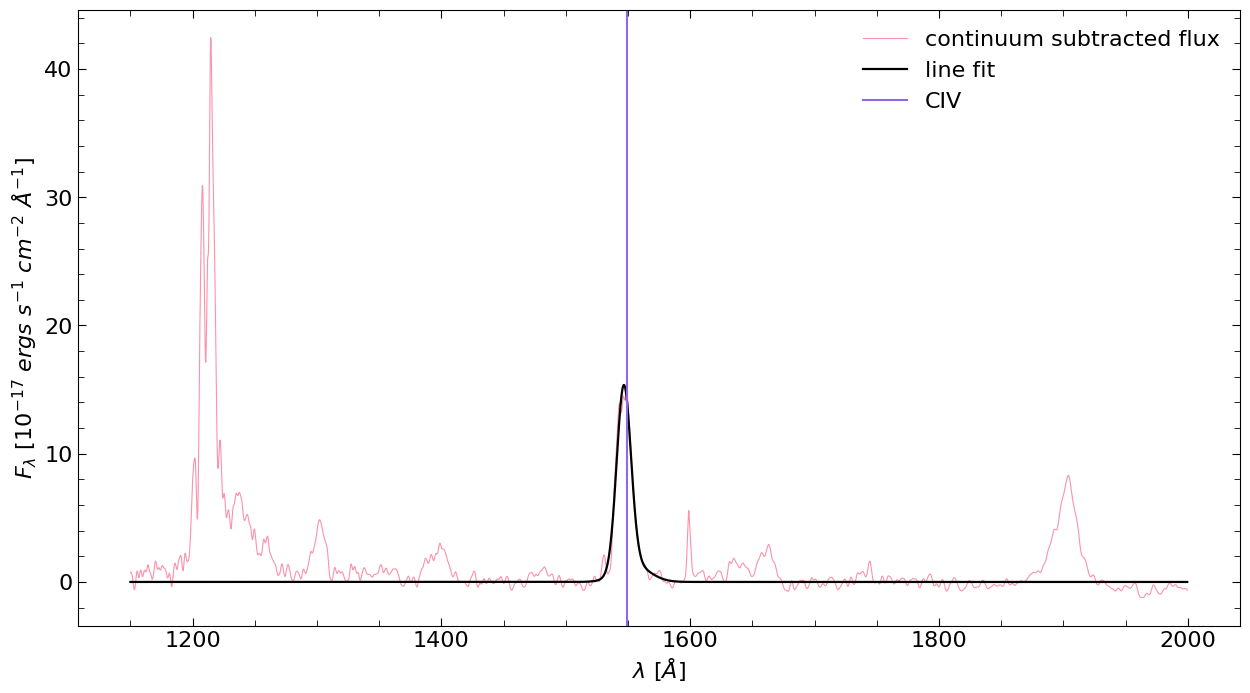


                SDSS: 130654.76+132704.8
                FWHM: 2723.795 vs 2511.169 (Hamann)
                REW: 255.256 vs 196.5 (Hamann)
                kt80: 0.357 vs 0.349 (Hamann)
    
---------------------------------------
---------------------------------------


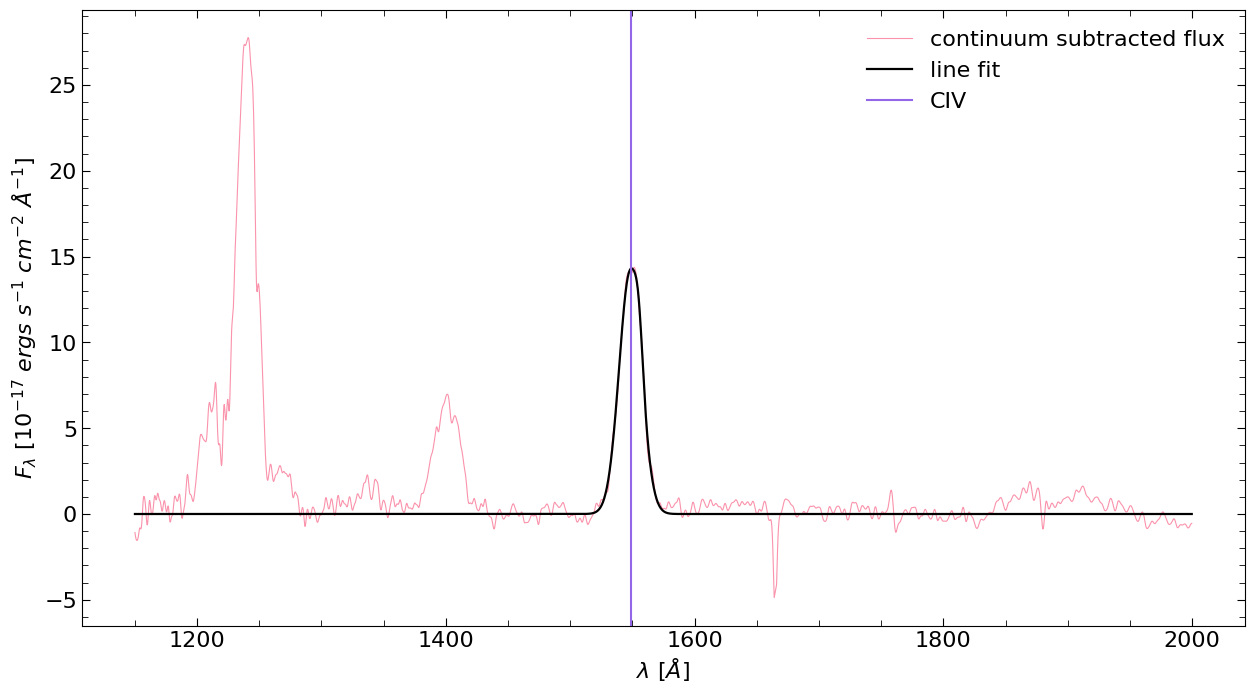


                SDSS: 232326.17-010033.1
                FWHM: 4193.903 vs 3989.27 (Hamann)
                REW: 337.0 vs 255.993 (Hamann)
                kt80: 0.427 vs 0.371 (Hamann)
    
---------------------------------------
---------------------------------------


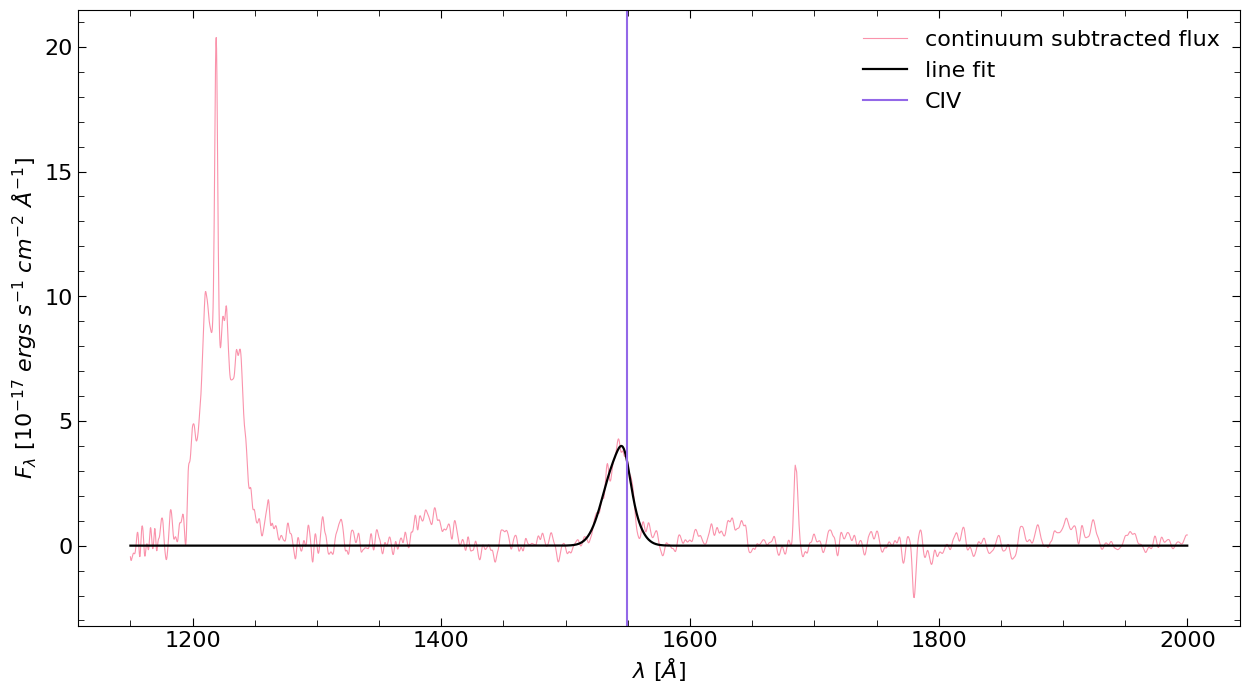


                SDSS: 000610.67+121501.2
                FWHM: 4693.181 vs 4540.061 (Hamann)
                REW: 200.221 vs 106.997 (Hamann)
                kt80: 0.346 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


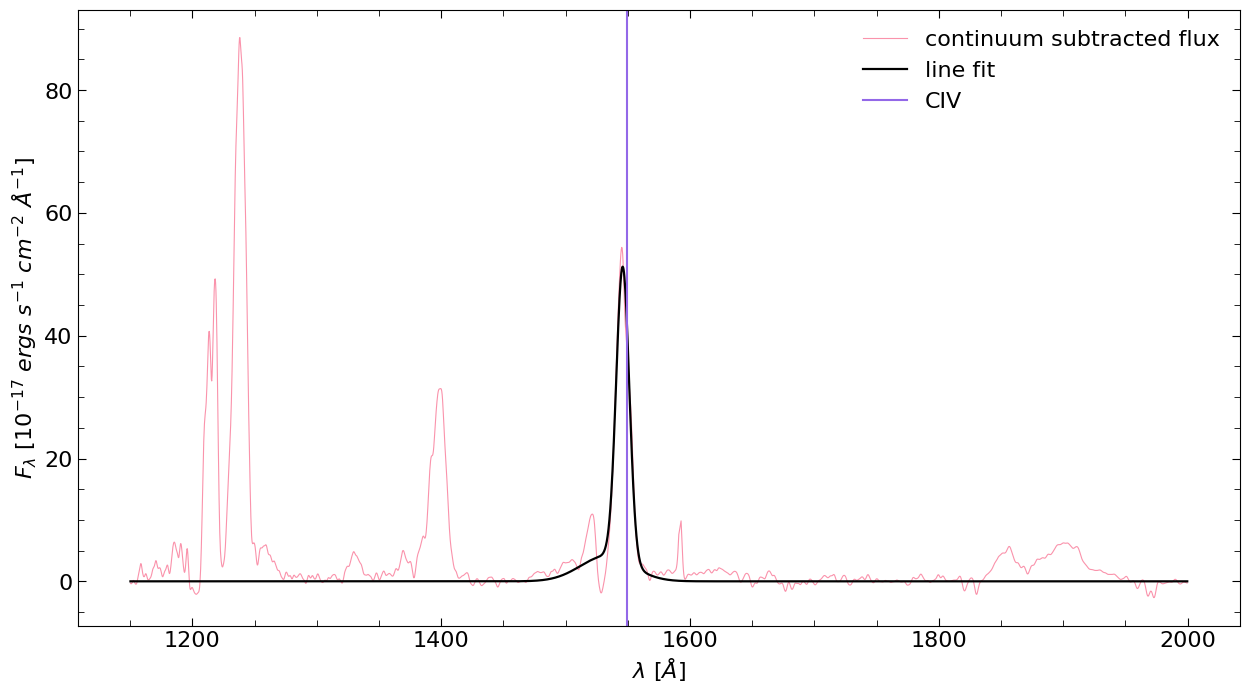


                SDSS: 111017.13+193012.5
                FWHM: 2507.111 vs 2427.165 (Hamann)
                REW: 268.179 vs 219.75 (Hamann)
                kt80: 0.354 vs 0.332 (Hamann)
    
---------------------------------------
---------------------------------------


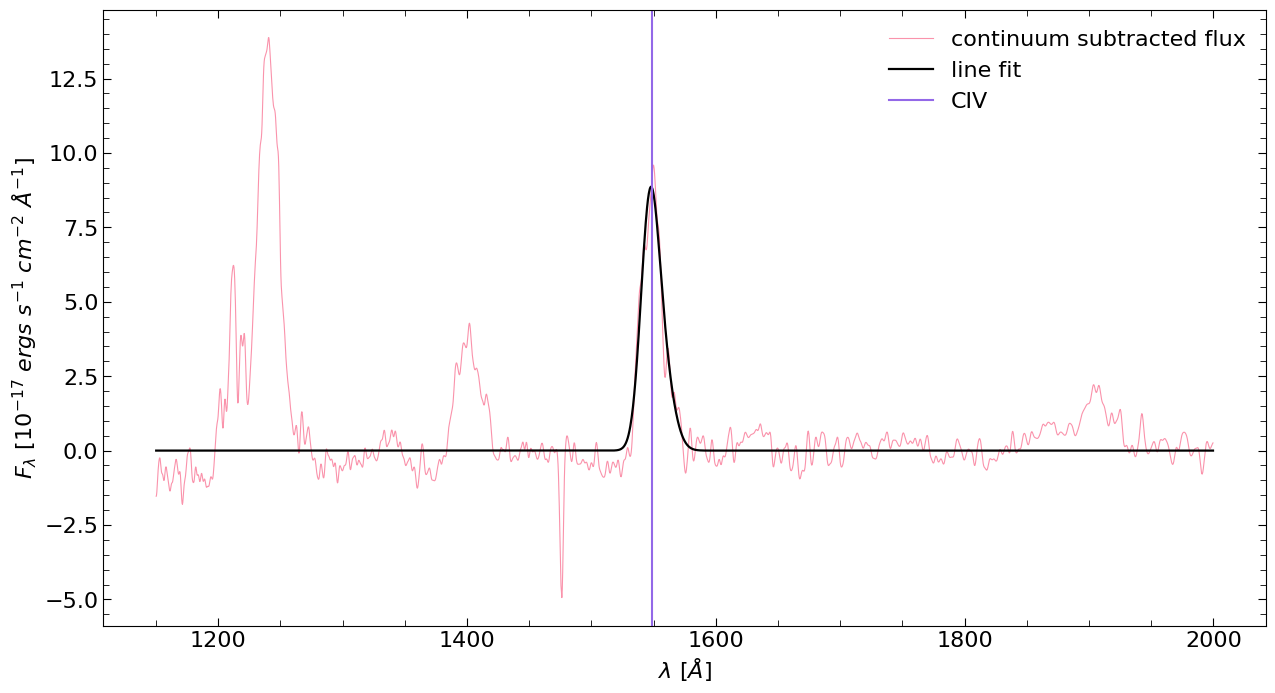


                SDSS: 153107.14+105825.8
                FWHM: 3867.241 vs 3936.554 (Hamann)
                REW: 158.952 vs 151.904 (Hamann)
                kt80: 0.347 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


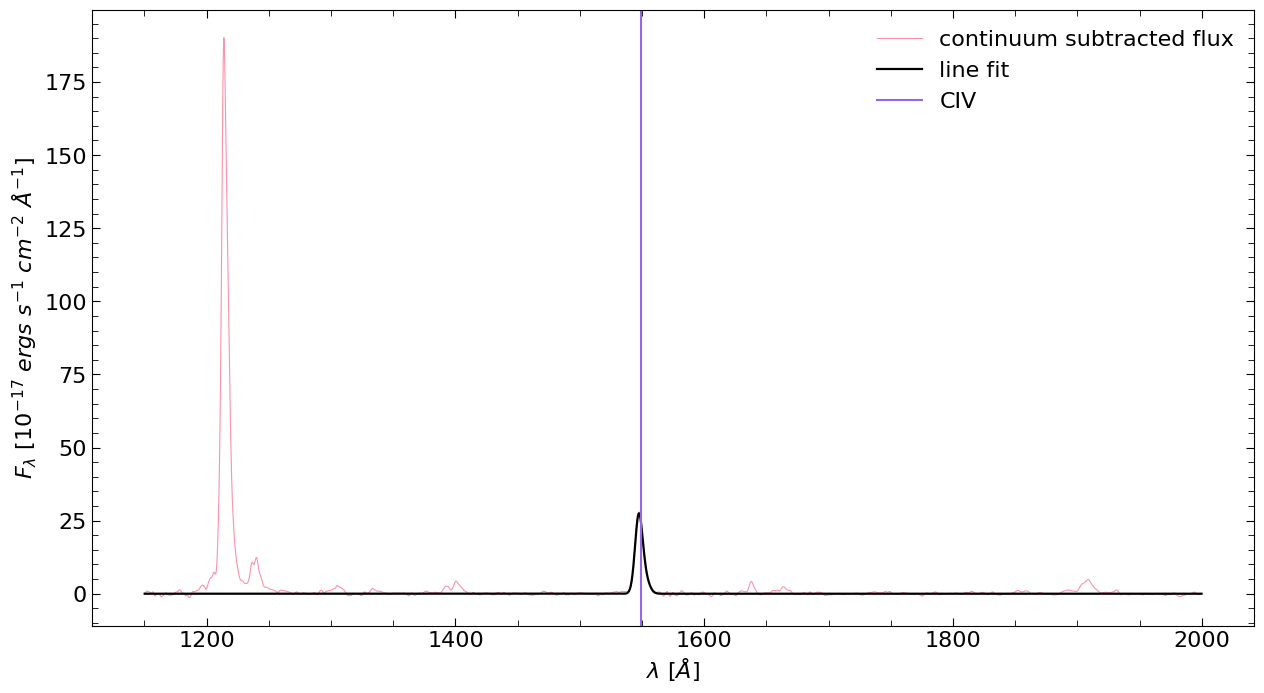


                SDSS: 095033.51+211729.1
                FWHM: 1505.148 vs 1387.112 (Hamann)
                REW: 341.946 vs 272.256 (Hamann)
                kt80: 0.345 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


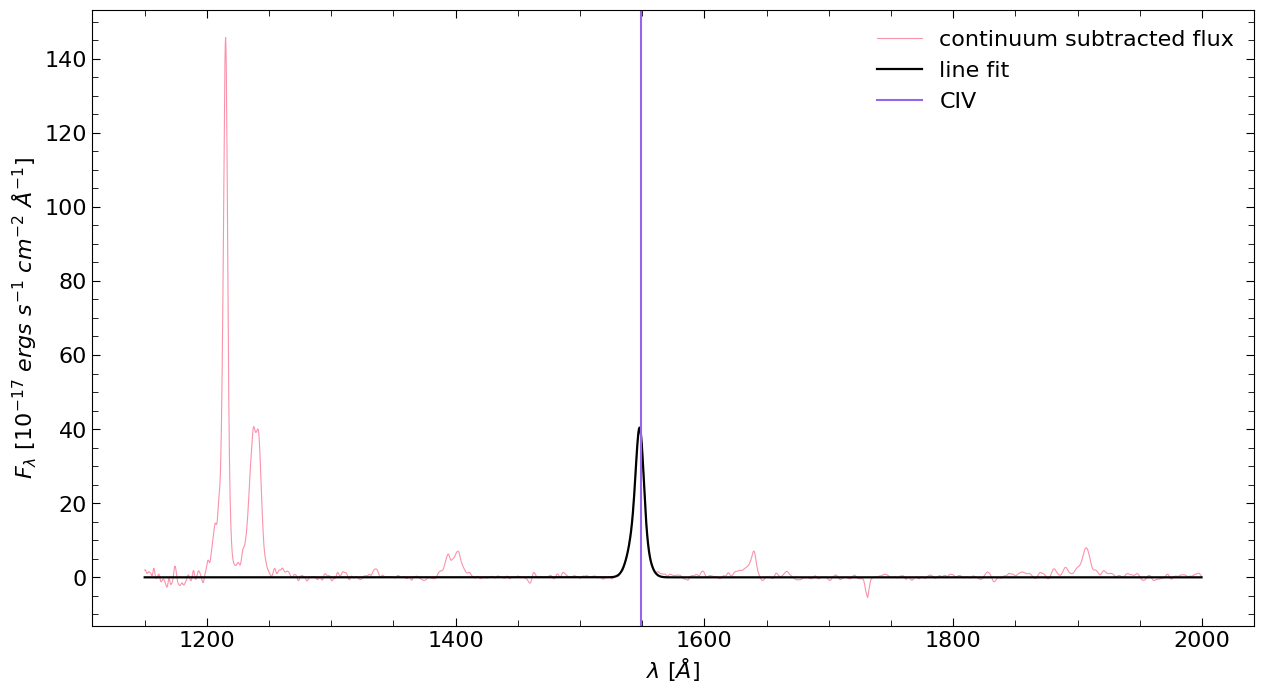


                SDSS: 084447.66+462338.7
                FWHM: 1760.831 vs 1656.003 (Hamann)
                REW: 204.773 vs 160.601 (Hamann)
                kt80: 0.307 vs 0.346 (Hamann)
    
---------------------------------------
---------------------------------------


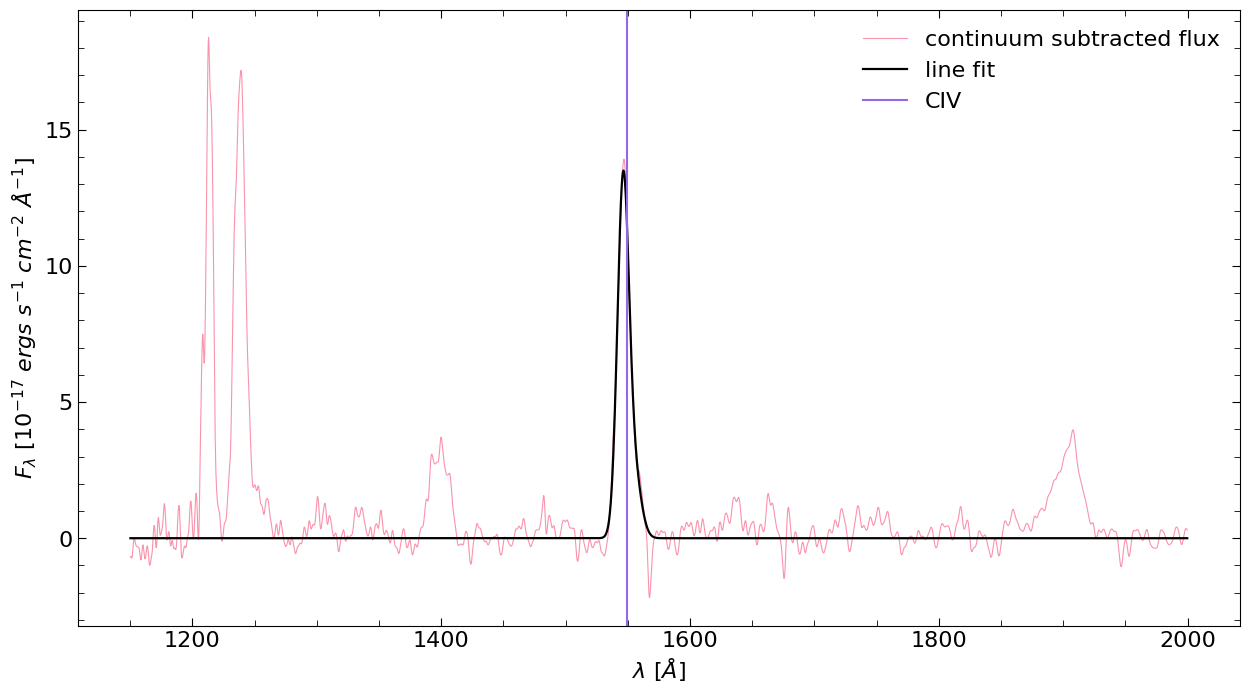


                SDSS: 080425.75+470159.0
                FWHM: 2300.157 vs 2371.301 (Hamann)
                REW: 202.902 vs 161.559 (Hamann)
                kt80: 0.337 vs 0.347 (Hamann)
    
---------------------------------------
---------------------------------------


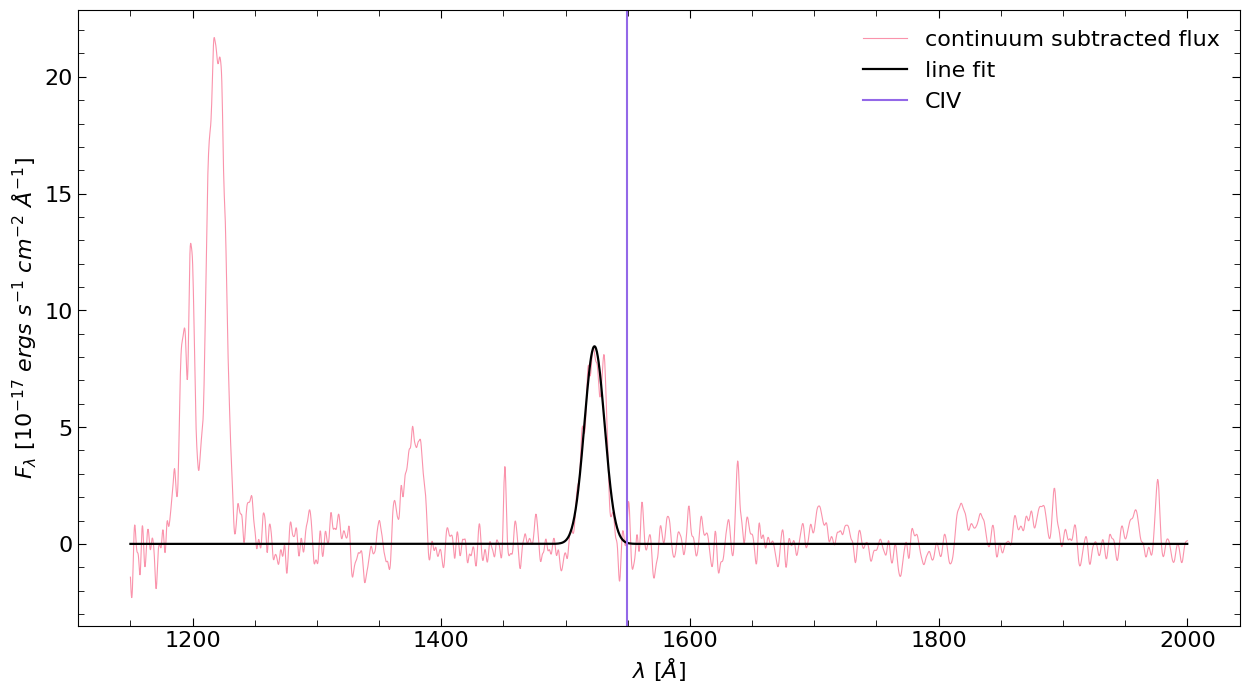


                SDSS: 015222.58+323152.7
                FWHM: 3699.279 vs 3677.216 (Hamann)
                REW: 169.913 vs 135.549 (Hamann)
                kt80: 0.372 vs 0.368 (Hamann)
    
---------------------------------------
---------------------------------------


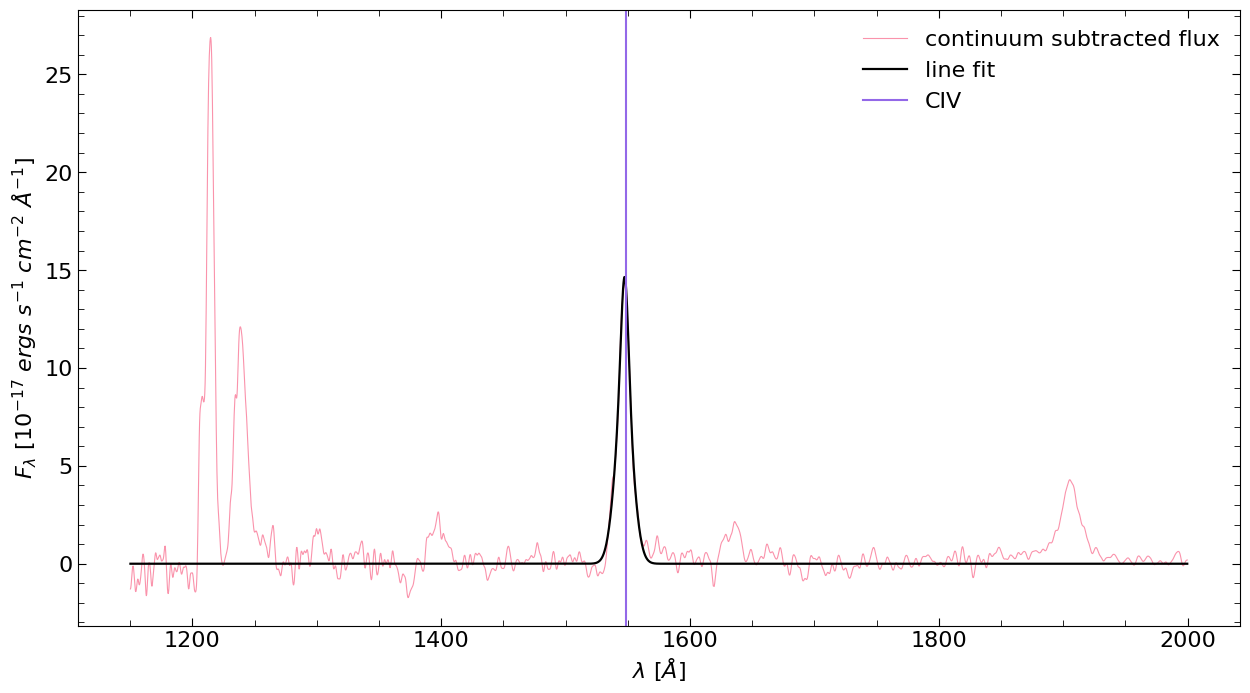


                SDSS: 141350.76+214307.7
                FWHM: 2152.922 vs 2356.276 (Hamann)
                REW: 232.128 vs 207.617 (Hamann)
                kt80: 0.282 vs 0.358 (Hamann)
    
---------------------------------------
---------------------------------------


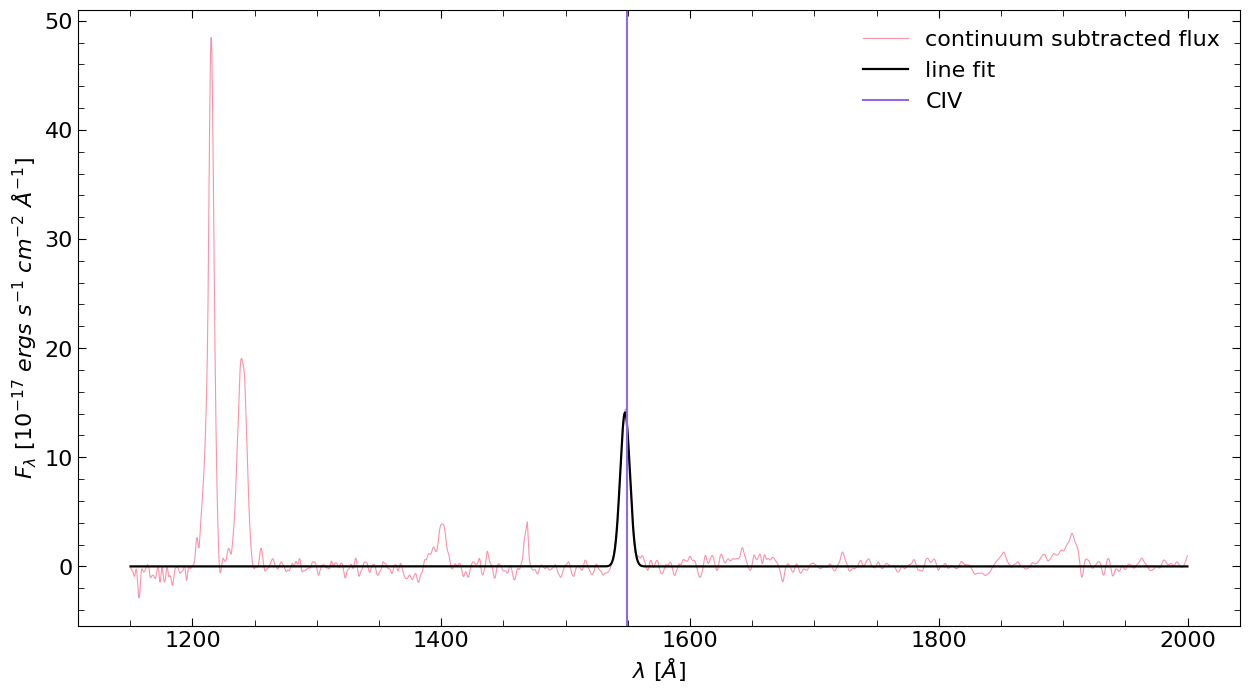


                SDSS: 111516.33+194950.4
                FWHM: 1784.784 vs 1739.004 (Hamann)
                REW: 215.023 vs 246.593 (Hamann)
                kt80: 0.372 vs 0.363 (Hamann)
    
---------------------------------------
---------------------------------------


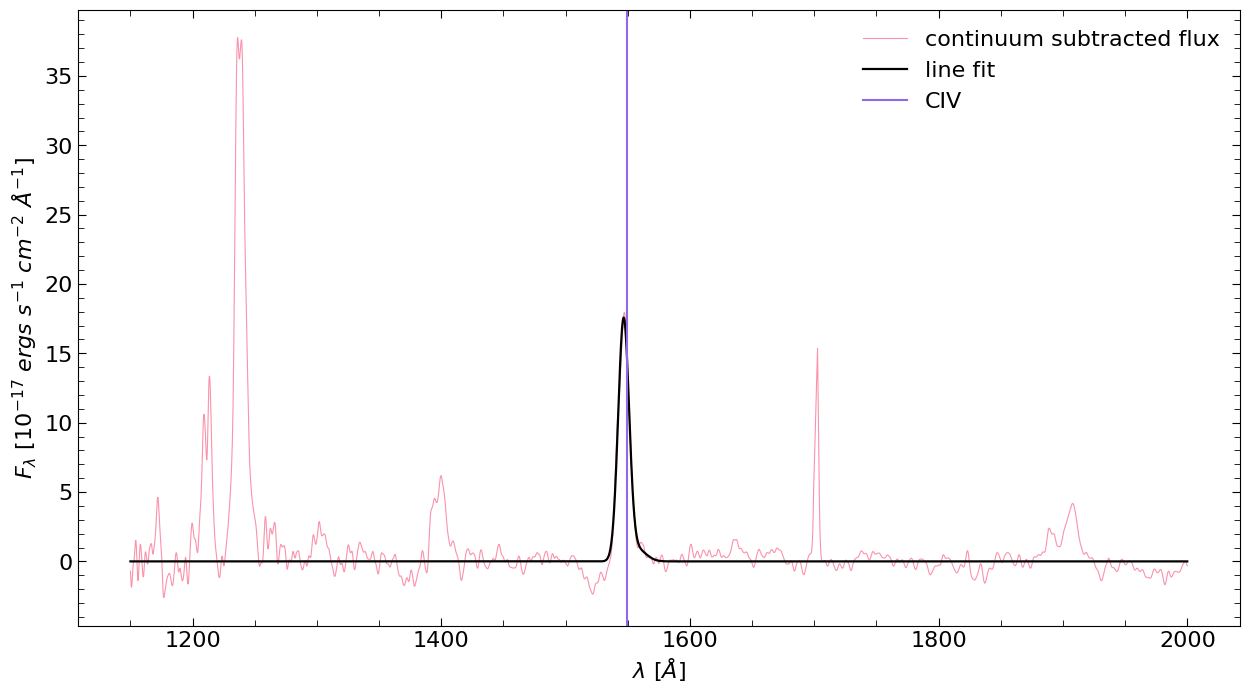


                SDSS: 135608.32+073017.2
                FWHM: 2023.438 vs 2043.349 (Hamann)
                REW: 102.33 vs 109.67 (Hamann)
                kt80: 0.364 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


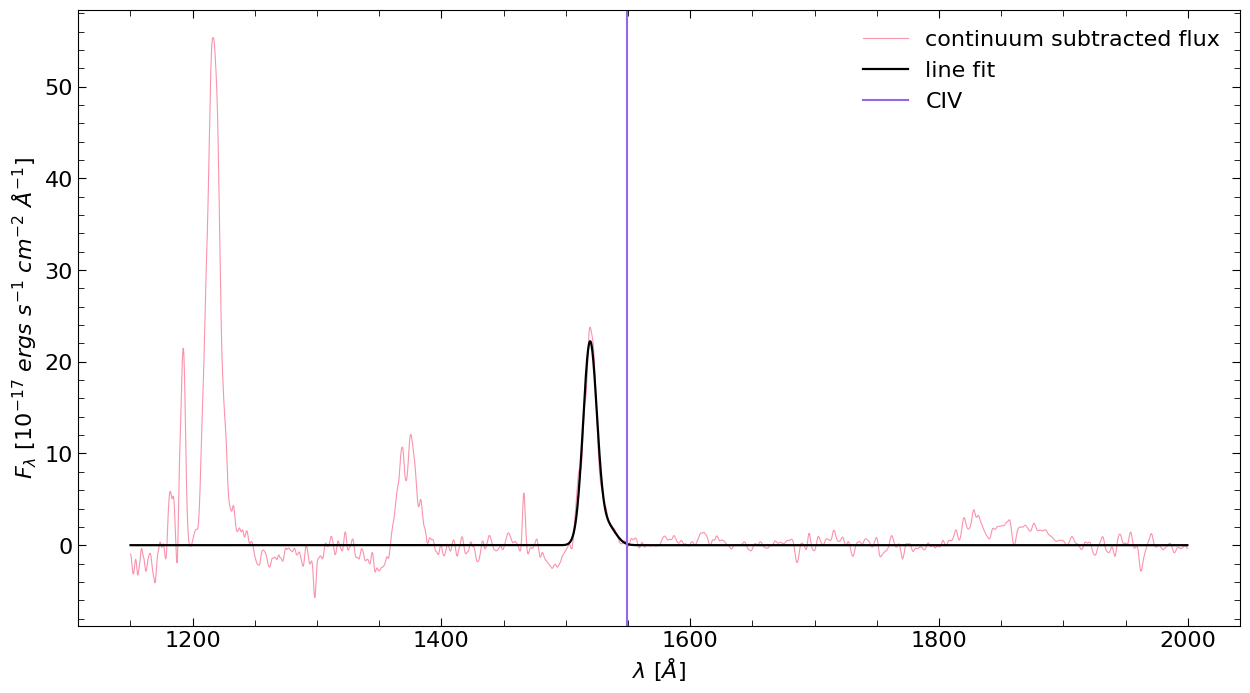


                SDSS: 140506.80+543227.3
                FWHM: 2613.895 vs 2639.806 (Hamann)
                REW: 112.645 vs 122.571 (Hamann)
                kt80: 0.353 vs 0.357 (Hamann)
    
---------------------------------------
---------------------------------------


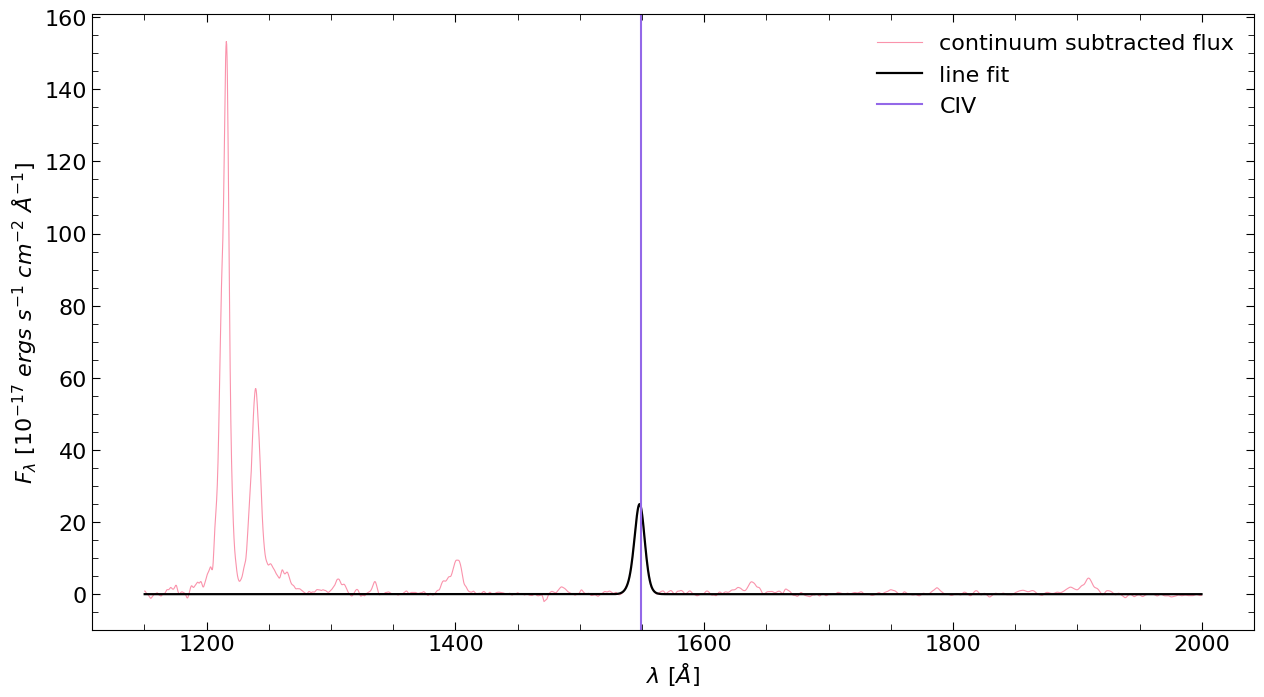


                SDSS: 130114.46+131207.4
                FWHM: 1908.085 vs 1876.523 (Hamann)
                REW: 233.163 vs 185.61 (Hamann)
                kt80: 0.354 vs 0.36 (Hamann)
    
---------------------------------------
---------------------------------------


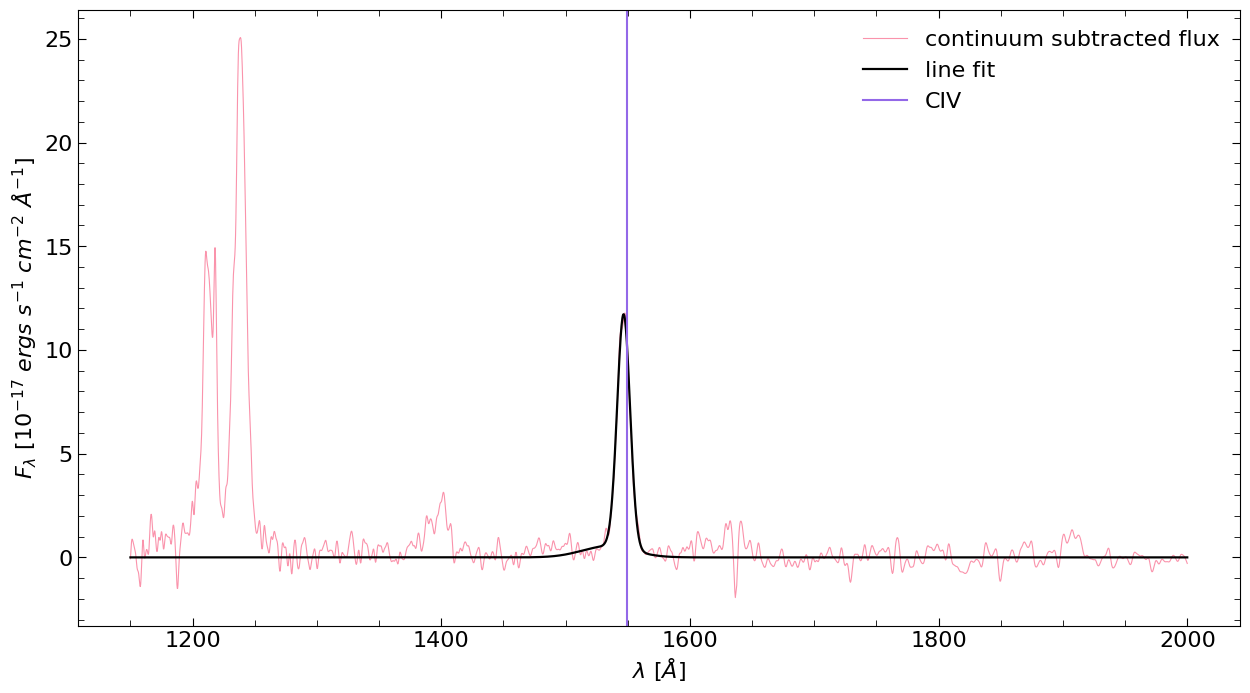


                SDSS: 131722.85+322207.5
                FWHM: 2427.248 vs 2310.771 (Hamann)
                REW: 252.792 vs 159.85 (Hamann)
                kt80: 0.363 vs 0.36 (Hamann)
    
---------------------------------------
---------------------------------------


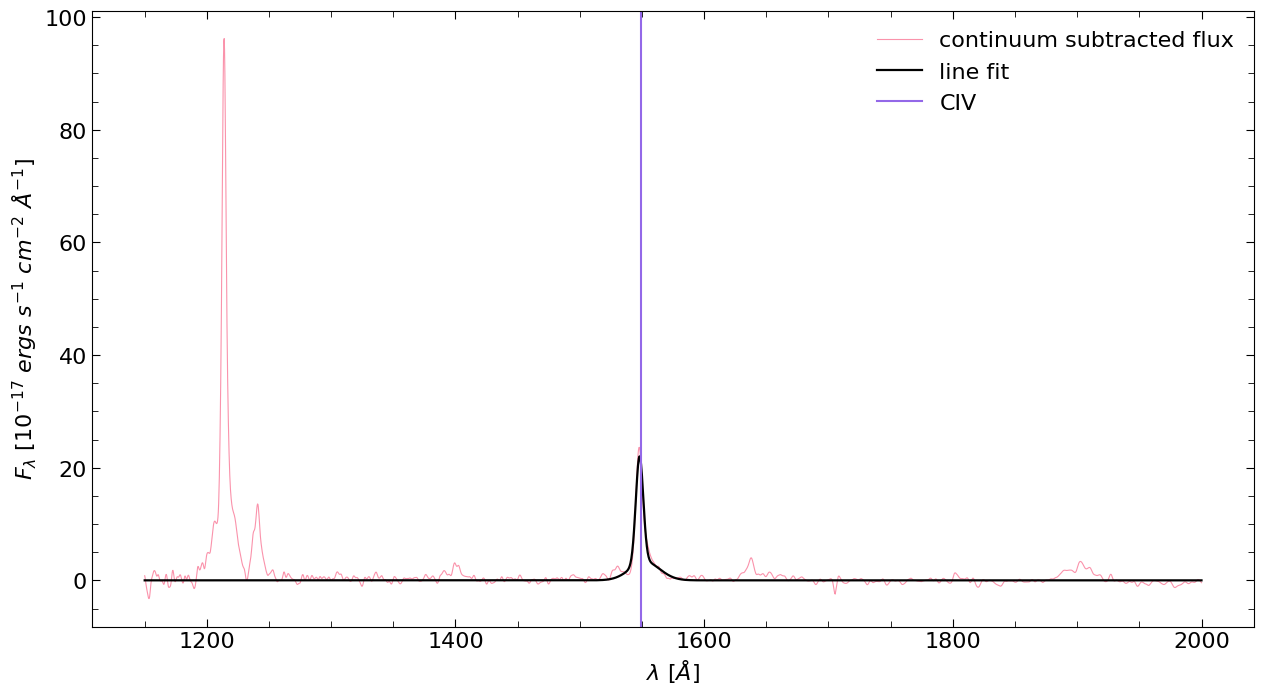


                SDSS: 153446.26+515933.8
                FWHM: 1519.164 vs 1156.431 (Hamann)
                REW: 156.806 vs 126.687 (Hamann)
                kt80: 0.326 vs 0.283 (Hamann)
    
---------------------------------------
---------------------------------------


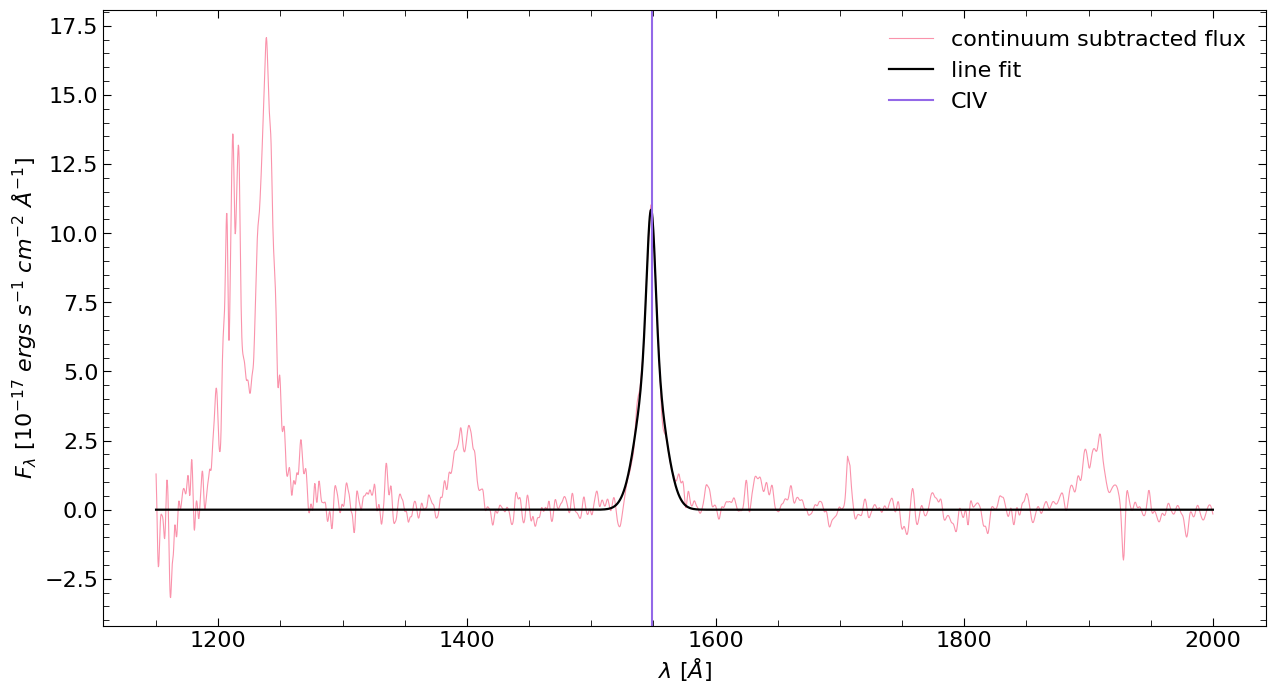


                SDSS: 090306.18+234909.8
                FWHM: 2538.396 vs 2480.755 (Hamann)
                REW: 155.305 vs 143.591 (Hamann)
                kt80: 0.23 vs 0.209 (Hamann)
    
---------------------------------------
---------------------------------------


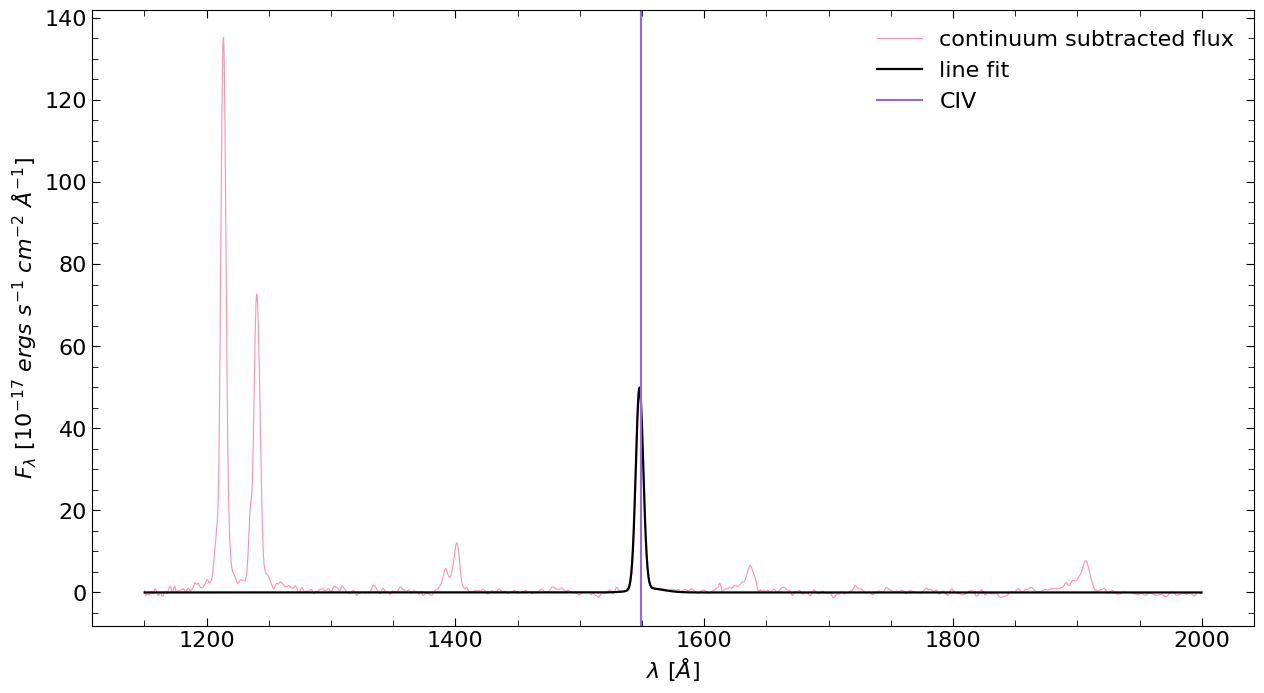


                SDSS: 093638.41+101930.3
                FWHM: 1382.935 vs 1271.195 (Hamann)
                REW: 286.449 vs 171.815 (Hamann)
                kt80: 0.367 vs 0.37 (Hamann)
    
---------------------------------------
---------------------------------------


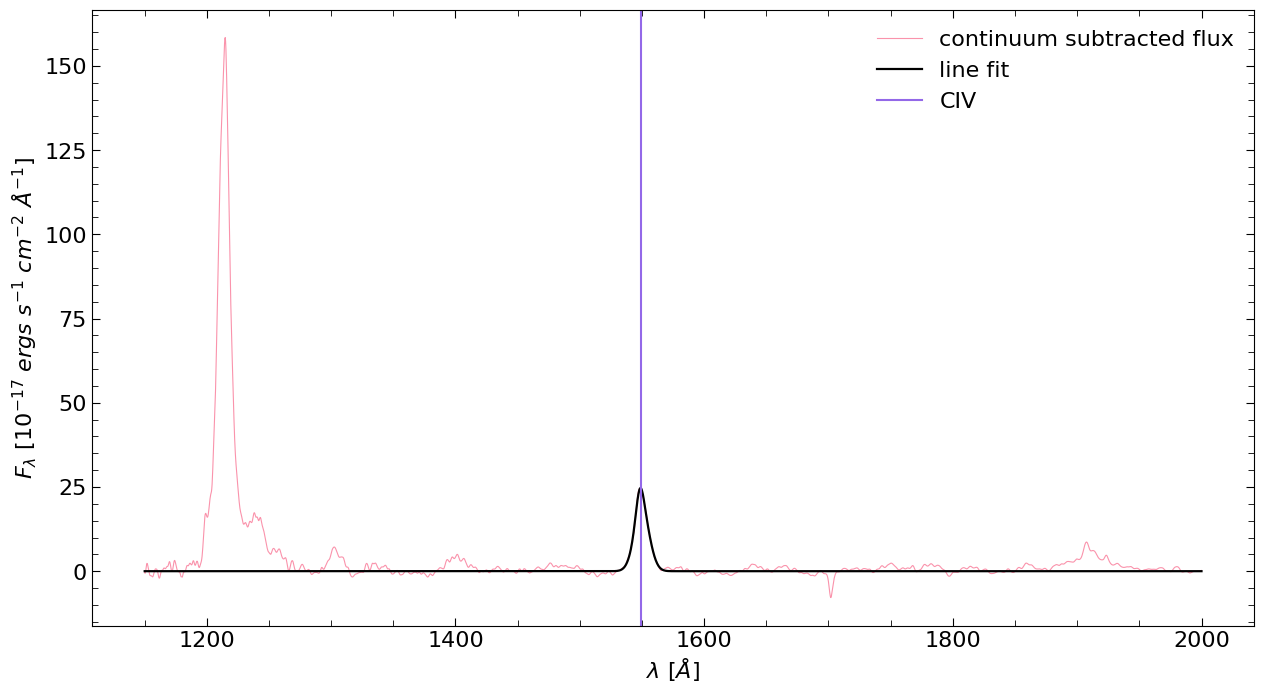


                SDSS: 104718.35+484433.8
                FWHM: 2280.33 vs 2521.46 (Hamann)
                REW: 160.487 vs 158.03 (Hamann)
                kt80: 0.317 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


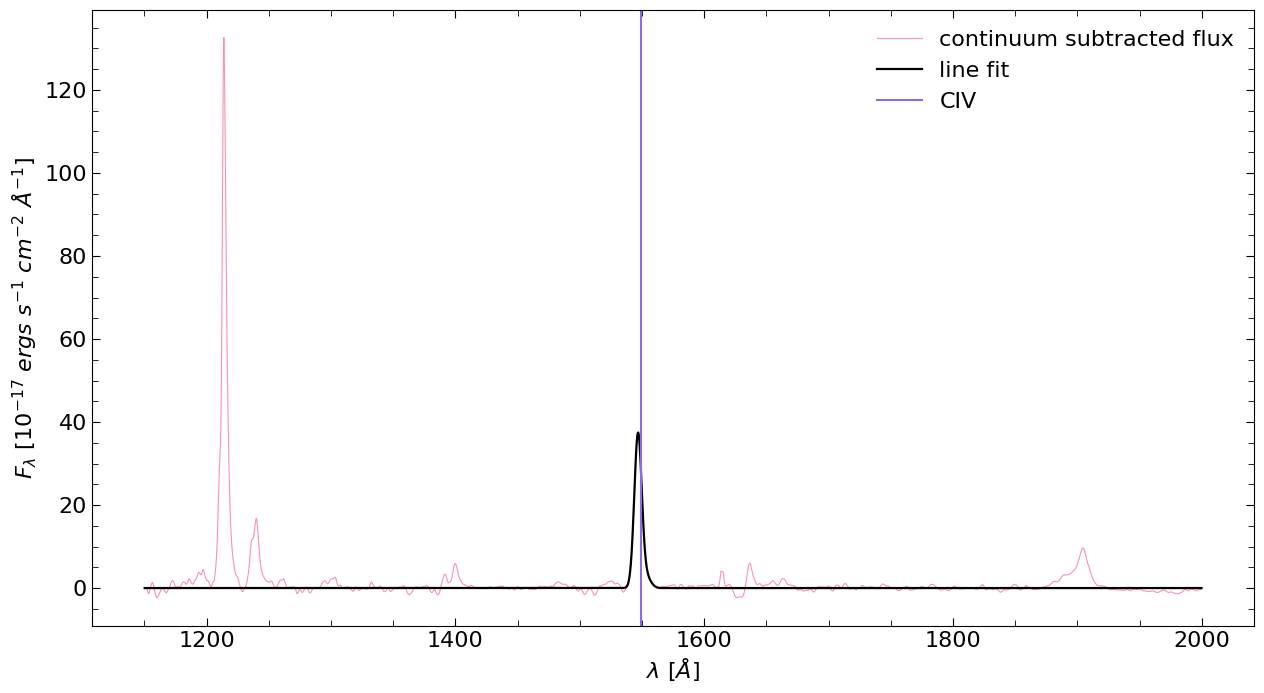


                SDSS: 170558.64+273624.7
                FWHM: 1404.882 vs 1300.839 (Hamann)
                REW: 184.269 vs 157.472 (Hamann)
                kt80: 0.359 vs 0.359 (Hamann)
    
---------------------------------------
---------------------------------------
SDSS: 134535.66+600028.4
Rejected because: Continuum too steep (alpha=-3.25)


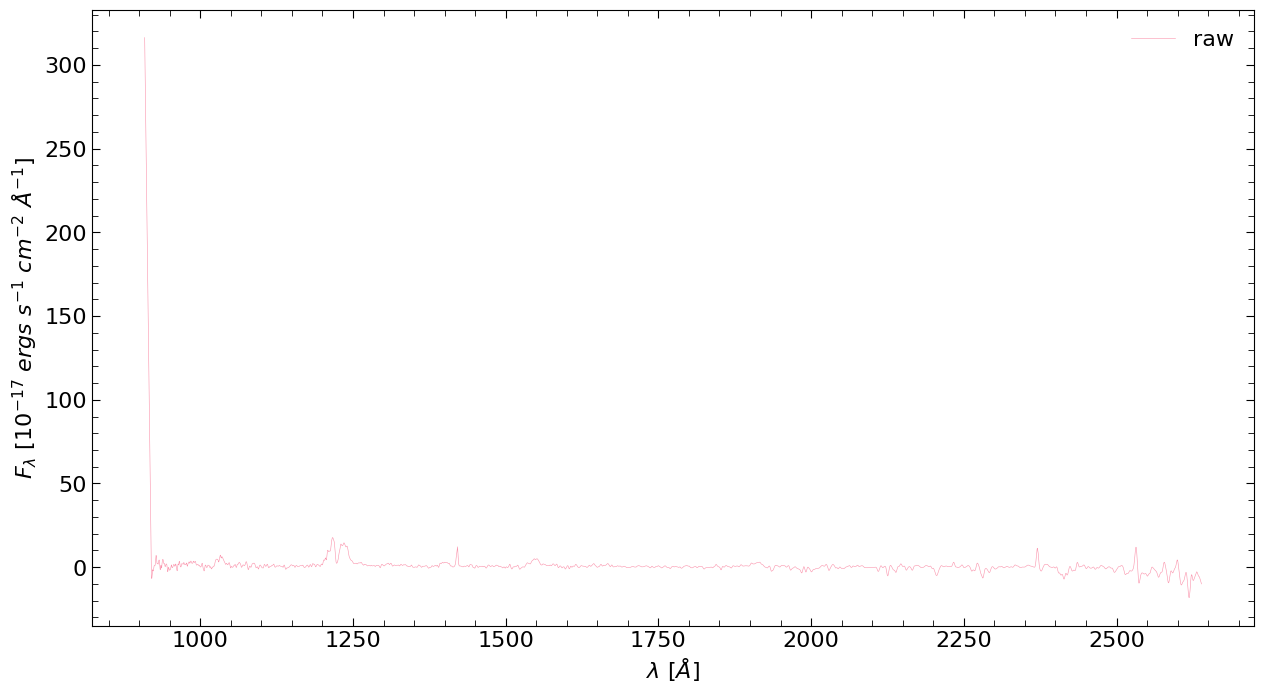

---------------------------------------
---------------------------------------


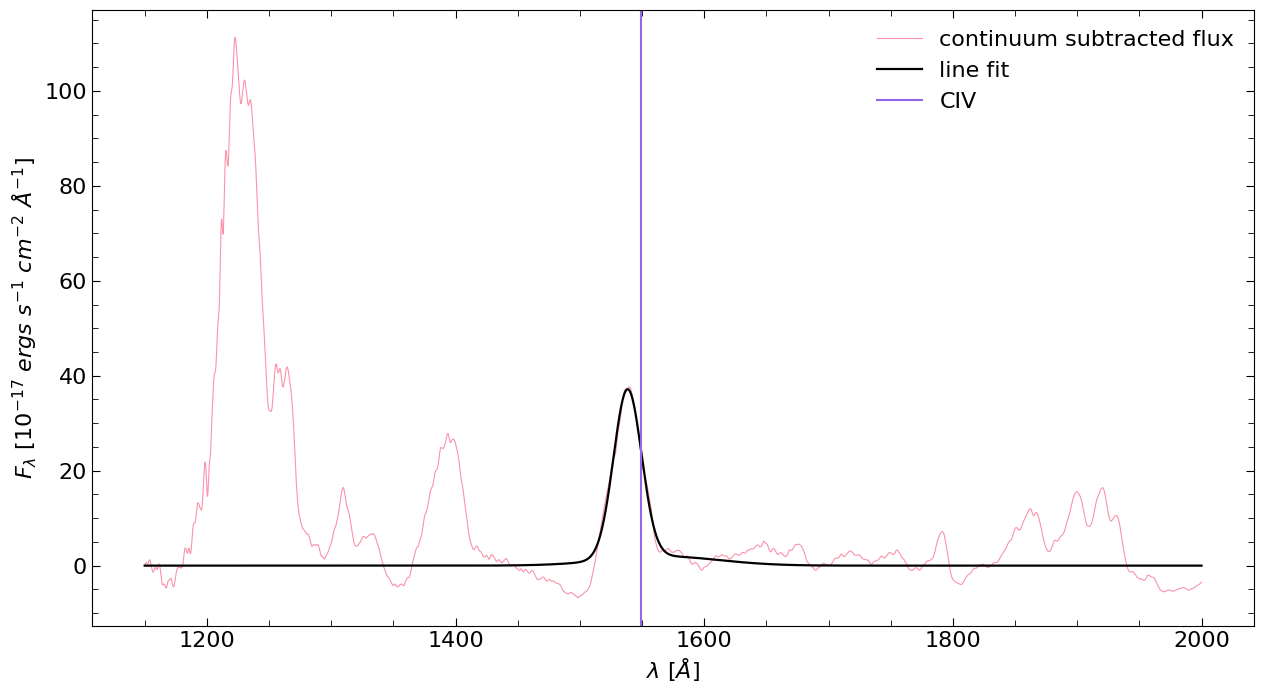


                SDSS: 102541.78+245424.2
                FWHM: 5297.775 vs 5324.386 (Hamann)
                REW: 105.066 vs 114.538 (Hamann)
                kt80: 0.361 vs 0.365 (Hamann)
    
---------------------------------------
---------------------------------------


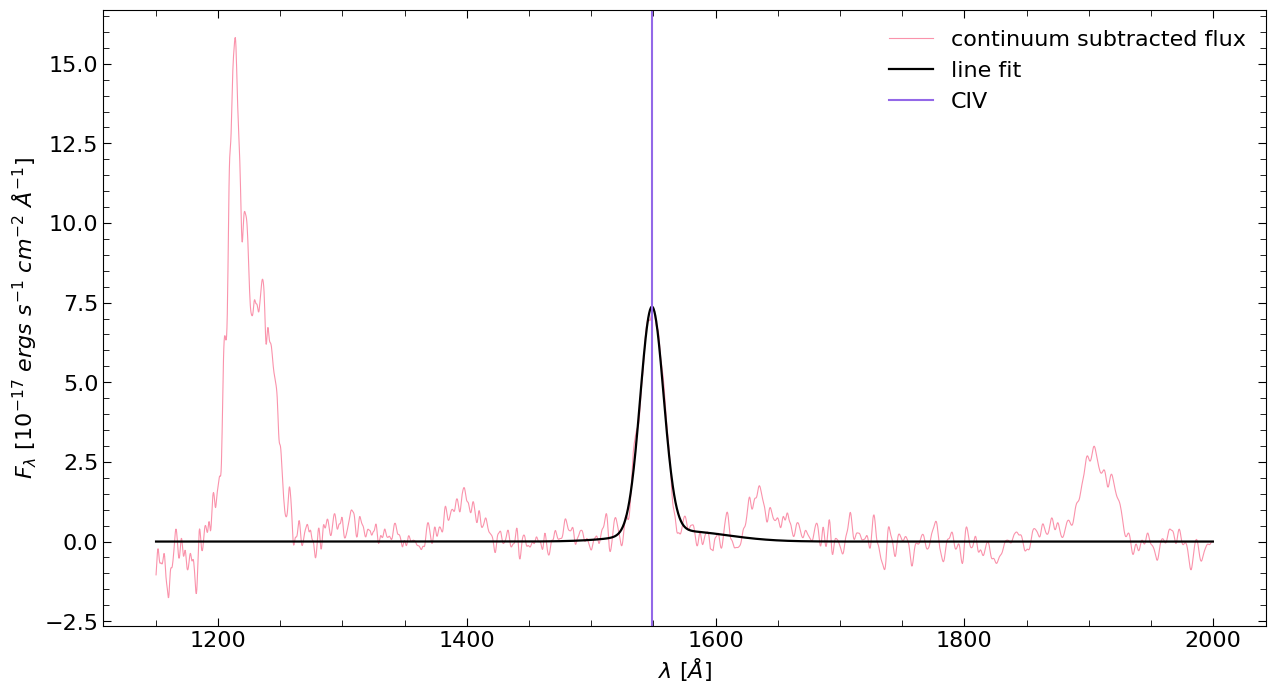


                SDSS: 221524.00-005643.8
                FWHM: 4374.418 vs 4280.102 (Hamann)
                REW: 239.388 vs 153.336 (Hamann)
                kt80: 0.363 vs 0.366 (Hamann)
    
---------------------------------------
---------------------------------------


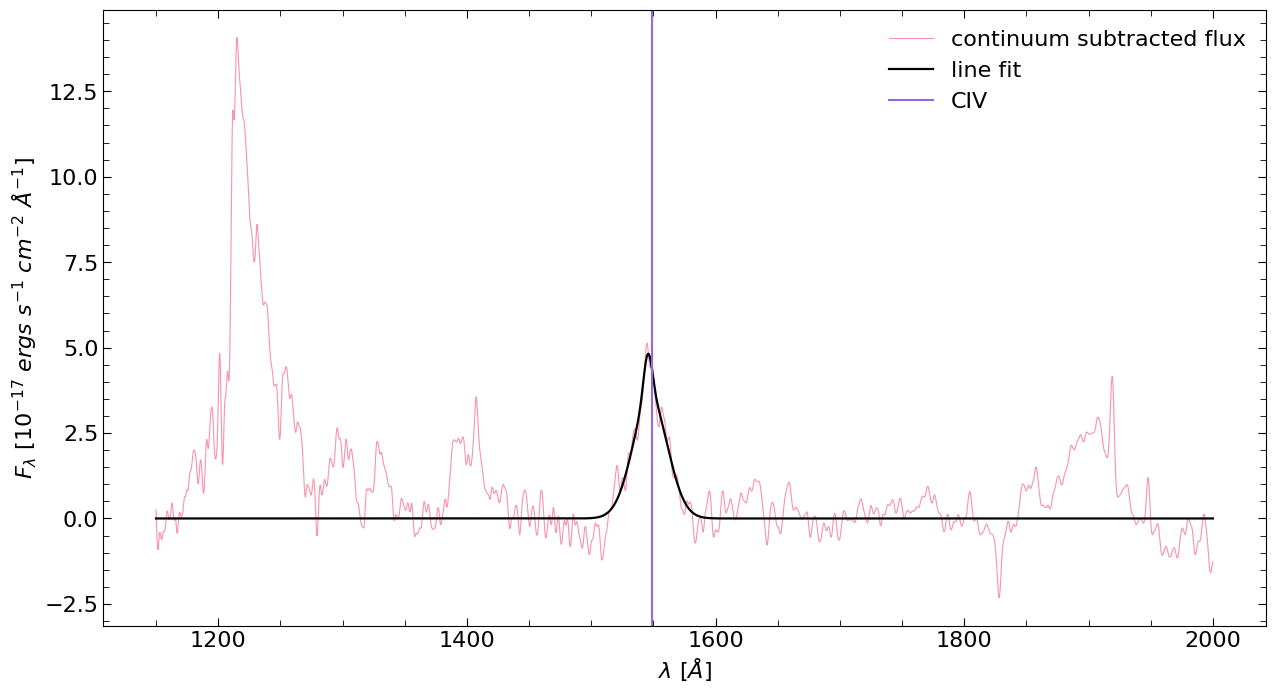


                SDSS: 103456.95+143012.5
                FWHM: 4733.437 vs 5949.083 (Hamann)
                REW: 93.829 vs 102.341 (Hamann)
                kt80: 0.211 vs 0.372 (Hamann)
    


In [12]:
for i in range(len(spectra_df)):
    print("---------------------------------------\n---------------------------------------")
    sanity_tests(i)